#STAT 467 Multivariate Data Analysis Project

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import f as f_dist
from scipy.stats import t as t_dist
from scipy.stats import jarque_bera, probplot
from statsmodels.stats.diagnostic import het_breuschpagan
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                             roc_curve, auc, precision_recall_curve)
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import cdist
import statsmodels.api as sm
from sklearn.cross_decomposition import CCA

%pip install factor_analyzer
from factor_analyzer import FactorAnalyzer

import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

%matplotlib inline

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 1.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for factor_analyzer: filename=factor_analyzer-0.5.1-py2.py3-none-any.whl size=42655 sha256=028d600d90a4fd3d1c4b42e6722ac8ec531fe414b27777ec1208e309a476ca32
  Stored in directory: /root/.cache/pip/wheels/a2/af/06/f4d4ed4d9d714fda437fb1583629417319603c2266e7b233cc
Successfully built factor_analyzer


##Data Loading and Preparation


Variables with Missing Values:
                      Missing Count  Missing %
condition                     15921      74.05
buildingMaterial               8792      40.89
type                           4397      20.45
floor                          3573      16.62
buildYear                      3380      15.72
hasElevator                     960       4.46
collegeDistance                 584       2.72
floorCount                      209       0.97
clinicDistance                   63       0.29
restaurantDistance               31       0.14
pharmacyDistance                 30       0.14
postOfficeDistance               20       0.09
kindergartenDistance             19       0.09
schoolDistance                   11       0.05


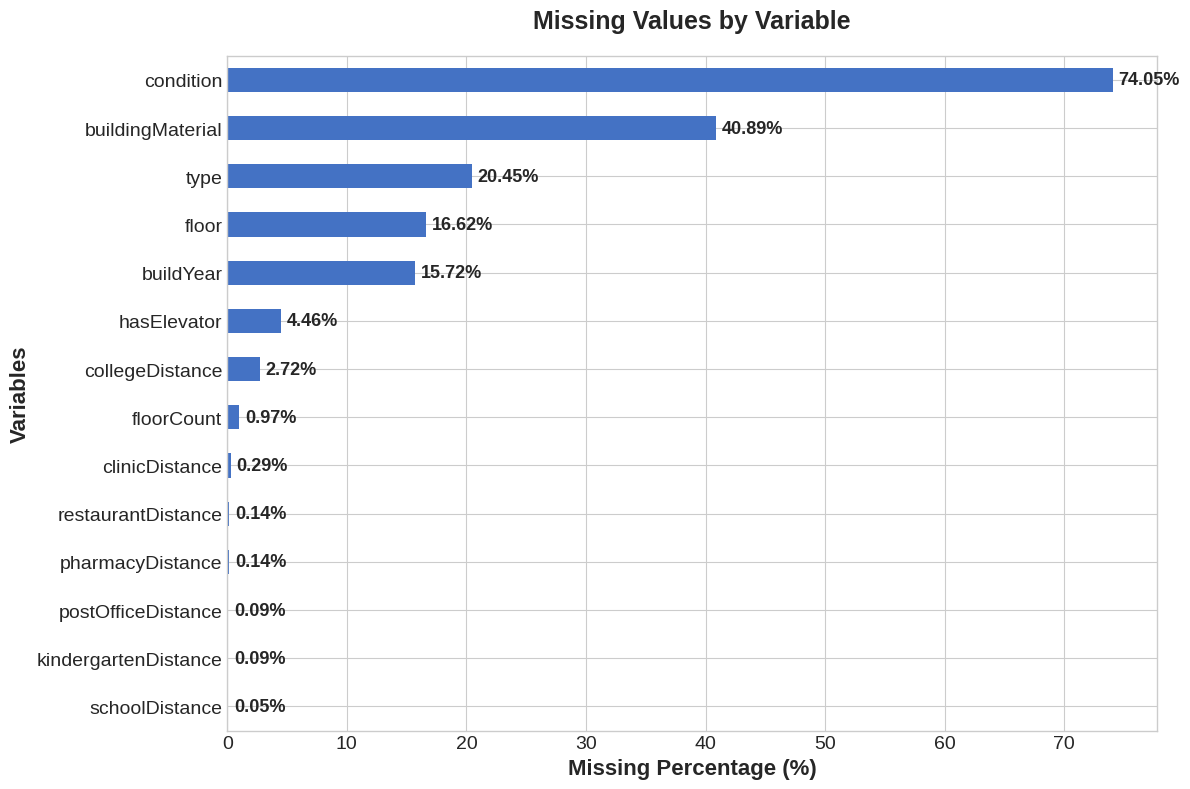


4.1 Handling Missing Values...
  schoolDistance: filled 11 missing with median (0.289)
  clinicDistance: filled 63 missing with median (0.677)
  postOfficeDistance: filled 20 missing with median (0.392)
  kindergartenDistance: filled 19 missing with median (0.256)
  restaurantDistance: filled 31 missing with median (0.224)
  collegeDistance: filled 584 missing with median (1.121)
  pharmacyDistance: filled 30 missing with median (0.235)
  floor: filled 3573 missing with median (3.0)
  floorCount: filled 209 missing with median (4.0)
  buildYear: filled 3380 missing with median (1993.0)
  type: filled 4397 missing with 'unknown'
  buildingMaterial: filled 8792 missing with 'unknown'
  condition: filled 15921 missing with 'unknown'
  hasElevator: filled 960 missing with 'unknown'

Remaining missing values: 0


In [2]:
# Load data
df = pd.read_csv('apartments_pl_2024_06.csv')

# Identify variable types
id_var = ['id']

continuous_vars = ['squareMeters', 'latitude', 'longitude', 'centreDistance',
                   'schoolDistance', 'clinicDistance', 'postOfficeDistance',
                   'kindergartenDistance', 'restaurantDistance', 'collegeDistance',
                   'pharmacyDistance', 'price']

discrete_vars = ['rooms', 'floor', 'floorCount', 'buildYear', 'poiCount']

categorical_vars = ['city', 'type', 'ownership', 'buildingMaterial', 'condition',
                    'hasParkingSpace', 'hasBalcony', 'hasElevator', 'hasSecurity',
                    'hasStorageRoom']

# Missing value analysis
missing_counts = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing %': missing_percent
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print("\nVariables with Missing Values:")
print(missing_df)

# Visualize missing values
fig, ax = plt.subplots(figsize=(12, 8))
missing_df['Missing %'].plot(kind='barh', color='#4472C4', ax=ax)
ax.set_xlabel('Missing Percentage (%)', fontsize=16, fontweight='bold')
ax.set_ylabel('Variables', fontsize=16, fontweight='bold')
ax.set_title('Missing Values by Variable', fontsize=18, fontweight='bold', pad=20)
ax.tick_params(axis='both', labelsize=14)
ax.invert_yaxis()
for i, v in enumerate(missing_df['Missing %']):
    ax.text(v + 0.5, i, f'{v}%', va='center', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Create a cleaned copy
df_clean = df.copy()

#Handle missing values in continuous variables
print("\n4.1 Handling Missing Values...")

# For continuous distance variables - fill with median
distance_vars = ['centreDistance', 'schoolDistance', 'clinicDistance',
                 'postOfficeDistance', 'kindergartenDistance', 'restaurantDistance',
                 'collegeDistance', 'pharmacyDistance']

for var in distance_vars:
    if df_clean[var].isnull().sum() > 0:
        median_val = df_clean[var].median()
        df_clean[var].fillna(median_val, inplace=True)
        print(f"  {var}: filled {df[var].isnull().sum()} missing with median ({median_val:.3f})")

# For discrete variables
for var in discrete_vars:
    if df_clean[var].isnull().sum() > 0:
        median_val = df_clean[var].median()
        df_clean[var].fillna(median_val, inplace=True)
        print(f"  {var}: filled {df[var].isnull().sum()} missing with median ({median_val})")

# For categorical variables - fill with 'unknown' or mode
for var in categorical_vars:
    if df_clean[var].isnull().sum() > 0:
        df_clean[var].fillna('unknown', inplace=True)
        print(f"  {var}: filled {df[var].isnull().sum()} missing with 'unknown'")

print(f"\nRemaining missing values: {df_clean.isnull().sum().sum()}")

##Summary statistics

            Variable    Mean  Median Std Dev     Min       Max
         Price (PLN) 823,868 721,824 431,127 191,000 3,000,000
           Size (m²)   56.97   52.81   20.62   25.00    150.00
               Rooms    2.62       3    0.89       1         6
Centre Distance (km)    4.43    4.13    2.78    0.02     16.48
          Build Year    1988    1993      30    1850      2024


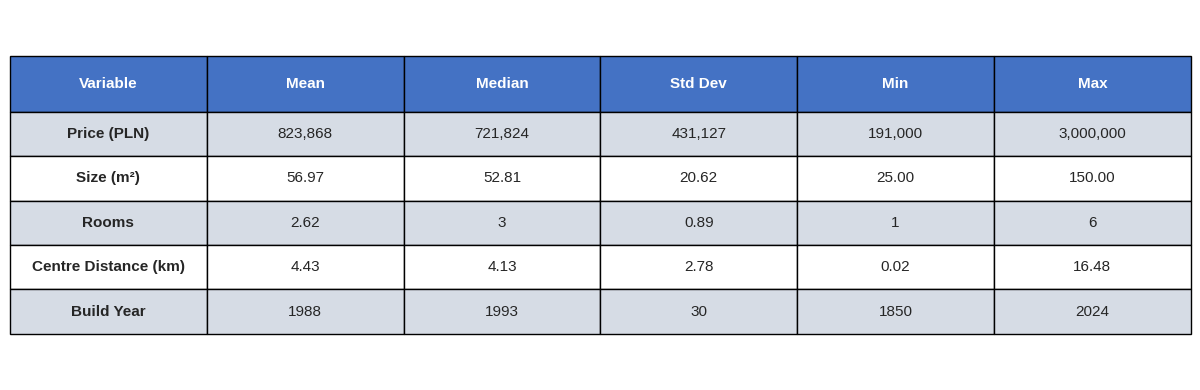

In [3]:
# Select key variables for the summary
key_vars = ['price', 'squareMeters', 'rooms', 'centreDistance', 'buildYear']

# Calculate statistics
stats_data = []
for var in key_vars:
    stats_data.append({
        'Variable': var,
        'Mean': df_clean[var].mean(),
        'Median': df_clean[var].median(),
        'Std Dev': df_clean[var].std(),
        'Min': df_clean[var].min(),
        'Max': df_clean[var].max()
    })

stats_df = pd.DataFrame(stats_data)

# Rename variables for presentation
var_names = {
    'price': 'Price (PLN)',
    'squareMeters': 'Size (m²)',
    'rooms': 'Rooms',
    'centreDistance': 'Centre Distance (km)',
    'buildYear': 'Build Year'
}
stats_df['Variable'] = stats_df['Variable'].map(var_names)

# Format the numbers nicely based on variable type
def format_row(row):
    var = row['Variable']
    if var == 'Price (PLN)':
        return pd.Series({
            'Variable': var,
            'Mean': f"{row['Mean']:,.0f}",
            'Median': f"{row['Median']:,.0f}",
            'Std Dev': f"{row['Std Dev']:,.0f}",
            'Min': f"{row['Min']:,.0f}",
            'Max': f"{row['Max']:,.0f}"
        })
    elif var == 'Build Year':
        return pd.Series({
            'Variable': var,
            'Mean': f"{row['Mean']:.0f}",
            'Median': f"{row['Median']:.0f}",
            'Std Dev': f"{row['Std Dev']:.0f}",
            'Min': f"{row['Min']:.0f}",
            'Max': f"{row['Max']:.0f}"
        })
    elif var == 'Rooms':
        return pd.Series({
            'Variable': var,
            'Mean': f"{row['Mean']:.2f}",
            'Median': f"{row['Median']:.0f}",
            'Std Dev': f"{row['Std Dev']:.2f}",
            'Min': f"{row['Min']:.0f}",
            'Max': f"{row['Max']:.0f}"
        })
    else:
        return pd.Series({
            'Variable': var,
            'Mean': f"{row['Mean']:.2f}",
            'Median': f"{row['Median']:.2f}",
            'Std Dev': f"{row['Std Dev']:.2f}",
            'Min': f"{row['Min']:.2f}",
            'Max': f"{row['Max']:.2f}"
        })

stats_formatted = stats_df.apply(format_row, axis=1)

print(stats_formatted.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 4))
ax.axis('off')
ax.axis('tight')

# Create table data
table_data = stats_formatted.values.tolist()
col_labels = stats_formatted.columns.tolist()

# Create the table with custom styling
table = ax.table(
    cellText=table_data,
    colLabels=col_labels,
    cellLoc='center',
    loc='center',
    colColours=['#4472C4'] * len(col_labels),  # Header color (blue)
)

# Style the table
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 2.0)  # Scale width and height

# Style header cells
for j, col in enumerate(col_labels):
    table[(0, j)].set_text_props(weight='bold', color='white')
    table[(0, j)].set_facecolor('#4472C4')
    table[(0, j)].set_height(0.15)

# Style data cells with alternating colors
for i in range(len(table_data)):
    for j in range(len(col_labels)):
        cell = table[(i + 1, j)]
        if i % 2 == 0:
            cell.set_facecolor('#D6DCE5')  # Light gray for even rows
        else:
            cell.set_facecolor('#FFFFFF')  # White for odd rows
        cell.set_height(0.12)

        # Bold the variable names column
        if j == 0:
            cell.set_text_props(weight='bold')

plt.tight_layout()
plt.show()

##Exploratory Data Analysis

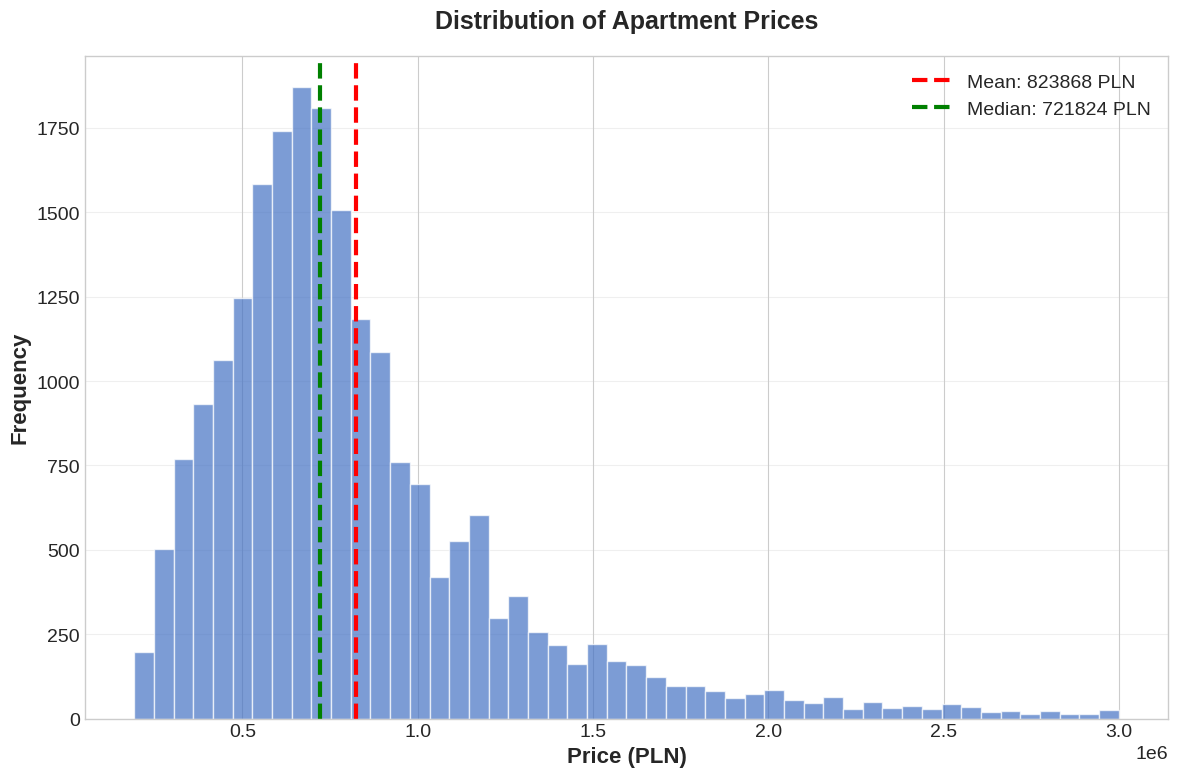

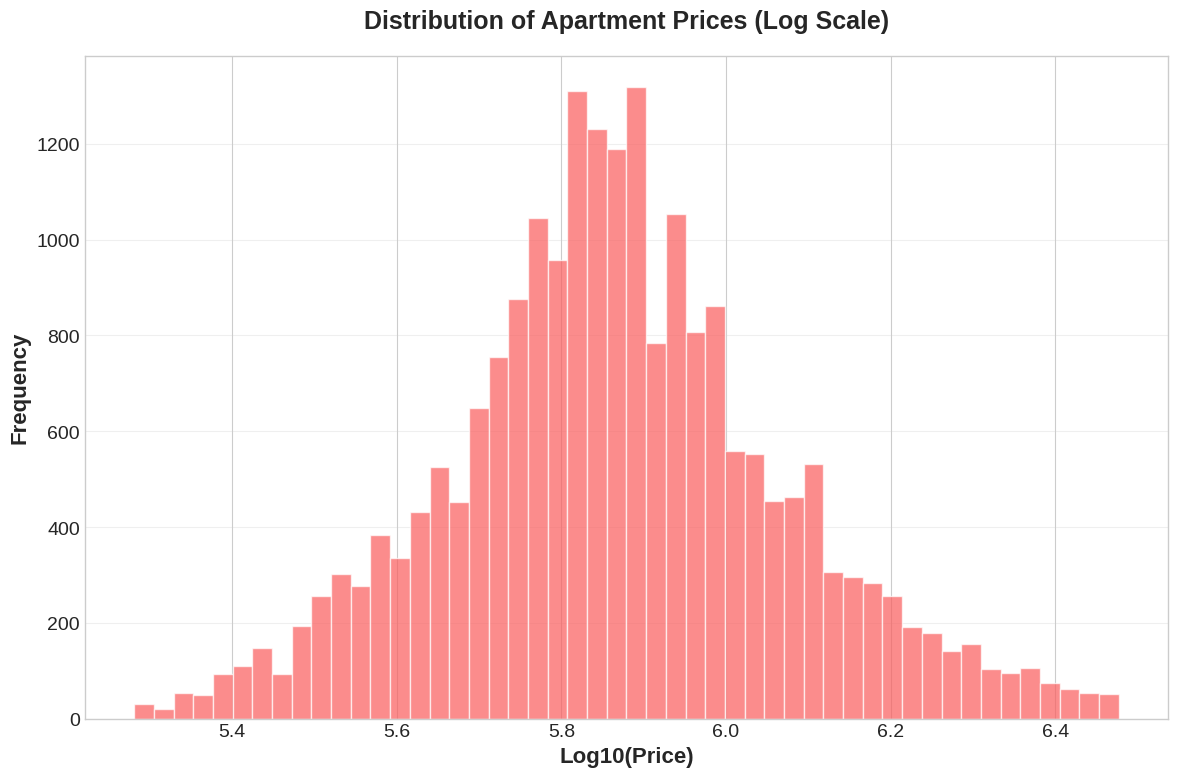

In [4]:
# Slide 8

# Distribution of Price (Target Variable)

# Set global font sizes
plt.rcParams.update({'font.size': 14})

# Graph 1: Original scale
fig1, ax1 = plt.subplots(figsize=(12, 8))

ax1.hist(df_clean['price'], bins=50, color='#4472C4', edgecolor='white', alpha=0.7)
ax1.axvline(df_clean['price'].mean(), color='red', linestyle='--', linewidth=3,
            label=f"Mean: {df_clean['price'].mean():.0f} PLN")
ax1.axvline(df_clean['price'].median(), color='green', linestyle='--', linewidth=3,
            label=f"Median: {df_clean['price'].median():.0f} PLN")
ax1.set_xlabel('Price (PLN)', fontsize=16, fontweight='bold')
ax1.set_ylabel('Frequency', fontsize=16, fontweight='bold')
ax1.set_title('Distribution of Apartment Prices', fontsize=18, fontweight='bold', pad=20)
ax1.tick_params(axis='both', labelsize=14)
ax1.legend(fontsize=14, loc='best')
ax1.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Graph 2: Log scale
fig2, ax2 = plt.subplots(figsize=(12, 8))

ax2.hist(np.log10(df_clean['price']), bins=50, color='#FA5C5C', edgecolor='white', alpha=0.7)
ax2.set_xlabel('Log10(Price)', fontsize=16, fontweight='bold')
ax2.set_ylabel('Frequency', fontsize=16, fontweight='bold')
ax2.set_title('Distribution of Apartment Prices (Log Scale)', fontsize=18, fontweight='bold', pad=20)
ax2.tick_params(axis='both', labelsize=14)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Reset font sizes to default
plt.rcParams.update({'font.size': 10})

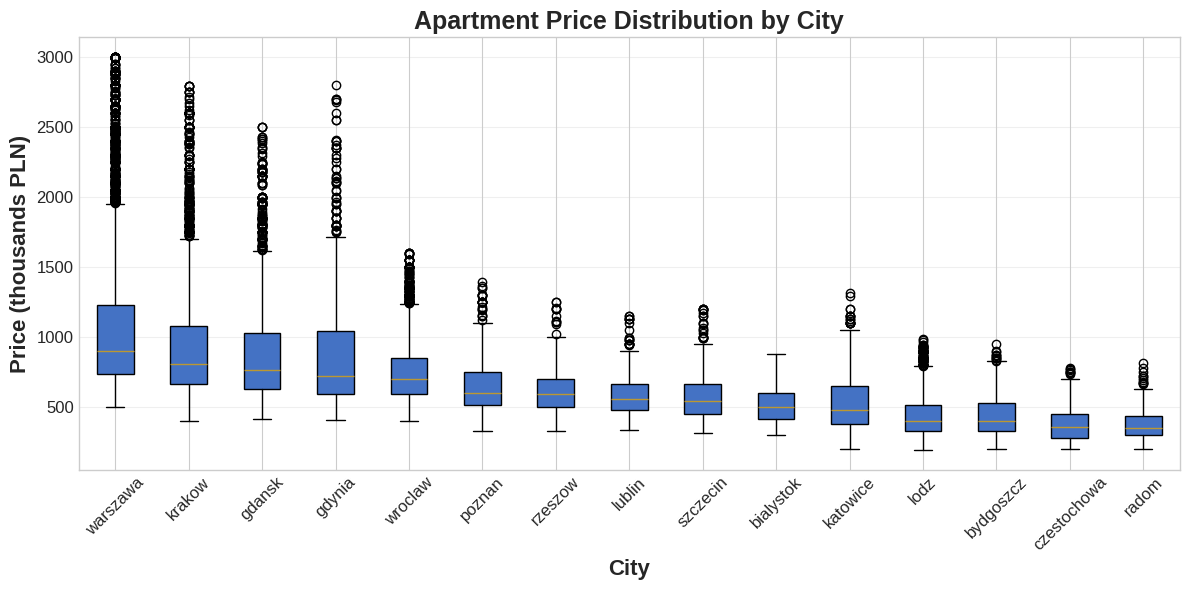

In [5]:
# Slide 9
# Price by City
fig, ax = plt.subplots(figsize=(12, 6))

city_order = df_clean.groupby('city')['price'].median().sort_values(ascending=False).index
df_clean['city_ordered'] = pd.Categorical(df_clean['city'], categories=city_order, ordered=True)

bp = ax.boxplot([df_clean[df_clean['city'] == city]['price'] / 1000 for city in city_order],
                labels=city_order,
                patch_artist=True,
                showmeans=False)

for patch in bp['boxes']:
    patch.set_facecolor('#4472C4')

ax.set_xlabel('City', fontsize=16, fontweight='bold')
ax.set_ylabel('Price (thousands PLN)', fontsize=16, fontweight='bold')
ax.set_title('Apartment Price Distribution by City', fontsize=18, fontweight='bold')
ax.tick_params(axis='x', rotation=45, labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

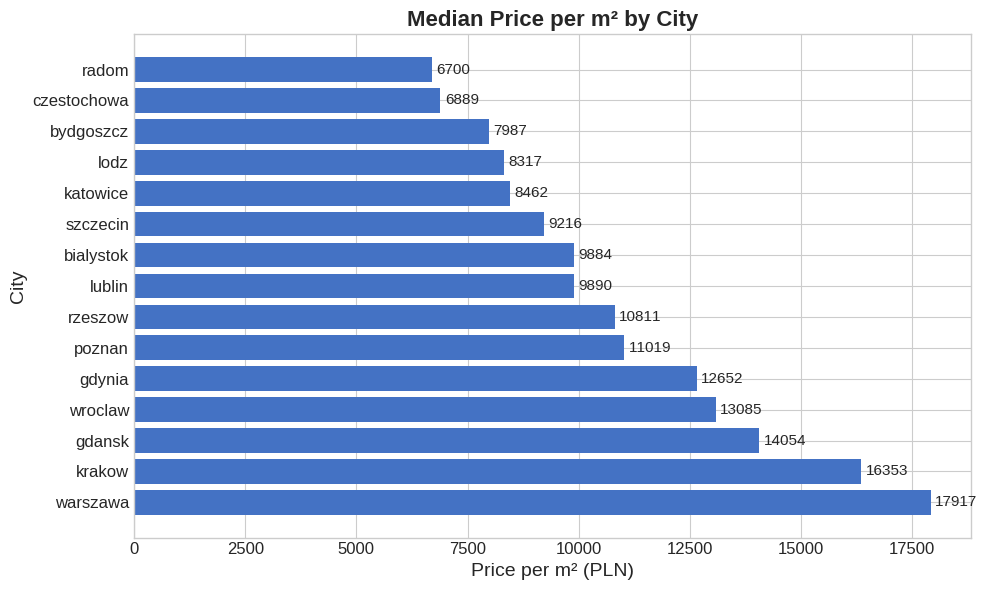

In [6]:
# Slide 10
# Price per Square Meter Analysis

df_clean['price_per_sqm'] = df_clean['price'] / df_clean['squareMeters']

# By city
plt.figure(figsize=(10, 6))
city_order = df_clean.groupby('city')['price_per_sqm'].median().sort_values(ascending=False).index
city_medians = df_clean.groupby('city')['price_per_sqm'].median()[city_order]
plt.barh(city_medians.index, city_medians.values, color='#4472C4')
plt.xlabel('Price per m² (PLN)', fontsize=14)
plt.ylabel('City', fontsize=14)
plt.title('Median Price per m² by City', fontsize=16, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
for i, v in enumerate(city_medians.values):
    plt.text(v + 100, i, f'{v:.0f}', va='center', fontsize=11)

plt.tight_layout()
plt.show()

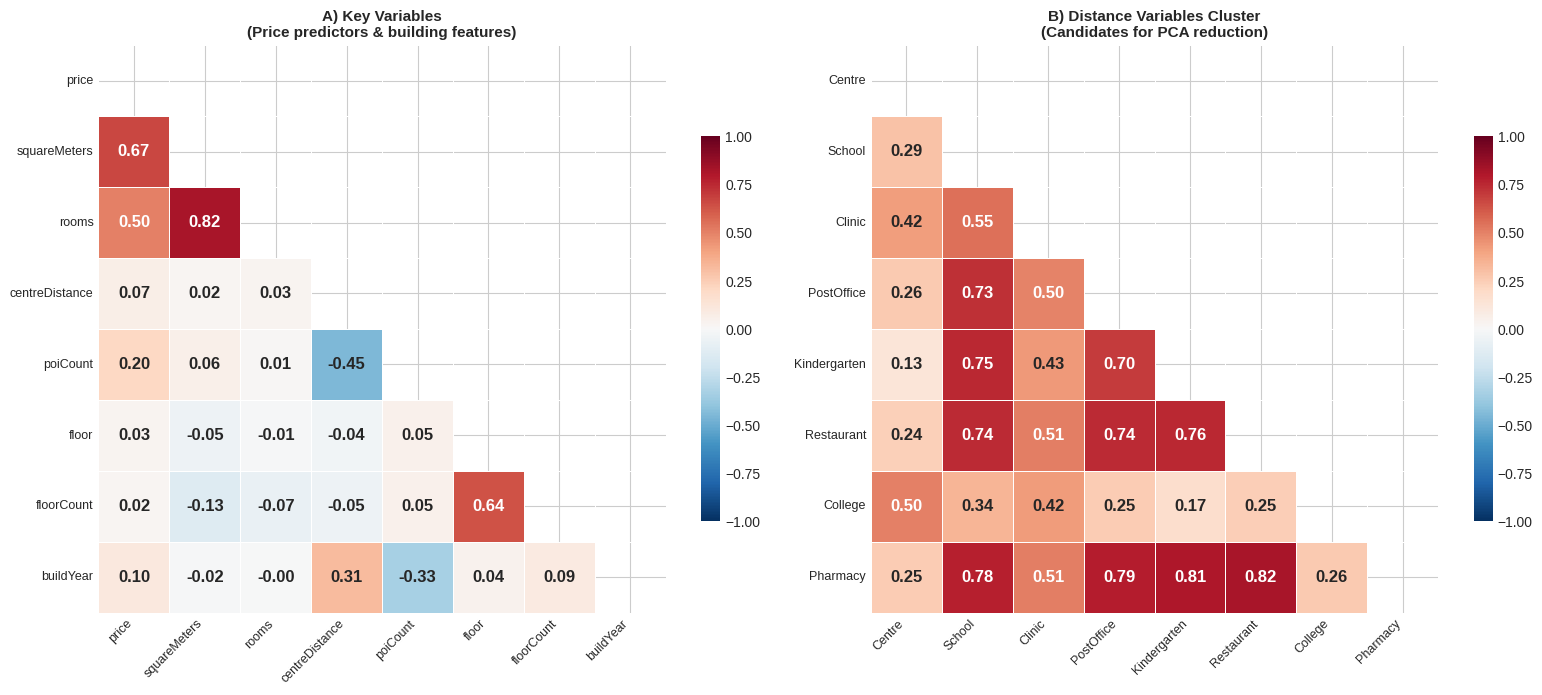

In [7]:
# Slide 11
# Correlation analysis

# Key variables for Panel A
key_vars = [
    'price',           # Target variable
    'squareMeters',    # r = 0.67 with price (strongest predictor)
    'rooms',           # r = 0.50 with price, r = 0.82 with squareMeters
    'centreDistance',  # Central location measure
    'poiCount',        # r = 0.20 with price, accessibility proxy
    'floor',           # r = 0.67 with floorCount
    'floorCount',      # Building size indicator
    'buildYear',       # Age of building
]

# Distance variables for Panel B (highly correlated cluster)
distance_vars = ['centreDistance', 'schoolDistance', 'clinicDistance',
                 'postOfficeDistance', 'kindergartenDistance',
                 'restaurantDistance', 'collegeDistance', 'pharmacyDistance']

short_names = ['Centre', 'School', 'Clinic', 'PostOffice',
               'Kindergarten', 'Restaurant', 'College', 'Pharmacy']

# Compute correlation matrices
corr_key = df_clean[key_vars].corr()
corr_dist = df_clean[distance_vars].corr()

# Combined two-panel figure

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Panel A: Key Variables
mask1 = np.triu(np.ones_like(corr_key, dtype=bool))
sns.heatmap(corr_key, mask=mask1, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=axes[0],
            annot_kws={'size': 12, 'weight': 'bold'}, vmin=-1, vmax=1,
            cbar_kws={'shrink': 0.6})
axes[0].set_title('A) Key Variables\n(Price predictors & building features)',
                  fontsize=11, fontweight='bold')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right', fontsize=9)
axes[0].set_yticklabels(axes[0].get_yticklabels(), fontsize=9)

# Panel B: Distance Cluster
mask2 = np.triu(np.ones_like(corr_dist, dtype=bool))
sns.heatmap(corr_dist, mask=mask2, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=axes[1],
            annot_kws={'size': 12, 'weight': 'bold'}, vmin=-1, vmax=1,
            cbar_kws={'shrink': 0.6})
axes[1].set_title('B) Distance Variables Cluster\n(Candidates for PCA reduction)',
                  fontsize=11, fontweight='bold')
axes[1].set_xticklabels(short_names, rotation=45, ha='right', fontsize=9)
axes[1].set_yticklabels(short_names, fontsize=9)

plt.tight_layout()
plt.show()

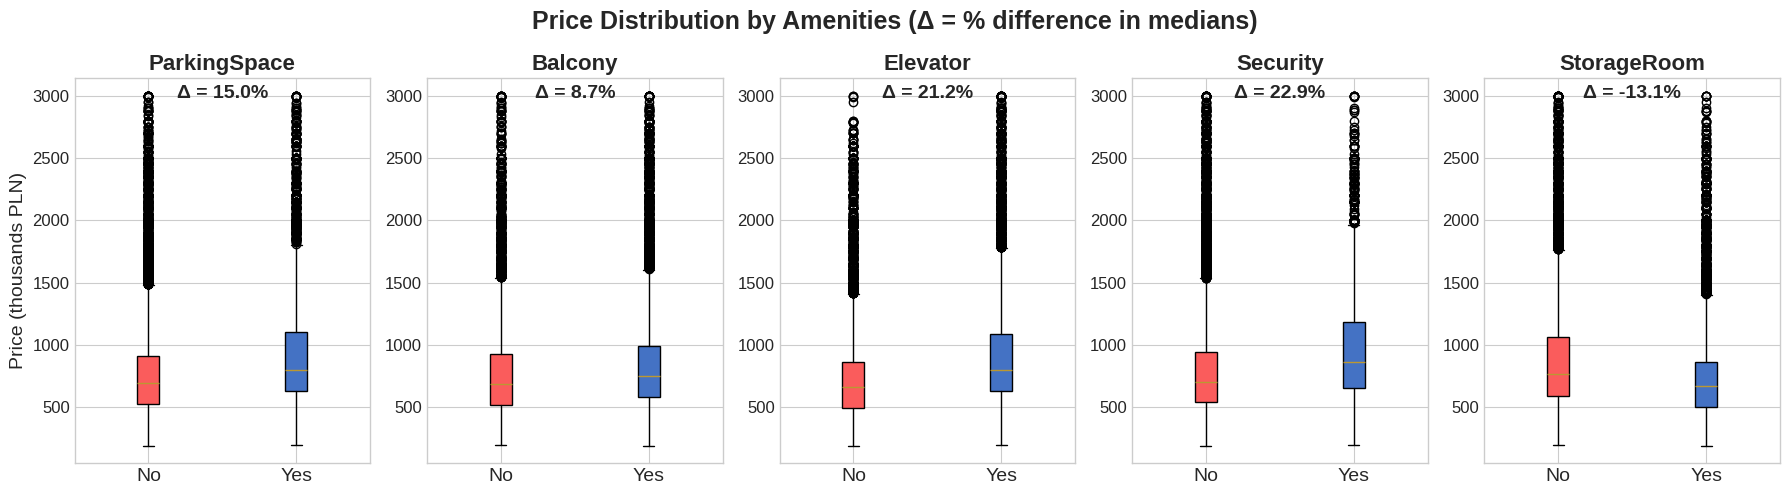

In [8]:
# Slide 12
# Amenities Impact on Price

amenity_vars = ['hasParkingSpace', 'hasBalcony', 'hasElevator', 'hasSecurity', 'hasStorageRoom']

fig, axes = plt.subplots(1, len(amenity_vars), figsize=(18, 5))

for i, var in enumerate(amenity_vars):
    data_yes = df_clean[df_clean[var] == 'yes']['price'] / 1000
    data_no = df_clean[df_clean[var] == 'no']['price'] / 1000

    bp = axes[i].boxplot([data_no, data_yes], labels=['No', 'Yes'], patch_artist=True)
    bp['boxes'][0].set_facecolor('#FA5C5C')
    bp['boxes'][1].set_facecolor('#4472C4')

    # Increased font sizes for axis labels
    axes[i].set_ylabel('Price (thousands PLN)' if i == 0 else '', fontsize=14)
    axes[i].set_title(var.replace('has', ''), fontsize=16, fontweight='bold')

    # Increased font size for x-axis labels ('No', 'Yes')
    axes[i].tick_params(axis='x', labelsize=14)
    # Increased font size for y-axis values
    axes[i].tick_params(axis='y', labelsize=12)

    # Add median values with increased font size
    med_no = data_no.median()
    med_yes = data_yes.median()
    axes[i].text(0.5, 0.95, f'Δ = {((med_yes-med_no)/med_no*100):.1f}%',
                 transform=axes[i].transAxes, ha='center', fontsize=14, fontweight='bold')

plt.suptitle('Price Distribution by Amenities (Δ = % difference in medians)', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

##Inferences about a Mean Vector


Data: Warsaw apartments only
Sample size (n): 6962
Number of variables (p): 7
Variables: ['schoolDistance', 'clinicDistance', 'postOfficeDistance', 'kindergartenDistance', 'restaurantDistance', 'collegeDistance', 'pharmacyDistance']

Sample Mean Vector (X̄):
  schoolDistance           : 0.3499 km
  clinicDistance           : 0.8144 km
  postOfficeDistance       : 0.4706 km
  kindergartenDistance     : 0.2653 km
  restaurantDistance       : 0.2413 km
  collegeDistance          : 1.5090 km
  pharmacyDistance         : 0.2931 km

Sample Covariance Matrix (S):
              school  clinic  postOffice  kindergarten  restaurant  college  pharmacy
school        0.0732  0.1205      0.0444        0.0256      0.0247   0.1439    0.0339
clinic        0.1205  0.7185      0.1208        0.0681      0.0845   0.5901    0.1059
postOffice    0.0444  0.1208      0.1015        0.0242      0.0372   0.1325    0.0437
kindergarten  0.0256  0.0681      0.0242        0.0414      0.0218   0.0658    0.0277
restau

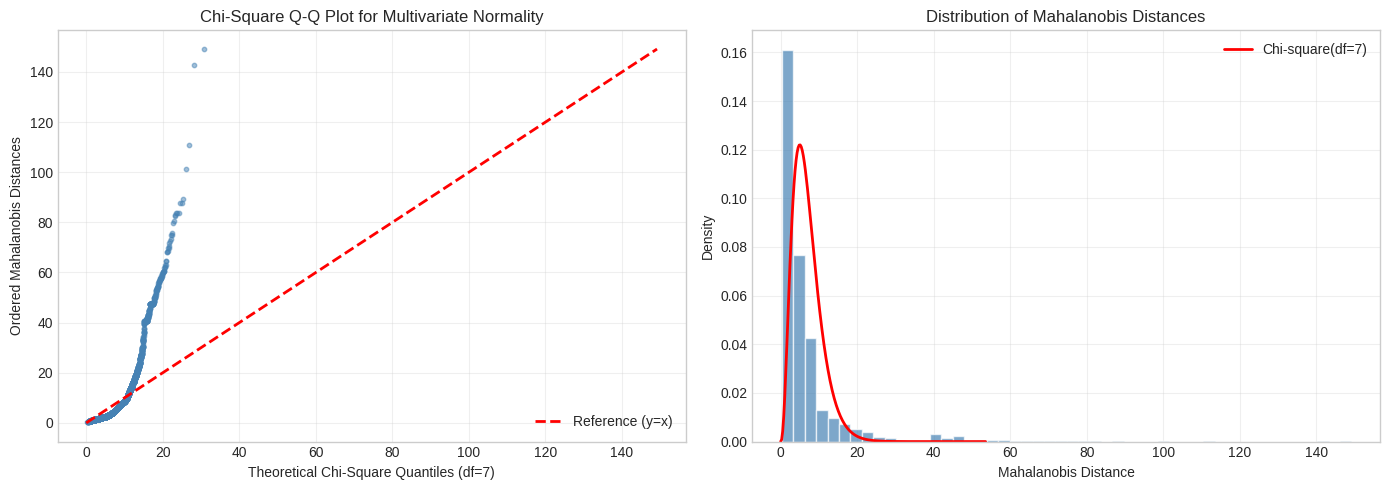


Test Results:
  Hotelling's T²     : 172637.9759
  F-statistic        : 24641.3102
  df                 : (7, 6955)
  Critical F (α=0.05): 2.0109
  p-value            : 1.11e-16

Decision:
  Since F = 24641.31 > F_crit = 2.0109 and p-value < alpha,
  Reject H_0 at alpha = 0.05

Multipliers:
  Simultaneous: √[(p(n-1)/(n-p)) × F_crit] = 3.7535
  Bonferroni:   t_(n-1, α/2p) = t_(6961, 0.003571) = 2.6909
school                 0.3499     0.3377     0.3620          No*
clinic                 0.8144     0.7762     0.8525          No*
postOffice             0.4706     0.4562     0.4849          No*
kindergarten           0.2653     0.2562     0.2745          No*
restaurant             0.2413     0.2312     0.2515          No*
college                1.5090     1.4573     1.5608          No*
pharmacy               0.2931     0.2816     0.3047          No*

--------------------------------------------------------------------------------
BONFERRONI CONFIDENCE INTERVALS (95%)
--------------------

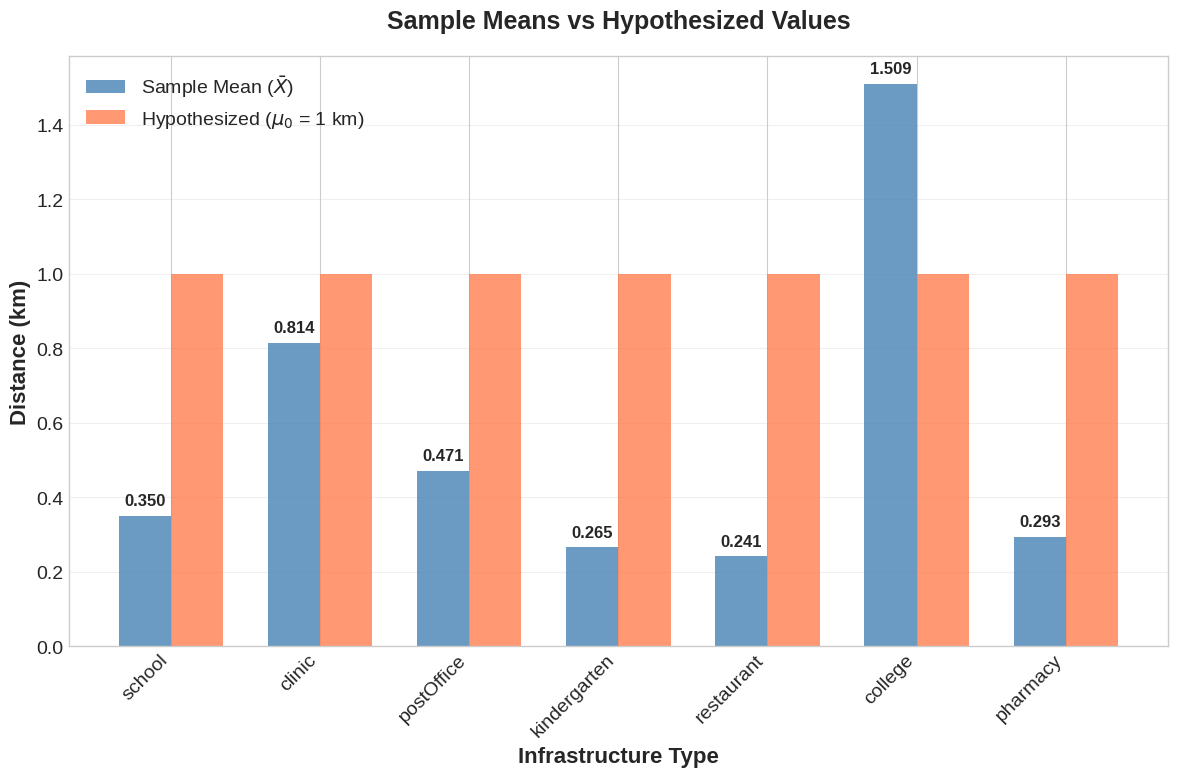

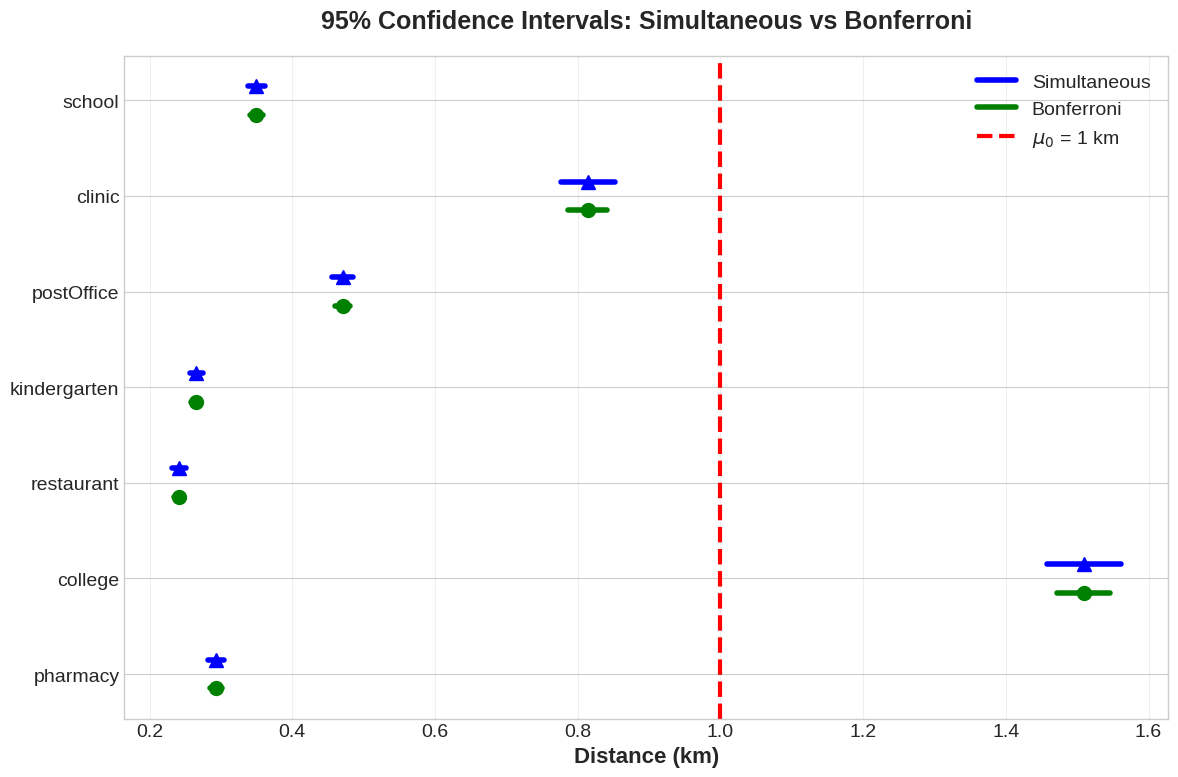


RESULT: H_0 REJECTED (p-value < 0.0001)

The mean distance vector of Warsaw apartments is significantly
different from the hypothesized 1 km benchmark.

Individual findings (Bonferroni CIs):
  • 6 variables are CLOSER than 1 km (school, clinic, post office,
    kindergarten, restaurant, pharmacy)
  • 1 variable is FARTHER than 1 km (college: mean = 1.509 km)

CI Comparison:
  • Simultaneous CIs are wider (valid for ALL linear combinations)
  • Bonferroni CIs are narrower (valid for p=7 individual tests only)
  • For individual variable inference, Bonferroni is more powerful



In [9]:
# One-Sample Hotelling's T² Test for Warsaw Apartments
"""
Research Question: Are important infrastructural objects (school, clinic,
post office, kindergarten, restaurant, college, pharmacy) within 1 km
of apartments in Warsaw on average?

H₀: μ = μ₀ = (1, 1, 1, 1, 1, 1, 1)' km
H₁: μ ≠ μ₀
"""

# Data Preparation

# Filter for Warsaw only
df_warsaw = df_clean[df_clean['city'] == 'warszawa'].copy()

# Select infrastructure distance variables (excluding centreDistance)
mean_vector_vars = ['schoolDistance', 'clinicDistance', 'postOfficeDistance',
                    'kindergartenDistance', 'restaurantDistance', 'collegeDistance',
                    'pharmacyDistance']

# Extract data matrix
X = df_warsaw[mean_vector_vars].values
n, p = X.shape

print(f"\nData: Warsaw apartments only")
print(f"Sample size (n): {n}")
print(f"Number of variables (p): {p}")
print(f"Variables: {mean_vector_vars}")

# Descriptive Statistics

# Sample mean vector
X_bar = np.mean(X, axis=0)

# Sample covariance matrix
S = np.cov(X, rowvar=False)

print("\nSample Mean Vector (X̄):")
for i, var in enumerate(mean_vector_vars):
    print(f"  {var:25s}: {X_bar[i]:.4f} km")

print("\nSample Covariance Matrix (S):")
S_df = pd.DataFrame(S,
                    index=[v.replace('Distance', '') for v in mean_vector_vars],
                    columns=[v.replace('Distance', '') for v in mean_vector_vars])
print(S_df.round(4).to_string())

# Assumption Checking

# Univariate Normality (Shapiro-Wilk)

alpha = 0.05
np.random.seed(42)
subset_idx = np.random.choice(n, min(5000, n), replace=False)

print(f"{'Variable':<25} {'W-stat':>10} {'p-value':>12} {'Normal?':>10}")
print("-"*60)
for i, var in enumerate(mean_vector_vars):
    stat, p_val = stats.shapiro(X[subset_idx, i])
    normal = "Yes" if p_val > alpha else "No"
    print(f"{var:<25} {stat:>10.4f} {p_val:>12.2e} {normal:>10}")

# Multivariate Normality - Chi-Square Q-Q Plot

from scipy.stats import chi2

# Calculate Mahalanobis distances
X_centered = X - X_bar
S_inv = np.linalg.inv(S)
mahal_dist = np.array([x @ S_inv @ x for x in X_centered])

# Theoretical quantiles
mahal_sorted = np.sort(mahal_dist)
probs = (np.arange(1, n + 1) - 0.5) / n
chi2_quantiles = chi2.ppf(probs, df=p)

# Q-Q correlation
qq_corr = np.corrcoef(chi2_quantiles, mahal_sorted)[0, 1]
print(f"Q-Q Plot correlation: {qq_corr:.4f}")
print("(Values close to 1 indicate multivariate normality)")

# Create Q-Q plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.scatter(chi2_quantiles, mahal_sorted, alpha=0.5, s=10, color='steelblue')
max_val = max(chi2_quantiles.max(), mahal_sorted.max())
ax1.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Reference (y=x)')
ax1.set_xlabel('Theoretical Chi-Square Quantiles (df=7)')
ax1.set_ylabel('Ordered Mahalanobis Distances')
ax1.set_title('Chi-Square Q-Q Plot for Multivariate Normality')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.hist(mahal_dist, bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='white')
x_range = np.linspace(0, np.percentile(mahal_dist, 99), 200)
ax2.plot(x_range, chi2.pdf(x_range, df=p), 'r-', linewidth=2, label=f'Chi-square(df={p})')
ax2.set_xlabel('Mahalanobis Distance')
ax2.set_ylabel('Density')
ax2.set_title('Distribution of Mahalanobis Distances')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# CLT Justification
"""
Although normality tests may reject (common with large n),
CLT provides justification for Hotelling's T² test:

  • Sample size: n = {n}
  • Variables: p = {p}
  • Ratio n/p = {n/p:.1f} >> 20 (recommended minimum)

CONCLUSION: Proceed with Hotelling's T² test.
"""

# One-sample Hotelling's T^2 Test

# Hypothesized mean vector: all distances = 1 km
mu_0 = np.ones(p)

# Calculate test statistic
diff = X_bar - mu_0
T2 = n * diff @ S_inv @ diff

# Convert to F-statistic
F_stat = T2 * (n - p) / (p * (n - 1))
df1, df2 = p, n - p

# Critical value and p-value
F_crit = stats.f.ppf(1 - alpha, df1, df2)
p_value = 1 - stats.f.cdf(F_stat, df1, df2)

print(f"\nTest Results:")
print(f"  Hotelling's T²     : {T2:.4f}")
print(f"  F-statistic        : {F_stat:.4f}")
print(f"  df                 : ({df1}, {df2})")
print(f"  Critical F (α=0.05): {F_crit:.4f}")
print(f"  p-value            : {p_value:.2e}")

print(f"\nDecision:")
if p_value < alpha:
    print(f"  Since F = {F_stat:.2f} > F_crit = {F_crit:.4f} and p-value < alpha,")
    print(f"  Reject H_0 at alpha = {alpha}")
else:
    print(f"  Fail to reject H_0 at alpha = {alpha}")

# Simultaneous and Bonferroni Confidence Intervals

# Standard errors
se = np.sqrt(np.diag(S) / n)

# Simultaneous CI multiplier
simult_mult = np.sqrt(p * (n - 1) / (n - p) * F_crit)

# Bonferroni CI multiplier
t_bonf = stats.t.ppf(1 - alpha / (2 * p), n - 1)

print(f"\nMultipliers:")
print(f"  Simultaneous: √[(p(n-1)/(n-p)) × F_crit] = {simult_mult:.4f}")
print(f"  Bonferroni:   t_(n-1, α/2p) = t_({n-1}, {alpha/(2*p):.6f}) = {t_bonf:.4f}")

# Calculate CIs
simult_results = []
for i, var in enumerate(mean_vector_vars):
    lower = X_bar[i] - simult_mult * se[i]
    upper = X_bar[i] + simult_mult * se[i]
    contains = "Yes" if lower <= 1 <= upper else "No*"
    simult_results.append((var, X_bar[i], lower, upper, contains))
    print(f"{var.replace('Distance',''):<20} {X_bar[i]:>8.4f} {lower:>10.4f} {upper:>10.4f} {contains:>12}")

print("\n" + "-"*80)
print("BONFERRONI CONFIDENCE INTERVALS (95%)")
print("-"*80)
print(f"{'Variable':<20} {'X̄':>8} {'Lower':>10} {'Upper':>10} {'Contains 1?':>12}")
print("-"*80)

bonf_results = []
for i, var in enumerate(mean_vector_vars):
    lower = X_bar[i] - t_bonf * se[i]
    upper = X_bar[i] + t_bonf * se[i]
    contains = "Yes" if lower <= 1 <= upper else "No*"
    bonf_results.append((var, X_bar[i], lower, upper, contains))
    print(f"{var.replace('Distance',''):<20} {X_bar[i]:>8.4f} {lower:>10.4f} {upper:>10.4f} {contains:>12}")

print("\n* μ₀ = 1 km is NOT in CI → significantly different from benchmark")

# Width comparison
print("\n" + "-"*50)
print("CI WIDTH COMPARISON")
print("-"*50)
simult_widths = [2 * simult_mult * se[i] for i in range(p)]
bonf_widths = [2 * t_bonf * se[i] for i in range(p)]

print(f"{'Variable':<20} {'Simult Width':>14} {'Bonf Width':>14} {'Ratio':>10}")
print("-"*60)
for i, var in enumerate(mean_vector_vars):
    ratio = simult_widths[i] / bonf_widths[i]
    print(f"{var.replace('Distance',''):<20} {simult_widths[i]:>14.4f} {bonf_widths[i]:>14.4f} {ratio:>10.4f}")

print(f"\nSimultaneous CIs are {simult_mult/t_bonf:.2f}x wider than Bonferroni CIs")

# Visualization

# Set global font sizes
plt.rcParams.update({'font.size': 14})

# Plot 1: Sample Means vs Hypothesized
fig1, ax1 = plt.subplots(figsize=(12, 8))

x_pos = np.arange(p)
width = 0.35

ax1.bar(x_pos - width/2, X_bar, width, label=r'Sample Mean ($\bar{X}$)', color='steelblue', alpha=0.8)
ax1.bar(x_pos + width/2, mu_0, width, label=r'Hypothesized ($\mu_0$ = 1 km)', color='coral', alpha=0.8)
ax1.set_xlabel('Infrastructure Type', fontsize=16, fontweight='bold')
ax1.set_ylabel('Distance (km)', fontsize=16, fontweight='bold')
ax1.set_title('Sample Means vs Hypothesized Values', fontsize=18, fontweight='bold', pad=20)
ax1.set_xticks(x_pos)
ax1.set_xticklabels([v.replace('Distance', '') for v in mean_vector_vars],
                     rotation=45, ha='right', fontsize=14)
ax1.tick_params(axis='y', labelsize=14)
ax1.legend(fontsize=14, loc='best')
ax1.grid(axis='y', alpha=0.3)

# Add value labels
for i, v in enumerate(X_bar):
    ax1.text(i - width/2, v + 0.02, f'{v:.3f}', ha='center', va='bottom',
             fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Plot 2: CI Comparison
fig2, ax2 = plt.subplots(figsize=(12, 8))

for i in range(p):
    y = p - 1 - i

    # Simultaneous CI
    s_lower = X_bar[i] - simult_mult * se[i]
    s_upper = X_bar[i] + simult_mult * se[i]
    ax2.plot([s_lower, s_upper], [y + 0.15, y + 0.15], 'b-', linewidth=4,
             label='Simultaneous' if i == 0 else '')
    ax2.plot(X_bar[i], y + 0.15, 'b^', markersize=10)

    # Bonferroni CI
    b_lower = X_bar[i] - t_bonf * se[i]
    b_upper = X_bar[i] + t_bonf * se[i]
    ax2.plot([b_lower, b_upper], [y - 0.15, y - 0.15], 'g-', linewidth=4,
             label='Bonferroni' if i == 0 else '')
    ax2.plot(X_bar[i], y - 0.15, 'go', markersize=10)

ax2.axvline(x=1, color='red', linestyle='--', linewidth=3, label=r'$\mu_0$ = 1 km')
ax2.set_yticks(range(p))
ax2.set_yticklabels([v.replace('Distance', '') for v in mean_vector_vars][::-1], fontsize=14)
ax2.tick_params(axis='x', labelsize=14)
ax2.set_xlabel('Distance (km)', fontsize=16, fontweight='bold')
ax2.set_title('95% Confidence Intervals: Simultaneous vs Bonferroni',
              fontsize=18, fontweight='bold', pad=20)
ax2.legend(loc='upper right', fontsize=14)
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Reset font sizes to default
plt.rcParams.update({'font.size': 10})

# Summary
print(f"""
RESULT: H_0 REJECTED (p-value < 0.0001)

The mean distance vector of Warsaw apartments is significantly
different from the hypothesized 1 km benchmark.

Individual findings (Bonferroni CIs):
  • 6 variables are CLOSER than 1 km (school, clinic, post office,
    kindergarten, restaurant, pharmacy)
  • 1 variable is FARTHER than 1 km (college: mean = {X_bar[5]:.3f} km)

CI Comparison:
  • Simultaneous CIs are wider (valid for ALL linear combinations)
  • Bonferroni CIs are narrower (valid for p={p} individual tests only)
  • For individual variable inference, Bonferroni is more powerful
""")

##Comparisons of Several Multivariate Means

###Part 1 Comparing apartments with/without amenities

In [10]:
# Set style for visualizations
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Key variables
key_vars = ['squareMeters', 'price', 'rooms', 'floor', 'floorCount', 'buildYear']

# Helper functions for Hotelling's T^2 Test
def hotellings_t2_test(group1, group2, alpha=0.05):
    """
    Perform Two-sample Hotelling's T² test.

    H0: μ1 = μ2 (mean vectors are equal)
    H1: μ1 ≠ μ2 (mean vectors are not equal)
    """
    X1 = np.array(group1)
    X2 = np.array(group2)

    n1, p = X1.shape
    n2 = X2.shape[0]

    x1_bar = np.mean(X1, axis=0)
    x2_bar = np.mean(X2, axis=0)

    S1 = np.cov(X1, rowvar=False)
    S2 = np.cov(X2, rowvar=False)

    S_pooled = ((n1 - 1) * S1 + (n2 - 1) * S2) / (n1 + n2 - 2)

    diff = x1_bar - x2_bar

    S_pooled_inv = np.linalg.inv(S_pooled)
    T2 = (n1 * n2) / (n1 + n2) * diff @ S_pooled_inv @ diff

    # F-statistic conversion
    F_stat = T2 * (n1 + n2 - p - 1) / (p * (n1 + n2 - 2))

    df1 = p
    df2 = n1 + n2 - p - 1

    p_value = 1 - f_dist.cdf(F_stat, df1, df2)

    F_critical = f_dist.ppf(1 - alpha, df1, df2)
    T2_critical = p * (n1 + n2 - 2) / (n1 + n2 - p - 1) * F_critical

    reject_null = p_value < alpha

    return {
        'n1': n1,
        'n2': n2,
        'p': p,
        'mean1': x1_bar,
        'mean2': x2_bar,
        'T2': T2,
        'F_stat': F_stat,
        'df1': df1,
        'df2': df2,
        'p_value': p_value,
        'F_critical': F_critical,
        'T2_critical': T2_critical,
        'alpha': alpha,
        'reject_null': reject_null
    }


def print_hotelling_results(results, group1_name, group2_name, var_names):
    """Print formatted results of Hotelling's T² test."""
    print("\n" + "="*80)
    print(f"TWO-SAMPLE HOTELLING'S T² TEST: {group1_name} vs {group2_name}")
    print("="*80)

    print(f"\nHypotheses:")
    print(f"  H₀: μ₁ = μ₂ (mean vectors are equal)")
    print(f"  H₁: μ₁ ≠ μ₂ (mean vectors are not equal)")

    print(f"\nSample Information:")
    print(f"  Group 1 ({group1_name}): n₁ = {results['n1']}")
    print(f"  Group 2 ({group2_name}): n₂ = {results['n2']}")
    print(f"  Number of variables (p): {results['p']}")

    print(f"\nSample Mean Vectors:")
    print("-" * 60)
    print(f"{'Variable':<20} {group1_name:>15} {group2_name:>15}")
    print("-" * 60)
    for i, var in enumerate(var_names):
        print(f"{var:<20} {results['mean1'][i]:>15.2f} {results['mean2'][i]:>15.2f}")
    print("-" * 60)

    print(f"\nTest Statistics:")
    print(f"  Hotelling's T² = {results['T2']:.4f}")
    print(f"  F-statistic = {results['F_stat']:.4f}")
    print(f"  Degrees of freedom: df₁ = {results['df1']}, df₂ = {results['df2']}")

    print(f"\nCritical Values (α = {results['alpha']}):")
    print(f"  F-critical = {results['F_critical']:.4f}")
    print(f"  T²-critical = {results['T2_critical']:.4f}")

    print(f"\nP-value: {results['p_value']:.6e}")

    print(f"\nDecision at α = {results['alpha']}:")
    if results['reject_null']:
        print(f"  *** REJECT H₀ ***")
        print(f"  There is significant evidence that the mean vectors differ.")
    else:
        print(f"  FAIL TO REJECT H₀")
        print(f"  No significant evidence that the mean vectors differ.")

    return results


# Two-sample Hotelling's T^2 Test
df_analysis = df_clean[key_vars + ['hasBalcony', 'hasParkingSpace', 'hasElevator',
                                    'hasSecurity', 'hasStorageRoom']].dropna()

hotelling_results = {}

# Test 1: Has Balcony vs No Balcony
group1 = df_analysis[df_analysis['hasBalcony'] == 'yes'][key_vars]
group2 = df_analysis[df_analysis['hasBalcony'] == 'no'][key_vars]
results_balcony = hotellings_t2_test(group1, group2)
print_hotelling_results(results_balcony, "Has Balcony", "No Balcony", key_vars)
hotelling_results['Balcony'] = results_balcony

# Test 2: Has Parking Space vs No Parking Space
group1 = df_analysis[df_analysis['hasParkingSpace'] == 'yes'][key_vars]
group2 = df_analysis[df_analysis['hasParkingSpace'] == 'no'][key_vars]
results_parking = hotellings_t2_test(group1, group2)
print_hotelling_results(results_parking, "Has Parking", "No Parking", key_vars)
hotelling_results['Parking'] = results_parking

# Test 3: Has Elevator vs No Elevator
group1 = df_analysis[df_analysis['hasElevator'] == 'yes'][key_vars]
group2 = df_analysis[df_analysis['hasElevator'] == 'no'][key_vars]
results_elevator = hotellings_t2_test(group1, group2)
print_hotelling_results(results_elevator, "Has Elevator", "No Elevator", key_vars)
hotelling_results['Elevator'] = results_elevator

# Test 4: Has Security vs No Security
group1 = df_analysis[df_analysis['hasSecurity'] == 'yes'][key_vars]
group2 = df_analysis[df_analysis['hasSecurity'] == 'no'][key_vars]
results_security = hotellings_t2_test(group1, group2)
print_hotelling_results(results_security, "Has Security", "No Security", key_vars)
hotelling_results['Security'] = results_security

# Test 5: Has Storage Room vs No Storage Room
group1 = df_analysis[df_analysis['hasStorageRoom'] == 'yes'][key_vars]
group2 = df_analysis[df_analysis['hasStorageRoom'] == 'no'][key_vars]
results_storage = hotellings_t2_test(group1, group2)
print_hotelling_results(results_storage, "Has Storage", "No Storage", key_vars)
hotelling_results['Storage'] = results_storage

# Summary Table
summary_data = []
for test_name, results in hotelling_results.items():
    summary_data.append({
        'Comparison': test_name,
        'n₁': results['n1'],
        'n₂': results['n2'],
        'T²': round(results['T2'], 2),
        'F-stat': round(results['F_stat'], 2),
        'df₁': results['df1'],
        'df₂': results['df2'],
        'p-value': f"{results['p_value']:.2e}",
        'Decision': 'Reject H₀' if results['reject_null'] else 'Fail to Reject H₀'
    })

summary_df = pd.DataFrame(summary_data)
print("\n" + summary_df.to_string(index=False))

# Calculate differences for each ammenity
# Define amenities
amenities = [
    ('hasBalcony', 'Balcony'),
    ('hasParkingSpace', 'Parking'),
    ('hasElevator', 'Elevator'),
    ('hasSecurity', 'Security'),
    ('hasStorageRoom', 'Storage')
]

# Store results
results = []

for amenity_var, amenity_name in amenities:
    # Get means for each group
    means_yes = df_analysis[df_analysis[amenity_var] == 'yes'][key_vars].mean()
    means_no = df_analysis[df_analysis[amenity_var] == 'no'][key_vars].mean()

    # Calculate difference: With amenity - Without amenity
    diff = means_yes - means_no

    # Store for each variable
    for var in key_vars:
        results.append({
            'Amenity': amenity_name,
            'Variable': var,
            'Difference': diff[var]
        })

# Create DataFrame
df_results = pd.DataFrame(results)

# Create pivot table

# Pivot: Variables as rows, Amenities as columns
pivot_table = df_results.pivot_table(
    index='Variable',
    columns='Amenity',
    values='Difference'
)

# Reorder columns for better readability
column_order = ['Balcony', 'Parking', 'Elevator', 'Security', 'Storage']
pivot_table = pivot_table[column_order]

# Reorder rows for better readability
row_order = ['squareMeters', 'price', 'rooms', 'floor', 'floorCount', 'buildYear']
pivot_table = pivot_table.loc[row_order]

# Display results
print("\nInterpretation:")
print("  • Positive values = Higher when amenity is present")
print("  • Negative values = Lower when amenity is present")
print()

# Display with appropriate formatting
print(pivot_table.round(2).to_string())
print()


TWO-SAMPLE HOTELLING'S T² TEST: Has Balcony vs No Balcony

Hypotheses:
  H₀: μ₁ = μ₂ (mean vectors are equal)
  H₁: μ₁ ≠ μ₂ (mean vectors are not equal)

Sample Information:
  Group 1 (Has Balcony): n₁ = 12595
  Group 2 (No Balcony): n₂ = 8906
  Number of variables (p): 6

Sample Mean Vectors:
------------------------------------------------------------
Variable                 Has Balcony      No Balcony
------------------------------------------------------------
squareMeters                   58.67           54.56
price                      850115.60       786748.11
rooms                           2.71            2.51
floor                           3.34            3.33
floorCount                      5.62            5.24
buildYear                    1994.14         1978.72
------------------------------------------------------------

Test Statistics:
  Hotelling's T² = 1882.8838
  F-statistic = 313.7410
  Degrees of freedom: df₁ = 6, df₂ = 21494

Critical Values (α = 0.05):
  F-cr

### Part 2 MANOVA - Comparing Warsaw, Krakow, and Wroclaw


Sample sizes by city:
  Warszawa: n = 6962
  Krakow: n = 3245
  Wroclaw: n = 2271

Total sample for MANOVA: 12478
Complete cases for analysis: 12478
MANOVA RESULTS: COMPARING WARSAW, KRAKOW, AND WROCLAW

Hypotheses:
  H₀: μ_Warsaw = μ_Krakow = μ_Wroclaw (all city mean vectors are equal)
  H₁: At least one city's mean vector differs from the others

Sample Information:
  Total N = 12478
  Number of groups (g) = 3
  Number of dependent variables (p) = 6
    Warszawa: n = 6962
    Krakow: n = 3245
    Wroclaw: n = 2271

Dependent Variables (Apartment Properties):
  - squareMeters
  - price
  - rooms
  - floor
  - floorCount
  - buildYear

Group Mean Vectors:
---------------------------------------------------------------------------
Variable                      Warsaw          Krakow         Wroclaw
---------------------------------------------------------------------------
squareMeters                   57.27           55.37           56.34
price                     1053134.17       94

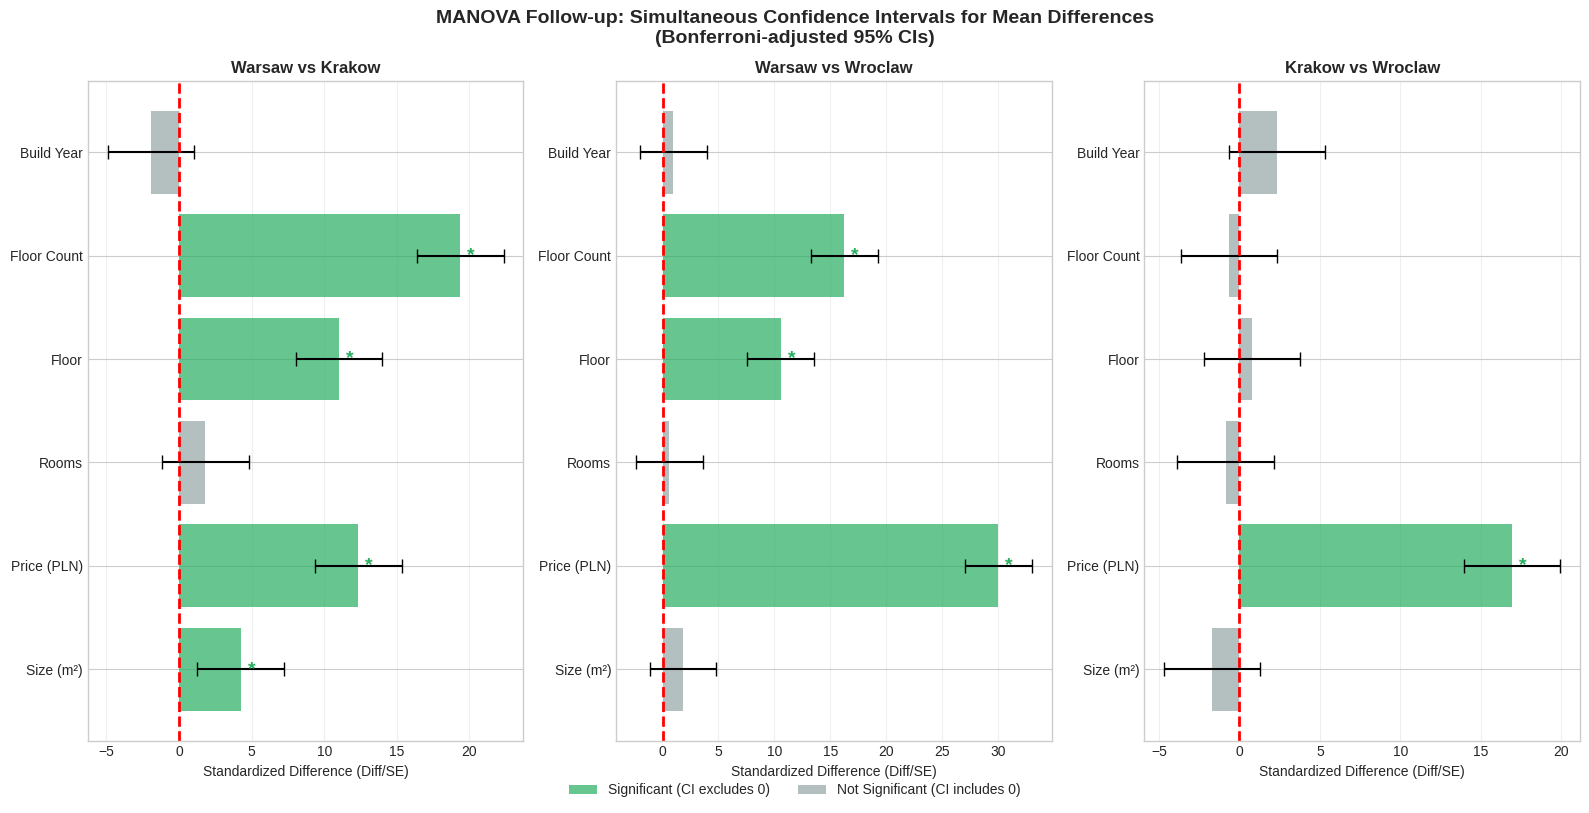

CONCLUSION

Based on the simultaneous Bonferroni-adjusted 95% confidence intervals:

VARIABLES CONTRIBUTING TO REJECTION OF H0:

  • squareMeters: Significant differences in 1/3 comparisons
    (Warsaw - Krakow)
  • price: Significant differences in 3/3 comparisons
    (Warsaw - Krakow, Warsaw - Wroclaw, Krakow - Wroclaw)
  • floor: Significant differences in 2/3 comparisons
    (Warsaw - Krakow, Warsaw - Wroclaw)
  • floorCount: Significant differences in 2/3 comparisons
    (Warsaw - Krakow, Warsaw - Wroclaw)

VARIABLES NOT CONTRIBUTING:
  • rooms: No significant pairwise differences
  • buildYear: No significant pairwise differences


In [11]:
cities = ['warszawa', 'krakow', 'wroclaw']
var_labels = ['Size (m²)', 'Price (PLN)', 'Rooms', 'Floor', 'Floor Count', 'Build Year']
df_cities = df_clean[df_clean['city'].isin(cities)].copy()

print(f"\nSample sizes by city:")
for city in cities:
    n = len(df_cities[df_cities['city'] == city])
    print(f"  {city.capitalize()}: n = {n}")

print(f"\nTotal sample for MANOVA: {len(df_cities)}")

df_manova = df_cities[key_vars + ['city']].dropna()
print(f"Complete cases for analysis: {len(df_manova)}")


def manova_wilks_lambda(data, group_col, dep_vars, alpha=0.05):
    """
    Perform one-way MANOVA using Wilks' Lambda test statistic.

    For g = 2: F = ((Σn_i - p - 1) / p) * ((1 - Λ) / Λ) ~ F(p, Σn_i - p - 1)
    For g > 2: Uses Rao's F approximation

    H0: μ₁ = μ₂ = ... = μ_g (all group mean vectors are equal)
    H1: At least one mean vector differs
    """
    groups = data[group_col].unique()
    g = len(groups)  # Number of groups
    p = len(dep_vars)  # Number of dependent variables
    N = len(data)  # Total sample size

    # Extract dependent variable matrix
    Y = data[dep_vars].values

    # Grand mean
    y_bar = np.mean(Y, axis=0)

    # Group means and sizes
    group_means = {}
    group_sizes = {}
    n_list = []
    for group in groups:
        group_data = data[data[group_col] == group][dep_vars].values
        group_means[group] = np.mean(group_data, axis=0)
        group_sizes[group] = len(group_data)
        n_list.append(len(group_data))

    # Between-groups SSCP matrix (B)
    B = np.zeros((p, p))
    for group in groups:
        diff = group_means[group] - y_bar
        B += group_sizes[group] * np.outer(diff, diff)

    # Within-groups SSCP matrix (W)
    W = np.zeros((p, p))
    for group in groups:
        group_data = data[data[group_col] == group][dep_vars].values
        for i in range(len(group_data)):
            diff = group_data[i] - group_means[group]
            W += np.outer(diff, diff)

    # Total SSCP matrix (T = B + W)
    T = B + W

    # Wilks' Lambda
    wilks_lambda = np.linalg.det(W) / np.linalg.det(T)

    # Degrees of freedom
    df_h = g - 1  # Hypothesis df (between groups)
    df_e = N - g  # Error df (within groups)

    # F-approximation for Wilks' Lambda
    if g == 2:
        # Special case for g = 2 (two groups)
        # F = ((Σn_i - p - 1) / p) * ((1 - Λ) / Λ)
        df1 = p
        df2 = N - p - 1
        F_stat = ((N - p - 1) / p) * ((1 - wilks_lambda) / wilks_lambda)
    else:
        # General case: Rao's F approximation for g > 2
        # Using the formula from the course materials

        # Calculate parameters for Rao's approximation
        # t = sqrt((p²(g-1)² - 4) / (p² + (g-1)² - 5)) if denominator > 0
        p_sq = p ** 2
        df_h_sq = df_h ** 2

        if (p_sq + df_h_sq - 5) > 0:
            t = np.sqrt((p_sq * df_h_sq - 4) / (p_sq + df_h_sq - 5))
        else:
            t = 1

        # df1 = p * (g - 1)
        df1 = p * df_h

        # df2 = w*t - (p*(g-1) - 2)/2
        # where w = df_e - (p - g + 2)/2 = N - g - (p - g + 2)/2
        w = df_e - (p - df_h) / 2
        df2 = w * t - (p * df_h - 2) / 2

        # F = ((1 - Λ^(1/t)) / Λ^(1/t)) * (df2 / df1)
        lambda_power = wilks_lambda ** (1 / t)
        F_stat = ((1 - lambda_power) / lambda_power) * (df2 / df1)

    # P-value
    p_value = 1 - f_dist.cdf(F_stat, df1, df2)

    # Critical value
    F_critical = f_dist.ppf(1 - alpha, df1, df2)

    return {
        'N': N,
        'g': g,
        'p': p,
        'groups': list(groups),
        'group_sizes': group_sizes,
        'group_means': group_means,
        'grand_mean': y_bar,
        'B': B,
        'W': W,
        'T': T,
        'wilks_lambda': wilks_lambda,
        'F_stat': F_stat,
        'df1': df1,
        'df2': df2,
        'p_value': p_value,
        'F_critical': F_critical,
        'alpha': alpha,
        'reject_null': p_value < alpha
    }


# Perform MANOVA
manova_results = manova_wilks_lambda(df_manova, 'city', key_vars)

# Print MANOVA Results
print("MANOVA RESULTS: COMPARING WARSAW, KRAKOW, AND WROCLAW")


print(f"\nHypotheses:")
print(f"  H₀: μ_Warsaw = μ_Krakow = μ_Wroclaw (all city mean vectors are equal)")
print(f"  H₁: At least one city's mean vector differs from the others")

print(f"\nSample Information:")
print(f"  Total N = {manova_results['N']}")
print(f"  Number of groups (g) = {manova_results['g']}")
print(f"  Number of dependent variables (p) = {manova_results['p']}")
for city in cities:
    print(f"    {city.capitalize()}: n = {manova_results['group_sizes'][city]}")

print(f"\nDependent Variables (Apartment Properties):")
for var in key_vars:
    print(f"  - {var}")

print(f"\nGroup Mean Vectors:")
print("-" * 75)
print(f"{'Variable':<20} {'Warsaw':>15} {'Krakow':>15} {'Wroclaw':>15}")
print("-" * 75)
for i, var in enumerate(key_vars):
    print(f"{var:<20} {manova_results['group_means']['warszawa'][i]:>15.2f} "
          f"{manova_results['group_means']['krakow'][i]:>15.2f} "
          f"{manova_results['group_means']['wroclaw'][i]:>15.2f}")
print("-" * 75)

print("WILKS' LAMBDA TEST")

print(f"\nTest Statistic:")
print(f"  Wilks' Lambda (Λ) = {manova_results['wilks_lambda']:.6f}")

print(f"\nF-Approximation:")
print(f"  F-statistic = {manova_results['F_stat']:.4f}")
print(f"  Degrees of freedom: df₁ = {manova_results['df1']:.0f}, df₂ = {manova_results['df2']:.1f}")

print(f"\nCritical Value (α = {manova_results['alpha']}):")
print(f"  F-critical = {manova_results['F_critical']:.4f}")

print(f"\nP-value: {manova_results['p_value']:.6e}")

print(f"\nDecision at α = {manova_results['alpha']}:")
if manova_results['reject_null']:
    print(f"  *** REJECT H₀ ***")
    print(f"  Since F = {manova_results['F_stat']:.4f} > F-critical = {manova_results['F_critical']:.4f}")
    print(f"  and p-value < α, we reject the null hypothesis.")
else:
    print(f"  FAIL TO REJECT H₀")

# Post-Hoc Analysis: Pairwise Hotelling's T^2 Tests
print("POST-HOC ANALYSIS: PAIRWISE HOTELLING'S T² TESTS")
print("\nBonferroni-adjusted α = 0.05/3 = 0.0167 for 3 pairwise comparisons\n")

city_pairs = [('warszawa', 'krakow'), ('warszawa', 'wroclaw'), ('krakow', 'wroclaw')]
bonferroni_alpha = 0.05 / len(city_pairs)

pairwise_results = []
for city1, city2 in city_pairs:
    group1 = df_manova[df_manova['city'] == city1][key_vars]
    group2 = df_manova[df_manova['city'] == city2][key_vars]

    results = hotellings_t2_test(group1, group2, alpha=bonferroni_alpha)

    print(f"\n{city1.capitalize()} vs {city2.capitalize()}:")
    print(f"  n₁ = {results['n1']}, n₂ = {results['n2']}")
    print(f"  T² = {results['T2']:.2f}")
    print(f"  F({results['df1']}, {results['df2']}) = {results['F_stat']:.2f}")
    print(f"  p-value = {results['p_value']:.2e}")
    print(f"  Decision (α = {bonferroni_alpha:.4f}): ", end="")
    if results['p_value'] < bonferroni_alpha:
        print("*** SIGNIFICANT DIFFERENCE ***")
    else:
        print("No significant difference")

    pairwise_results.append({
        'Comparison': f"{city1.capitalize()} vs {city2.capitalize()}",
        'n₁': results['n1'],
        'n₂': results['n2'],
        'T²': round(results['T2'], 2),
        'F': round(results['F_stat'], 2),
        'p-value': f"{results['p_value']:.2e}",
        'Significant': 'Yes' if results['p_value'] < bonferroni_alpha else 'No'
    })

print("\n\nPairwise Comparison Summary Table:")
pairwise_df = pd.DataFrame(pairwise_results)
print(pairwise_df.to_string(index=False))


cities = ['warszawa', 'krakow', 'wroclaw']
city_labels = {'warszawa': 'Warsaw', 'krakow': 'Krakow', 'wroclaw': 'Wroclaw'}

df_cities = df_clean[df_clean['city'].isin(cities)].copy()
df_manova = df_cities[key_vars + ['city']].dropna()

print(f"\nDataset: {len(df_manova)} observations")
print(f"Groups: {', '.join([city_labels[c] for c in cities])}")
print(f"Variables: {', '.join(key_vars)}")

# Calculate MANOVA components
g = len(cities)  # Number of groups
p = len(key_vars)  # Number of variables
N = len(df_manova)  # Total sample size

# Group statistics
group_data = {}
group_means = {}
group_sizes = {}
group_covs = {}

for city in cities:
    city_data = df_manova[df_manova['city'] == city][key_vars]
    group_data[city] = city_data.values
    group_means[city] = city_data.mean().values
    group_sizes[city] = len(city_data)
    group_covs[city] = city_data.cov().values

# Grand mean
grand_mean = df_manova[key_vars].mean().values

# Within-groups SSCP matrix (W)
W = np.zeros((p, p))
for city in cities:
    n_i = group_sizes[city]
    W += (n_i - 1) * group_covs[city]

# Pooled covariance matrix
df_error = N - g
S_pooled = W / df_error

print(f"\nDegrees of freedom:")
print(f"  Between groups (g-1): {g-1}")
print(f"  Within groups (N-g): {df_error}")

# Simultaneous CIs - Bonferroni Method
print("SIMULTANEOUS CONFIDENCE INTERVALS (Bonferroni Method)")

alpha = 0.05
num_comparisons = g * (g - 1) / 2 * p  # Number of all pairwise comparisons for all variables
bonferroni_alpha = alpha / num_comparisons

print(f"\nOverall α = {alpha}")
print(f"Number of comparisons: {int(num_comparisons)} ({int(g*(g-1)/2)} city pairs × {p} variables)")
print(f"Bonferroni-adjusted α per comparison: {bonferroni_alpha:.6f}")

# t critical value for Bonferroni
t_crit = t_dist.ppf(1 - bonferroni_alpha/2, df_error)
print(f"Critical t-value (df={df_error}): {t_crit:.4f}")

# Calculate CIs for all pairwise comparisons
city_pairs = [('warszawa', 'krakow'), ('warszawa', 'wroclaw'), ('krakow', 'wroclaw')]

ci_results = []

print("PAIRWISE CONFIDENCE INTERVALS FOR MEAN DIFFERENCES")

for city1, city2 in city_pairs:
    print(f"\n{city_labels[city1]} vs {city_labels[city2]}:")
    print("-" * 70)
    print(f"{'Variable':<15} {'Diff (μ1-μ2)':>12} {'SE':>10} {'95% CI':>25} {'Significant':>12}")
    print("-" * 70)

    n1 = group_sizes[city1]
    n2 = group_sizes[city2]

    for i, var in enumerate(key_vars):
        # Mean difference
        diff = group_means[city1][i] - group_means[city2][i]

        # Standard error of the difference
        # SE = sqrt(S_pooled[i,i] * (1/n1 + 1/n2))
        se = np.sqrt(S_pooled[i, i] * (1/n1 + 1/n2))

        # Confidence interval
        margin = t_crit * se
        ci_lower = diff - margin
        ci_upper = diff + margin

        # Check if CI contains 0 (if not, significant)
        significant = not (ci_lower <= 0 <= ci_upper)
        sig_marker = "***" if significant else ""

        ci_results.append({
            'Comparison': f"{city_labels[city1]} - {city_labels[city2]}",
            'Variable': var,
            'Difference': diff,
            'SE': se,
            'CI_Lower': ci_lower,
            'CI_Upper': ci_upper,
            'Significant': significant
        })

        # Format output
        if var == 'price':
            print(f"{var:<15} {diff:>12,.0f} {se:>10,.0f} [{ci_lower:>10,.0f}, {ci_upper:>10,.0f}] {sig_marker:>12}")
        elif var == 'buildYear':
            print(f"{var:<15} {diff:>12.2f} {se:>10.2f} [{ci_lower:>10.2f}, {ci_upper:>10.2f}] {sig_marker:>12}")
        else:
            print(f"{var:<15} {diff:>12.2f} {se:>10.4f} [{ci_lower:>10.4f}, {ci_upper:>10.4f}] {sig_marker:>12}")

ci_df = pd.DataFrame(ci_results)

# Which variables contribute to H0 rejection?
# SUMMARY: WHICH VARIABLES CONTRIBUTE TO H0 REJECTION?
print("SUMMARY: VARIABLES CONTRIBUTING TO REJECTION OF H0")

# Create summary by variable
var_summary = []
for var in key_vars:
    var_data = ci_df[ci_df['Variable'] == var]
    sig_count = var_data['Significant'].sum()
    total_pairs = len(city_pairs)

    sig_pairs = var_data[var_data['Significant']]['Comparison'].tolist()

    var_summary.append({
        'Variable': var,
        'Significant_Pairs': sig_count,
        'Total_Pairs': total_pairs,
        'Contributes_to_Rejection': 'Yes' if sig_count > 0 else 'No',
        'Which_Pairs': ', '.join(sig_pairs) if sig_pairs else 'None'
    })

var_summary_df = pd.DataFrame(var_summary)
print(var_summary_df.to_string(index=False))

# Detailed interpretation
print("DETAILED INTERPRETATION")


contributing_vars = [v['Variable'] for v in var_summary if v['Contributes_to_Rejection'] == 'Yes']
non_contributing_vars = [v['Variable'] for v in var_summary if v['Contributes_to_Rejection'] == 'No']

print(f"\nVariables that CONTRIBUTE to rejecting H0 ({len(contributing_vars)}):")
for var in contributing_vars:
    var_data = ci_df[ci_df['Variable'] == var]
    sig_data = var_data[var_data['Significant']]
    print(f"\n  • {var}:")
    for _, row in sig_data.iterrows():
        if var == 'price':
            print(f"    - {row['Comparison']}: diff = {row['Difference']:,.0f} PLN")
            print(f"      CI: [{row['CI_Lower']:,.0f}, {row['CI_Upper']:,.0f}]")
        else:
            print(f"    - {row['Comparison']}: diff = {row['Difference']:.2f}")
            print(f"      CI: [{row['CI_Lower']:.4f}, {row['CI_Upper']:.4f}]")

if non_contributing_vars:
    print(f"\nVariables that DO NOT contribute to rejecting H0 ({len(non_contributing_vars)}):")
    for var in non_contributing_vars:
        print(f"  • {var} (all CIs contain 0)")

# Visualization: Confidence Intervals

# Plot 1: CI plot for each city pair
fig, axes = plt.subplots(1, 3, figsize=(16, 8))

for idx, (city1, city2) in enumerate(city_pairs):
    ax = axes[idx]

    pair_data = ci_df[ci_df['Comparison'] == f"{city_labels[city1]} - {city_labels[city2]}"]

    y_pos = np.arange(len(key_vars))

    # Normalize differences for visualization (z-score within each plot)
    diffs = pair_data['Difference'].values
    ci_lowers = pair_data['CI_Lower'].values
    ci_uppers = pair_data['CI_Upper'].values
    significant = pair_data['Significant'].values

    # Create error bars
    errors = np.array([diffs - ci_lowers, ci_uppers - diffs])

    # Color based on significance
    colors = ['#27ae60' if sig else '#95a5a6' for sig in significant]

    # Normalize for display (divide by SE to get comparable scale)
    ses = pair_data['SE'].values
    diffs_normalized = diffs / ses
    errors_normalized = errors / ses

    ax.barh(y_pos, diffs_normalized, xerr=errors_normalized,
            color=colors, alpha=0.7, capsize=5, ecolor='black')

    ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='No difference')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(var_labels)
    ax.set_xlabel('Standardized Difference (Diff/SE)')
    ax.set_title(f'{city_labels[city1]} vs {city_labels[city2]}', fontsize=12, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)

    # Add significance markers
    for i, (diff, sig) in enumerate(zip(diffs_normalized, significant)):
        if sig:
            ax.annotate('*', xy=(diff, i), xytext=(5, 0),
                       textcoords='offset points', fontsize=14, fontweight='bold',
                       color='#27ae60', va='center')

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#27ae60', alpha=0.7, label='Significant (CI excludes 0)'),
                   Patch(facecolor='#95a5a6', alpha=0.7, label='Not Significant (CI includes 0)')]
fig.legend(handles=legend_elements, loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.02))

plt.suptitle('MANOVA Follow-up: Simultaneous Confidence Intervals for Mean Differences\n(Bonferroni-adjusted 95% CIs)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
plt.close()

# Final Conclusion
print("CONCLUSION")

print(f"""
Based on the simultaneous Bonferroni-adjusted 95% confidence intervals:

VARIABLES CONTRIBUTING TO REJECTION OF H0:
""")

for var in contributing_vars:
    var_data = ci_df[ci_df['Variable'] == var]
    sig_pairs = var_data[var_data['Significant']]['Comparison'].tolist()
    print(f"  • {var}: Significant differences in {len(sig_pairs)}/3 comparisons")
    print(f"    ({', '.join(sig_pairs)})")

if non_contributing_vars:
    print(f"\nVARIABLES NOT CONTRIBUTING:")
    for var in non_contributing_vars:
        print(f"  • {var}: No significant pairwise differences")

## PCA and PCR


[Step 1] Missing values imputed with median

--- Variance Explained by Each Component ---
PC     Eigenvalue   Variance %   Cumulative %
---------------------------------------------
PC1    4.4468       37.06        37.06       
PC2    1.8761       15.63        52.69       
PC3    1.5872       13.23        65.91       
PC4    1.1160       9.30         75.21       
PC5    0.7340       6.12         81.33       
PC6    0.5149       4.29         85.62       
PC7    0.3994       3.33         88.95       
PC8    0.3518       2.93         91.88       
PC9    0.3195       2.66         94.54       
PC10   0.2727       2.27         96.82       
PC11   0.2159       1.80         98.61       
PC12   0.1662       1.39         100.00      

--- Component Selection Criteria ---
  Kaiser criterion (eigenvalue > 1):  4 components
  80% variance threshold:             5 components
  90% variance threshold:             8 components

 SELECTED: 4 components (Kaiser criterion)
  Total variance explained: 75

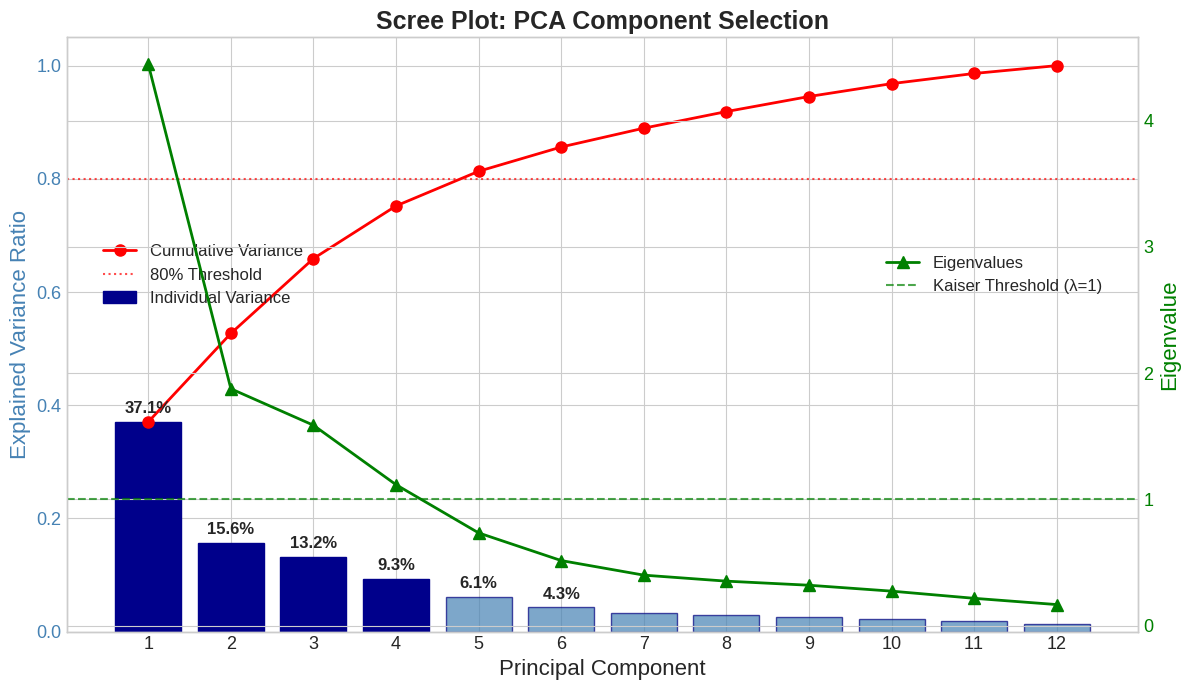

PCA LOADINGS (Component Interpretation)

Loadings Matrix
                            PC1    PC2    PC3    PC4
rooms                    -0.052  0.627  0.320  0.029
floor                     0.092 -0.245  0.618 -0.220
floorCount                0.120 -0.300  0.593 -0.151
buildYear                -0.186 -0.143  0.242  0.479
log_squareMeters         -0.052  0.643  0.284  0.037
log_centreDistance       -0.244 -0.108  0.145  0.586
log_poiCount              0.421  0.075 -0.043 -0.086
log_schoolDistance       -0.394 -0.017  0.028 -0.106
log_clinicDistance       -0.334 -0.046 -0.020  0.194
log_pharmacyDistance     -0.400 -0.027  0.005 -0.245
log_restaurantDistance   -0.391 -0.042 -0.001 -0.210
log_kindergartenDistance -0.348  0.026 -0.020 -0.439

Component Interpretations

PC1 (37.1% variance):
  + log_poiCount: 0.421
  - log_pharmacyDistance: -0.400
  - log_schoolDistance: -0.394

PC2 (15.6% variance):
  + log_squareMeters: 0.643
  + rooms: 0.627
  - floorCount: -0.300

PC3 (13.2% variance):
  

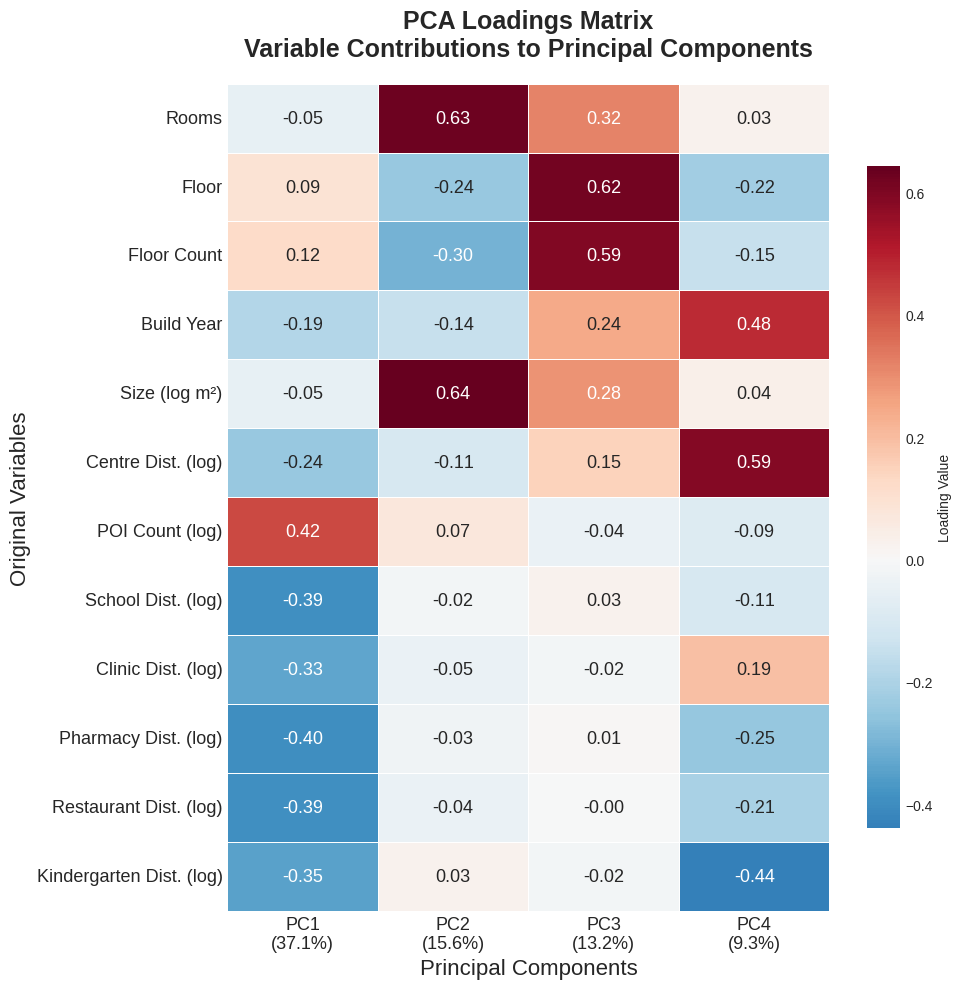


PCR Model Summary
                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.375
Model:                            OLS   Adj. R-squared:                  0.375
Method:                 Least Squares   F-statistic:                     3229.
Date:                Sun, 18 Jan 2026   Prob (F-statistic):               0.00
Time:                        17:56:46   Log-Likelihood:                -9342.0
No. Observations:               21501   AIC:                         1.869e+04
Df Residuals:                   21496   BIC:                         1.873e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         13.5068      0.003 

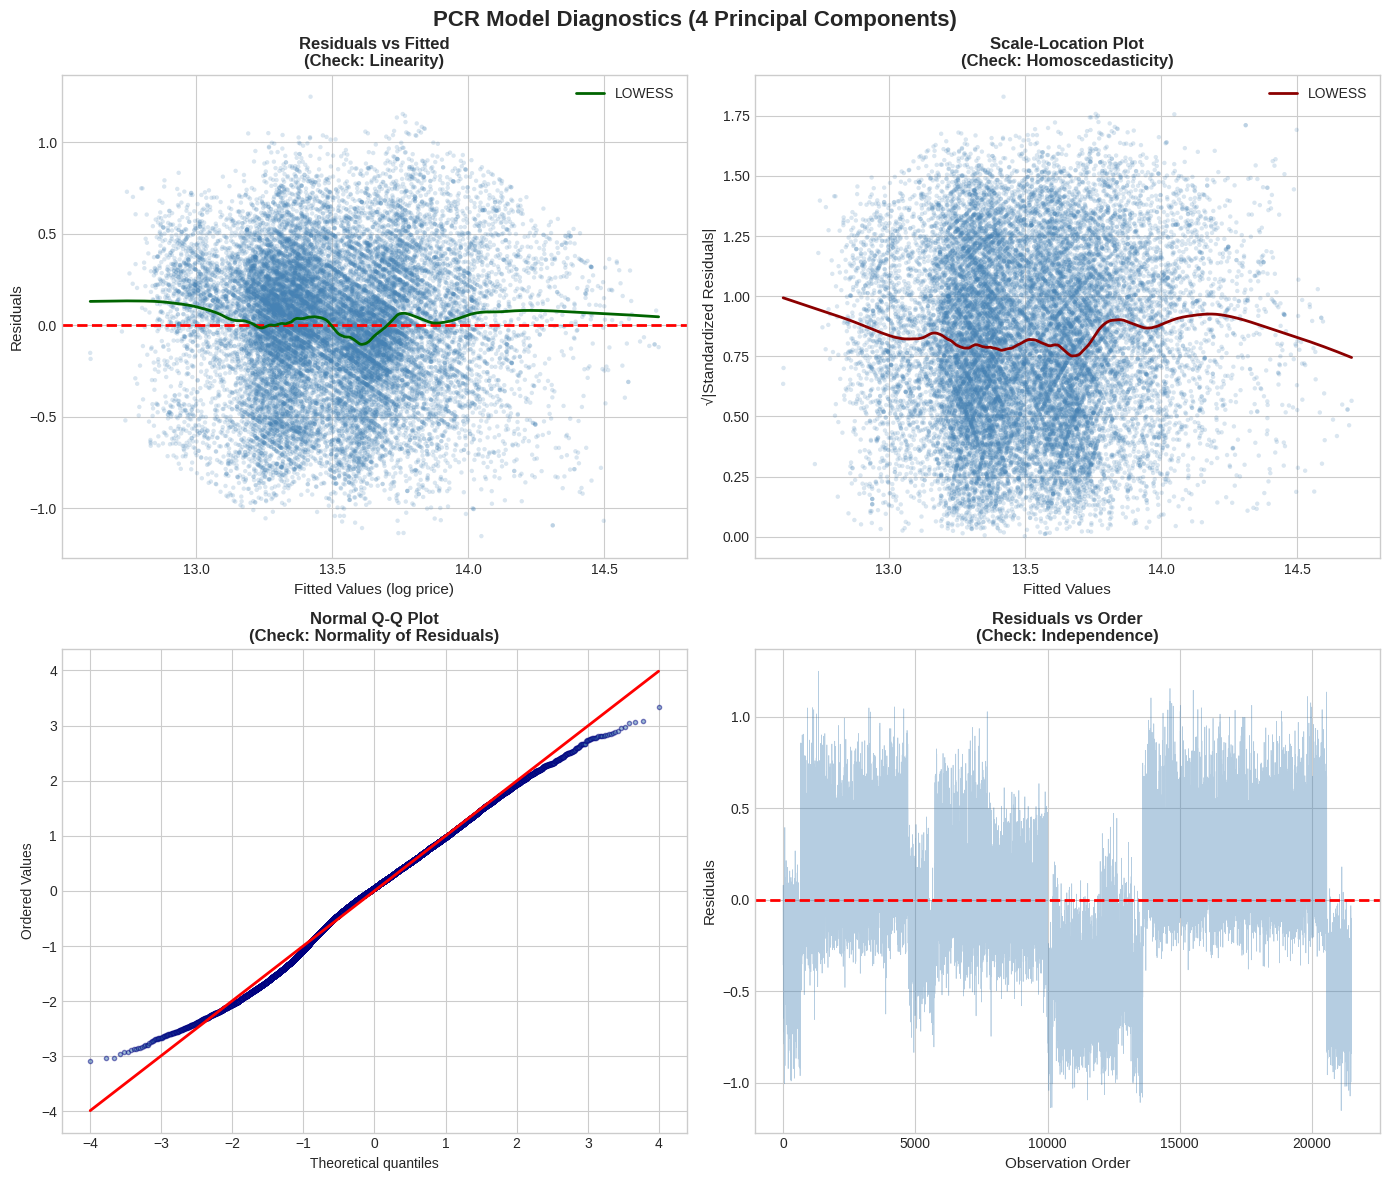

In [12]:
# Define numeric columns for PCA
cols_numeric = [
    'squareMeters', 'rooms', 'floor', 'floorCount', 'buildYear',
    'centreDistance', 'poiCount', 'schoolDistance', 'clinicDistance',
    'pharmacyDistance', 'restaurantDistance', 'kindergartenDistance'
]

# Preprocessing pipeline

# A. Extract numeric features
X_num = df_clean[cols_numeric].copy()

# B. Impute missing values with median
imputer = SimpleImputer(strategy='median')
X_num_imputed = pd.DataFrame(
    imputer.fit_transform(X_num),
    columns=cols_numeric
)
print(f"\n[Step 1] Missing values imputed with median")

# C. Log transform skewed features (distances and counts)
log_transformed = []
for col in list(X_num_imputed.columns):
    if 'Distance' in col or col in ['squareMeters', 'poiCount']:
        X_num_imputed['log_' + col] = np.log(X_num_imputed[col] + 1)
        X_num_imputed = X_num_imputed.drop(columns=[col])
        log_transformed.append(col)

# D. Standardization (mean=0, std=1)
feature_names = list(X_num_imputed.columns)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_num_imputed)

# E. Target variable (log price)
y = np.log(df_clean['price'])

# PCA Analysis

# Fit full PCA
pca_full = PCA()
pca_full.fit(X_scaled)

# Extract results
explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)
eigenvalues = pca_full.explained_variance_

# Display variance explained
print("\n--- Variance Explained by Each Component ---")
print(f"{'PC':<6} {'Eigenvalue':<12} {'Variance %':<12} {'Cumulative %':<12}")
print("-" * 45)
for i in range(len(explained_variance)):
    print(f"PC{i+1:<4} {eigenvalues[i]:<12.4f} {explained_variance[i]*100:<12.2f} {cumulative_variance[i]*100:<12.2f}")

# Component selection criteria
print("\n--- Component Selection Criteria ---")
kaiser_n = sum(eigenvalues > 1)
var_80_n = np.argmax(cumulative_variance >= 0.80) + 1
var_90_n = np.argmax(cumulative_variance >= 0.90) + 1

print(f"  Kaiser criterion (eigenvalue > 1):  {kaiser_n} components")
print(f"  80% variance threshold:             {var_80_n} components")
print(f"  90% variance threshold:             {var_90_n} components")

# Select number of components (Kaiser criterion)
n_components = kaiser_n
print(f"\n SELECTED: {n_components} components (Kaiser criterion)")
print(f"  Total variance explained: {cumulative_variance[n_components-1]:.2%}")

# Scree plot
fig, ax1 = plt.subplots(figsize=(12, 7))

n_pc = len(explained_variance)
x = range(1, n_pc + 1)

# Bar plot for individual variance
bars = ax1.bar(x, explained_variance, alpha=0.7, color='steelblue',
               edgecolor='navy', label='Individual Variance')

# Highlight selected components
for i in range(n_components):
    bars[i].set_color('darkblue')
    bars[i].set_alpha(1.0)

ax1.set_xlabel('Principal Component', fontsize=16)
ax1.set_ylabel('Explained Variance Ratio', color='steelblue', fontsize=16)
ax1.tick_params(axis='y', labelcolor='steelblue', labelsize=13)
ax1.tick_params(axis='x', labelsize=13)
ax1.set_xticks(x)

# Cumulative variance line
ax1.plot(x, cumulative_variance, 'ro-', linewidth=2, markersize=8,
         label='Cumulative Variance')
ax1.axhline(0.80, color='red', linestyle=':', alpha=0.7, label='80% Threshold')

# Eigenvalue line (secondary axis)
ax2 = ax1.twinx()
ax2.plot(x, eigenvalues, 'g^-', linewidth=2, markersize=8, label='Eigenvalues')
ax2.axhline(1, color='green', linestyle='--', alpha=0.7, label='Kaiser Threshold (λ=1)')
ax2.set_ylabel('Eigenvalue', color='green', fontsize=16)
ax2.tick_params(axis='y', labelcolor='green', labelsize=13)

# Add percentage labels
for i, (v, cv) in enumerate(zip(explained_variance[:6], cumulative_variance[:6])):
    ax1.text(i + 1, v + 0.01, f'{v:.1%}', ha='center', va='bottom',
             fontsize=12, fontweight='bold')


# Legends
ax1.legend(loc='center left', bbox_to_anchor=(0.02, 0.6), fontsize=12)
ax2.legend(loc='center right', bbox_to_anchor=(0.98, 0.6), fontsize=12)

plt.title('Scree Plot: PCA Component Selection', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()
plt.close()

# PCA Loadings Analysis
print("PCA LOADINGS (Component Interpretation)")


# Fit PCA with selected components
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

# Create loadings DataFrame
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(n_components)],
    index=feature_names
)

print("\nLoadings Matrix")
print(loadings.round(3).to_string())

# Component interpretations
print("\nComponent Interpretations")
interpretations = {}
for i in range(n_components):
    pc = f'PC{i+1}'
    var_pct = pca.explained_variance_ratio_[i] * 100

    # Get top contributors (by absolute value)
    sorted_loadings = loadings[pc].abs().sort_values(ascending=False)
    top_features = sorted_loadings.head(3).index.tolist()

    print(f"\n{pc} ({var_pct:.1f}% variance):")
    for feat in top_features:
        val = loadings.loc[feat, pc]
        direction = "+" if val > 0 else "-"
        print(f"  {direction} {feat}: {val:.3f}")

# Loadings heatmap

# Create readable labels
readable_labels = {
    'rooms': 'Rooms',
    'floor': 'Floor',
    'floorCount': 'Floor Count',
    'buildYear': 'Build Year',
    'log_squareMeters': 'Size (log m²)',
    'log_centreDistance': 'Centre Dist. (log)',
    'log_poiCount': 'POI Count (log)',
    'log_schoolDistance': 'School Dist. (log)',
    'log_clinicDistance': 'Clinic Dist. (log)',
    'log_pharmacyDistance': 'Pharmacy Dist. (log)',
    'log_restaurantDistance': 'Restaurant Dist. (log)',
    'log_kindergartenDistance': 'Kindergarten Dist. (log)'
}

loadings_display = loadings.copy()
loadings_display.index = [readable_labels.get(f, f) for f in loadings_display.index]
loadings_display.columns = [f'PC{i+1}\n({pca.explained_variance_ratio_[i]:.1%})'
                            for i in range(n_components)]

plt.figure(figsize=(10, 10))
sns.heatmap(loadings_display, annot=True, cmap='RdBu_r', center=0,
            fmt='.2f', linewidths=0.5,
            cbar_kws={'label': 'Loading Value', 'shrink': 0.8},
            annot_kws={'size': 13})

plt.title('PCA Loadings Matrix\nVariable Contributions to Principal Components',
          fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Principal Components', fontsize=16)
plt.ylabel('Original Variables', fontsize=16)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.tight_layout()
plt.show()
plt.close()

# PCR

# Create PC DataFrame
X_pca_df = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(n_components)])

# Fit OLS model
X_ols = sm.add_constant(X_pca_df)
model_pcr = sm.OLS(y, X_ols).fit()

print("\nPCR Model Summary")
print(model_pcr.summary())

# Regression Diagnostics
print("REGRESSION DIAGNOSTICS")

# Extract residuals and fitted values
residuals = model_pcr.resid
fitted = model_pcr.fittedvalues
influence = model_pcr.get_influence()
resid_std = influence.resid_studentized_internal

# Create diagnostic plots
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
plt.suptitle(f'PCR Model Diagnostics ({n_components} Principal Components)',
             fontsize=16, fontweight='bold')

# Plot 1: Residuals vs Fitted (Linearity)
ax = axes[0, 0]
ax.scatter(fitted, residuals, alpha=0.2, s=10, c='steelblue', edgecolors='none')
ax.axhline(0, color='red', linestyle='--', linewidth=2)
lowess = sm.nonparametric.lowess(residuals, fitted, frac=0.1)
ax.plot(lowess[:, 0], lowess[:, 1], color='darkgreen', linewidth=2, label='LOWESS')
ax.set_xlabel('Fitted Values (log price)', fontsize=11)
ax.set_ylabel('Residuals', fontsize=11)
ax.set_title('Residuals vs Fitted\n(Check: Linearity)', fontsize=12, fontweight='bold')
ax.legend()

# Plot 2: Scale-Location (Homoscedasticity)
ax = axes[0, 1]
sqrt_resid_std = np.sqrt(np.abs(resid_std))
ax.scatter(fitted, sqrt_resid_std, alpha=0.2, s=10, c='steelblue', edgecolors='none')
lowess_sl = sm.nonparametric.lowess(sqrt_resid_std, fitted, frac=0.1)
ax.plot(lowess_sl[:, 0], lowess_sl[:, 1], color='darkred', linewidth=2, label='LOWESS')
ax.set_xlabel('Fitted Values', fontsize=11)
ax.set_ylabel('√|Standardized Residuals|', fontsize=11)
ax.set_title('Scale-Location Plot\n(Check: Homoscedasticity)', fontsize=12, fontweight='bold')
ax.legend()

# Plot 3: Q-Q Plot (Normality)
ax = axes[1, 0]
probplot(resid_std, dist="norm", plot=ax)
ax.get_lines()[0].set_markerfacecolor('steelblue')
ax.get_lines()[0].set_markeredgecolor('navy')
ax.get_lines()[0].set_markersize(3)
ax.get_lines()[0].set_alpha(0.5)
ax.get_lines()[1].set_color('red')
ax.get_lines()[1].set_linewidth(2)
ax.set_title('Normal Q-Q Plot\n(Check: Normality of Residuals)', fontsize=12, fontweight='bold')

# Plot 4: Residuals vs Order (Independence)
ax = axes[1, 1]
ax.plot(range(len(residuals)), residuals, alpha=0.4, linewidth=0.5, c='steelblue')
ax.axhline(0, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Observation Order', fontsize=11)
ax.set_ylabel('Residuals', fontsize=11)
ax.set_title('Residuals vs Order\n(Check: Independence)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()
plt.close()

### Hybrid Model


Binary Features
Converted 5 binary features to 0/1

Categorical Features
One-hot encoded to 23 dummy variables
HYBRID PCR MODEL (PCA + Binary + Categorical)

--- Feature Summary ---
  PCA Components:      4
  Binary Features:     5
  Categorical Dummies: 23
  TOTAL Features:      32

--- Hybrid PCR Model Summary ---
                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.831
Model:                            OLS   Adj. R-squared:                  0.831
Method:                 Least Squares   F-statistic:                     3304.
Date:                Sun, 18 Jan 2026   Prob (F-statistic):               0.00
Time:                        17:56:59   Log-Likelihood:                 4725.6
No. Observations:               21501   AIC:                            -9385.
Df Residuals:                   21468   BIC:                            -9122.
Df Model:                          32            

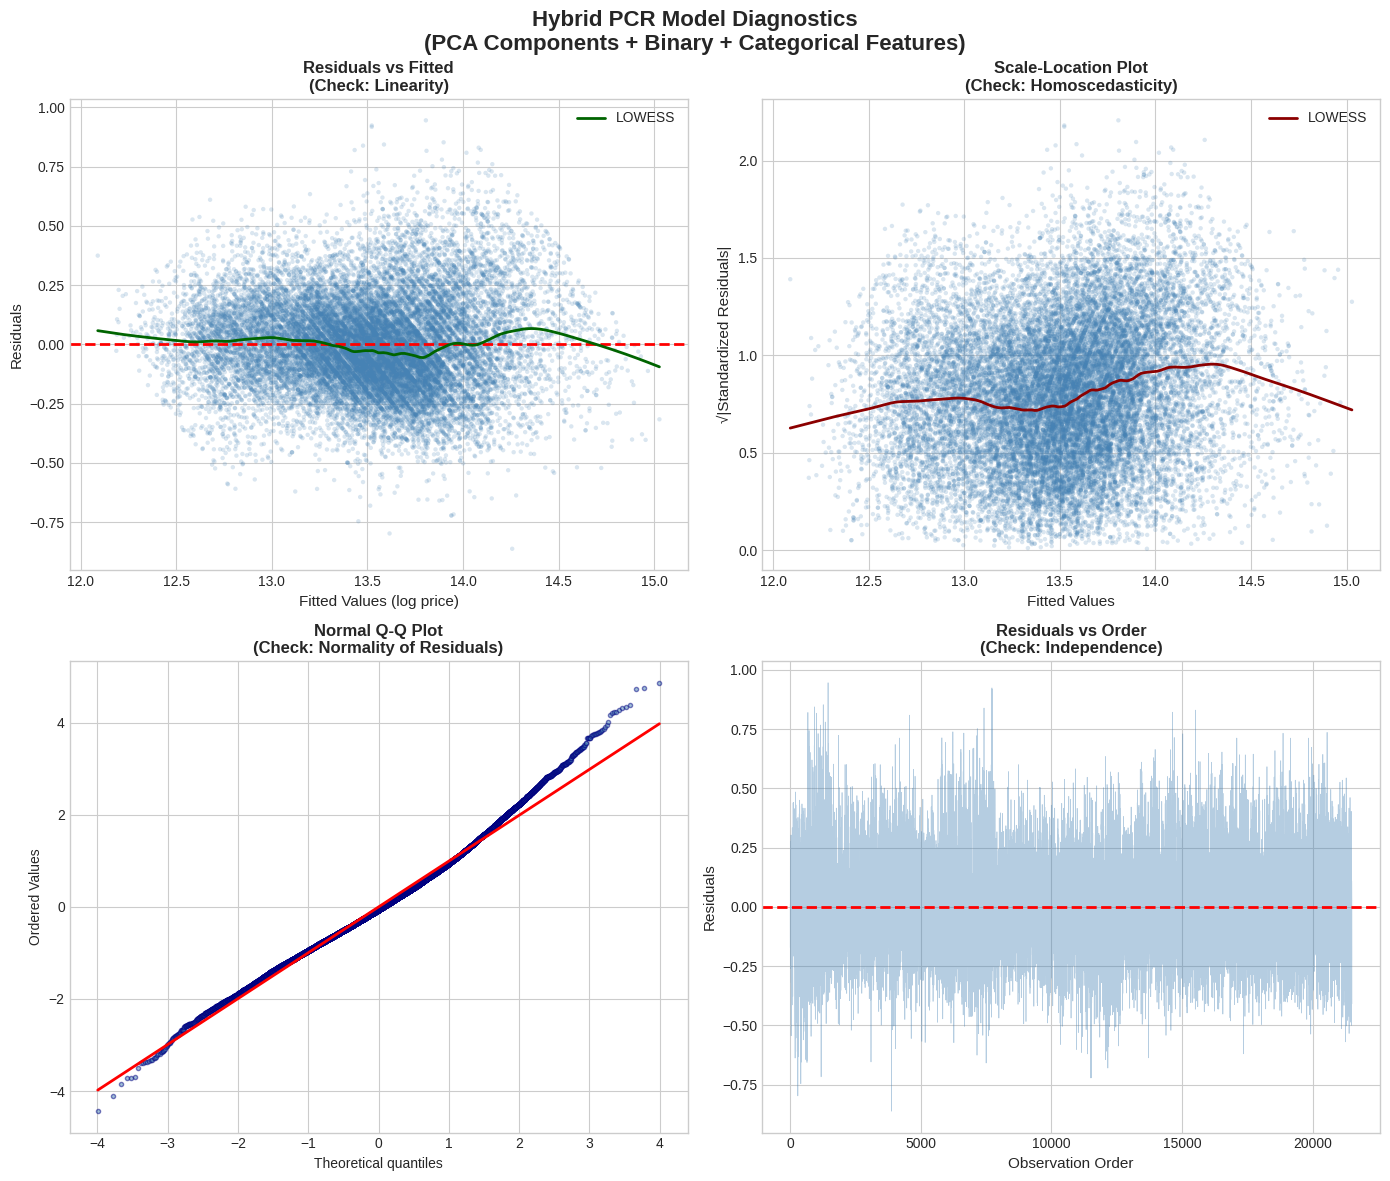


Formal Diagnostic Tests

[Normality] Jarque-Bera Test:
  Statistic: 246.52
  p-value:   0.0000
  Result:    Residuals are NON-NORMAL

[Homoscedasticity] Breusch-Pagan Test:
  Statistic: 1815.92
  p-value:   0.0000
  Result:    HETEROSCEDASTICITY detected

[Independence] Durbin-Watson Test:
  Statistic: 1.8736
  Result:    No strong autocorrelation


In [13]:
# Binary columns (to be included directly, not in PCA)
cols_binary = [
    'hasElevator', 'hasParkingSpace', 'hasSecurity', 'hasStorageRoom', 'hasBalcony'
]

# Categorical columns (to be one-hot encoded)
cols_categorical = [
    'city', 'type', 'buildingMaterial', 'condition', 'ownership'
]

# Check availability
cols_numeric = [c for c in cols_numeric if c in df_clean.columns]
cols_binary = [c for c in cols_binary if c in df_clean.columns]
cols_categorical = [c for c in cols_categorical if c in df_clean.columns]

# Binary Features Processing
print("\nBinary Features")
X_bin = df_clean[cols_binary].copy()
for col in cols_binary:
    X_bin[col] = X_bin[col].astype(str).str.lower().apply(lambda x: 1 if x == 'yes' else 0)
X_bin = X_bin.reset_index(drop=True)
print(f"Converted {len(cols_binary)} binary features to 0/1")

# Categorical Features Processing
print("\nCategorical Features")
X_cat = df_clean[cols_categorical].copy()
imputer_cat = SimpleImputer(strategy='constant', fill_value='unknown')
X_cat_imputed = pd.DataFrame(imputer_cat.fit_transform(X_cat), columns=cols_categorical)
X_cat_dummies = pd.get_dummies(X_cat_imputed, columns=cols_categorical, drop_first=True)
X_cat_dummies = X_cat_dummies.reset_index(drop=True)
print(f"One-hot encoded to {X_cat_dummies.shape[1]} dummy variables")

# HYBRID PCR MODEL (PCA + Binary + Categorical)
print("HYBRID PCR MODEL (PCA + Binary + Categorical)")

# Concatenate all features
X_final = pd.concat([X_pca_df, X_bin, X_cat_dummies], axis=1)

# Check for NaNs
if X_final.isnull().sum().sum() > 0:
    print("WARNING: NaNs found! Filling with 0.")
    X_final = X_final.fillna(0)

print(f"\n--- Feature Summary ---")
print(f"  PCA Components:      {X_pca_df.shape[1]}")
print(f"  Binary Features:     {X_bin.shape[1]}")
print(f"  Categorical Dummies: {X_cat_dummies.shape[1]}")
print(f"  TOTAL Features:      {X_final.shape[1]}")

# Fit OLS model
X_ols = sm.add_constant(X_final).astype(float)
model = sm.OLS(y, X_ols).fit()

print("\n--- Hybrid PCR Model Summary ---")
print(model.summary())

# REGRESSION DIAGNOSTICS
print("REGRESSION DIAGNOSTICS")

# Extract residuals and fitted values
residuals = model.resid
fitted = model.fittedvalues
influence = model.get_influence()
resid_std = influence.resid_studentized_internal

# Create diagnostic plots
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
plt.suptitle('Hybrid PCR Model Diagnostics\n(PCA Components + Binary + Categorical Features)',
             fontsize=16, fontweight='bold')

# Plot 1: Residuals vs Fitted (Linearity)
ax = axes[0, 0]
ax.scatter(fitted, residuals, alpha=0.2, s=10, c='steelblue', edgecolors='none')
ax.axhline(0, color='red', linestyle='--', linewidth=2)
lowess = sm.nonparametric.lowess(residuals, fitted, frac=0.1)
ax.plot(lowess[:, 0], lowess[:, 1], color='darkgreen', linewidth=2, label='LOWESS')
ax.set_xlabel('Fitted Values (log price)', fontsize=11)
ax.set_ylabel('Residuals', fontsize=11)
ax.set_title('Residuals vs Fitted\n(Check: Linearity)', fontsize=12, fontweight='bold')
ax.legend()

# Plot 2: Scale-Location (Homoscedasticity)
ax = axes[0, 1]
sqrt_resid_std = np.sqrt(np.abs(resid_std))
ax.scatter(fitted, sqrt_resid_std, alpha=0.2, s=10, c='steelblue', edgecolors='none')
lowess_sl = sm.nonparametric.lowess(sqrt_resid_std, fitted, frac=0.1)
ax.plot(lowess_sl[:, 0], lowess_sl[:, 1], color='darkred', linewidth=2, label='LOWESS')
ax.set_xlabel('Fitted Values', fontsize=11)
ax.set_ylabel('√|Standardized Residuals|', fontsize=11)
ax.set_title('Scale-Location Plot\n(Check: Homoscedasticity)', fontsize=12, fontweight='bold')
ax.legend()

# Plot 3: Q-Q Plot (Normality)
ax = axes[1, 0]
probplot(resid_std, dist="norm", plot=ax)
ax.get_lines()[0].set_markerfacecolor('steelblue')
ax.get_lines()[0].set_markeredgecolor('navy')
ax.get_lines()[0].set_markersize(3)
ax.get_lines()[0].set_alpha(0.5)
ax.get_lines()[1].set_color('red')
ax.get_lines()[1].set_linewidth(2)
ax.set_title('Normal Q-Q Plot\n(Check: Normality of Residuals)', fontsize=12, fontweight='bold')

# Plot 4: Residuals vs Order (Independence)
ax = axes[1, 1]
ax.plot(range(len(residuals)), residuals, alpha=0.4, linewidth=0.5, c='steelblue')
ax.axhline(0, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Observation Order', fontsize=11)
ax.set_ylabel('Residuals', fontsize=11)
ax.set_title('Residuals vs Order\n(Check: Independence)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()
plt.close()

# FORMAL DIAGNOSTIC TESTS

print("\nFormal Diagnostic Tests")

# A. Normality Test (Jarque-Bera)
sample_size = min(5000, len(resid_std))
sample_resid = np.random.choice(resid_std, size=sample_size, replace=False)
jb_stat, jb_p = jarque_bera(sample_resid)

print(f"\n[Normality] Jarque-Bera Test:")
print(f"  Statistic: {jb_stat:.2f}")
print(f"  p-value:   {jb_p:.4f}")
print(f"  Result:    {'Residuals are NON-NORMAL' if jb_p < 0.05 else 'Residuals appear normal'}")

# B. Homoscedasticity Test (Breusch-Pagan)
bp_stat, bp_p, _, _ = het_breuschpagan(residuals, X_ols)
print(f"\n[Homoscedasticity] Breusch-Pagan Test:")
print(f"  Statistic: {bp_stat:.2f}")
print(f"  p-value:   {bp_p:.4f}")
print(f"  Result:    {'HETEROSCEDASTICITY detected' if bp_p < 0.05 else 'Homoscedasticity OK'}")

# C. Independence Test (Durbin-Watson)
dw_stat = sm.stats.durbin_watson(residuals)
print(f"\n[Independence] Durbin-Watson Test:")
print(f"  Statistic: {dw_stat:.4f}")
print(f"  Result:    ", end="")
if dw_stat < 1.5:
    print("Positive autocorrelation detected")
elif dw_stat > 2.5:
    print("Negative autocorrelation detected")
else:
    print("No strong autocorrelation")

##Factor Analysis

Data shape for FA: (21501, 12)

==================== ORTHOGONAL ROTATION (varimax) ====================


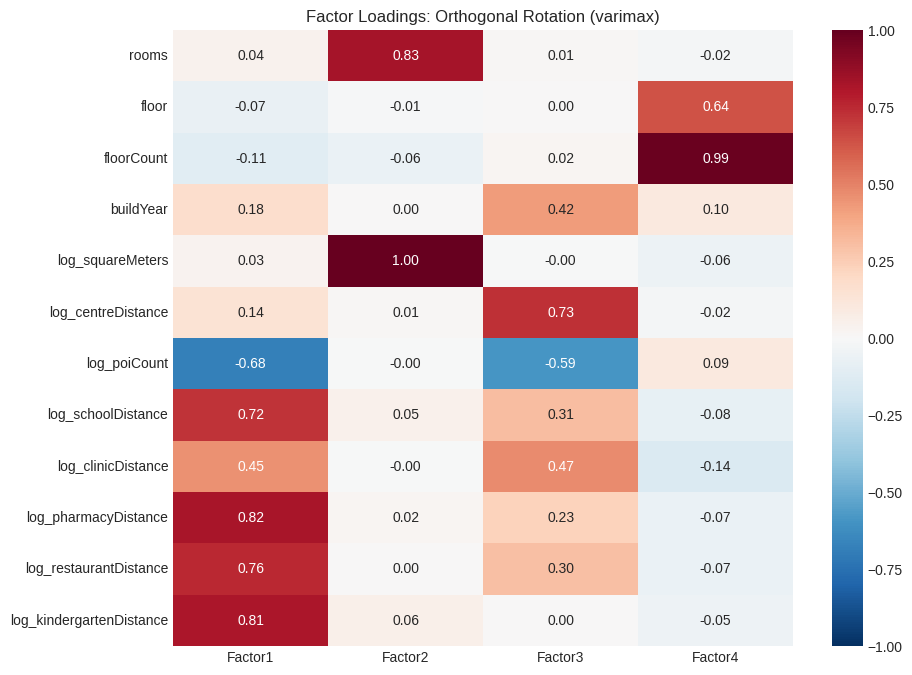


--- Variance Breakdown per Variable ---
                          Communality (h^2)  Specific Var (Uniqueness)
log_squareMeters                   0.995000                   0.005000
floorCount                         0.995000                   0.005000
log_poiCount                       0.825067                   0.174933
log_pharmacyDistance               0.733526                   0.266474
rooms                              0.693819                   0.306181
log_kindergartenDistance           0.669069                   0.330931
log_restaurantDistance             0.665941                   0.334059
log_schoolDistance                 0.625065                   0.374935
log_centreDistance                 0.550491                   0.449509
log_clinicDistance                 0.447050                   0.552950
floor                              0.409867                   0.590133
buildYear                          0.219729                   0.780271


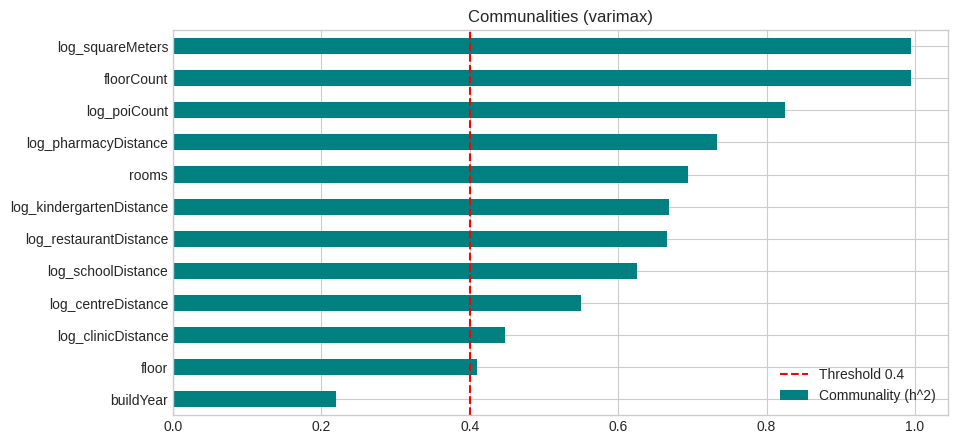


==================== OBLIQUE ROTATION (promax) ====================


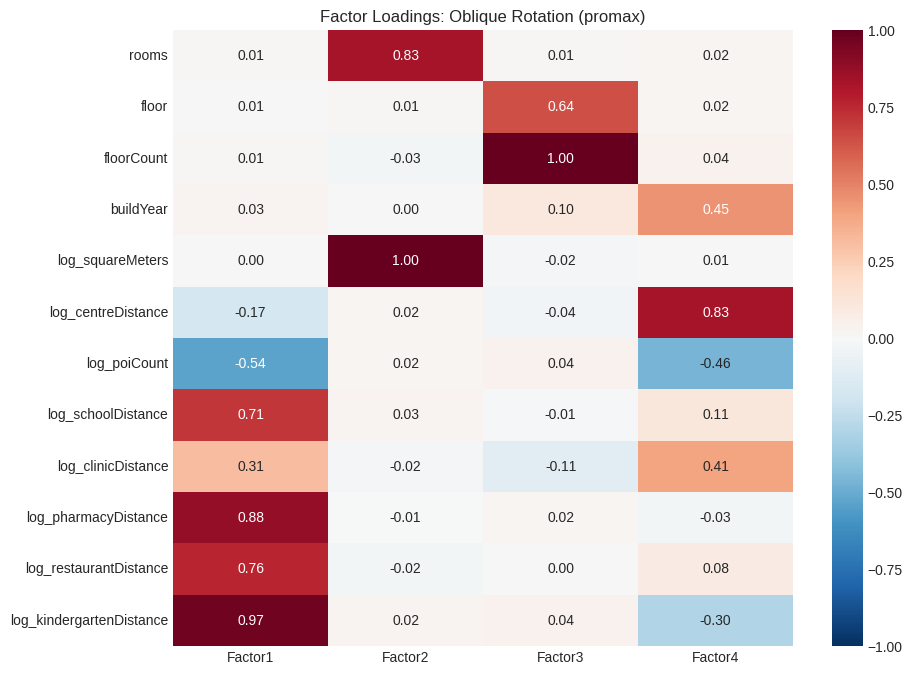

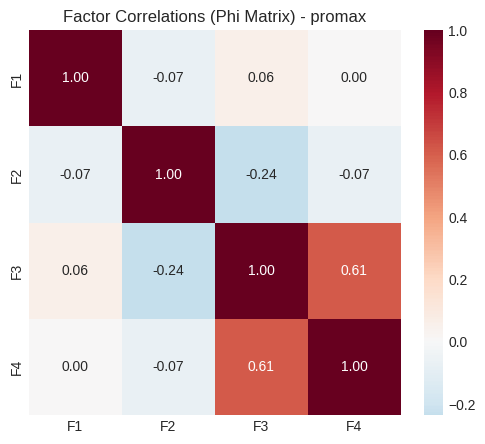


--- Variance Breakdown per Variable ---
                          Communality (h^2)  Specific Var (Uniqueness)
log_kindergartenDistance           1.042006                  -0.042006
floorCount                         1.002668                  -0.002668
log_squareMeters                   0.991411                   0.008589
log_pharmacyDistance               0.773885                   0.226115
log_centreDistance                 0.727474                   0.272526
rooms                              0.694021                   0.305979
log_restaurantDistance             0.592096                   0.407904
log_schoolDistance                 0.519971                   0.480029
log_poiCount                       0.506081                   0.493919
floor                              0.414931                   0.585069
log_clinicDistance                 0.271951                   0.728049
buildYear                          0.212196                   0.787804


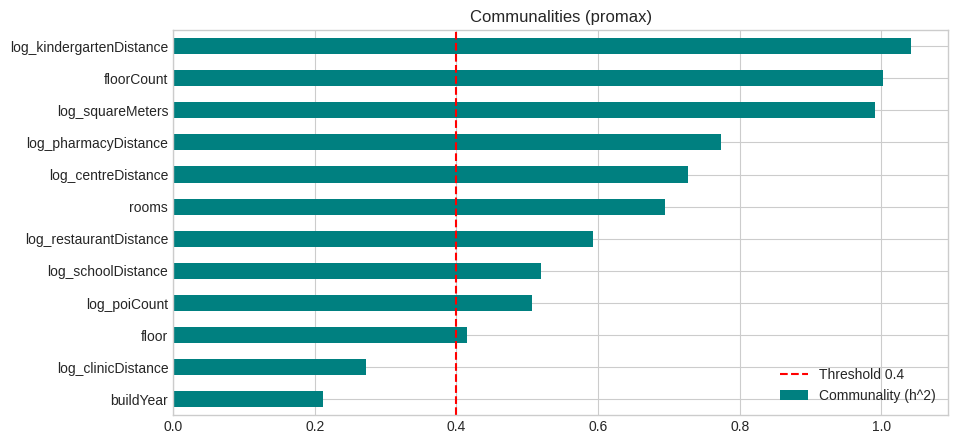

In [14]:
cols_fa = [
    'squareMeters', 'rooms', 'floor', 'floorCount', 'buildYear',
    'centreDistance', 'poiCount', 'schoolDistance', 'clinicDistance',
    'pharmacyDistance', 'restaurantDistance', 'kindergartenDistance'
]
cols_fa = [c for c in cols_fa if c in df_clean.columns]

X = df_clean[cols_fa].copy()
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=cols_fa)

for col in X_imputed.columns:
    if 'Distance' in col or col in ['squareMeters', 'poiCount']:
        X_imputed['log_' + col] = np.log(X_imputed[col] + 1)
        X_imputed = X_imputed.drop(columns=[col])

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_imputed), columns=X_imputed.columns)

print(f"Data shape for FA: {X_scaled.shape}")

def analyze_and_plot(data, n_factors, rotation, title):
    """
    Выполняет Факторный Анализ, строит heatmap нагрузок
    и выводит Communalities/Specific Variance.
    """
    print(f"\n{'='*20} {title.upper()} ({rotation}) {'='*20}")

    fa = FactorAnalyzer(n_factors=n_factors, rotation=rotation, method='ml')
    fa.fit(data)

    loadings = pd.DataFrame(
        fa.loadings_,
        index=data.columns,
        columns=[f'Factor{i+1}' for i in range(n_factors)]
    )

    plt.figure(figsize=(10, 8))
    sns.heatmap(loadings, annot=True, cmap='RdBu_r', center=0, fmt='.2f', vmin=-1, vmax=1)
    plt.title(f'Factor Loadings: {title} ({rotation})')
    plt.show()

    if rotation == 'promax':
        if fa.phi_ is not None:
            phi = pd.DataFrame(fa.phi_,
                               index=[f'F{i+1}' for i in range(n_factors)],
                               columns=[f'F{i+1}' for i in range(n_factors)])
            plt.figure(figsize=(6, 5))
            sns.heatmap(phi, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
            plt.title(f'Factor Correlations (Phi Matrix) - {rotation}')
            plt.show()

    communalities = fa.get_communalities()
    specific_variance = fa.get_uniquenesses()

    metrics_df = pd.DataFrame({
        'Communality (h^2)': communalities,
        'Specific Var (Uniqueness)': specific_variance
    }, index=data.columns)

    print("\n--- Variance Breakdown per Variable ---")
    print(metrics_df.sort_values(by='Communality (h^2)', ascending=False))

    plt.figure(figsize=(10, 5))
    metrics_df['Communality (h^2)'].sort_values().plot(kind='barh', color='teal')
    plt.axvline(0.4, color='red', linestyle='--', label='Threshold 0.4')
    plt.title(f'Communalities ({rotation})')
    plt.legend()
    plt.show()

analyze_and_plot(X_scaled, n_factors=4, rotation='varimax', title="Orthogonal Rotation")
analyze_and_plot(X_scaled, n_factors=4, rotation='promax', title="Oblique Rotation")

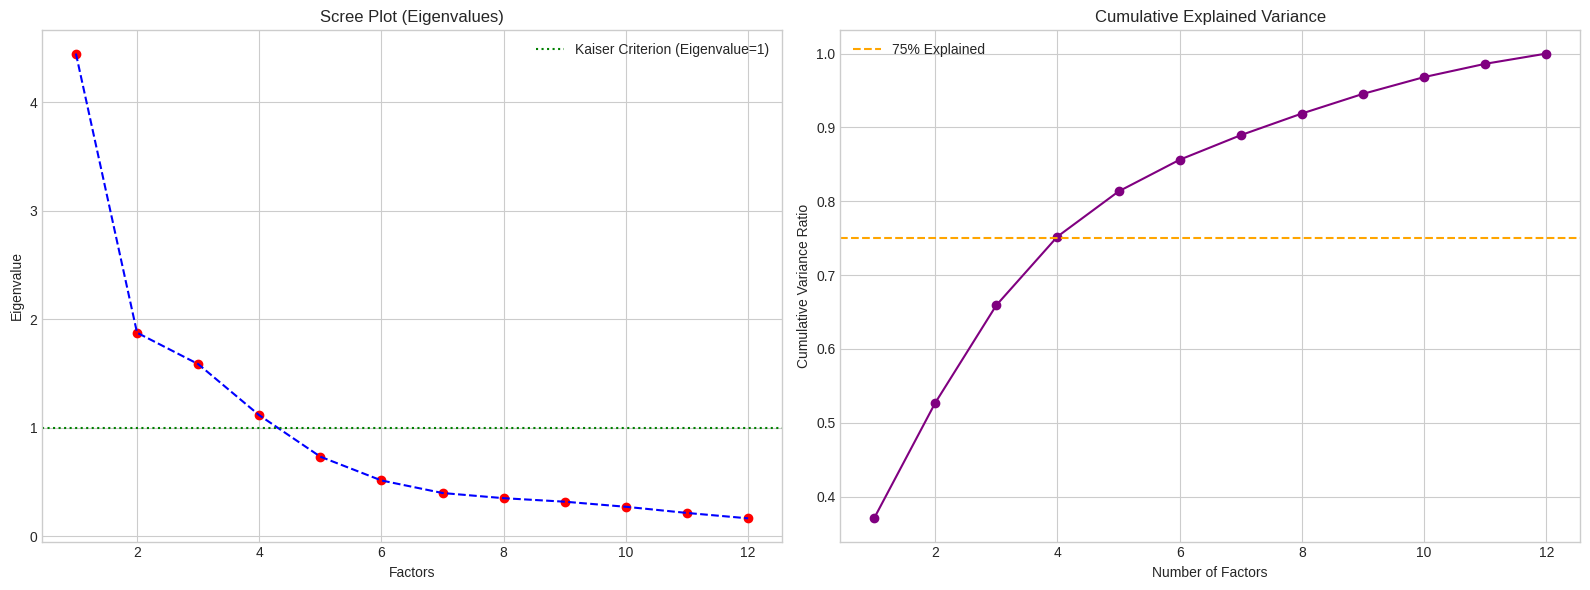

In [15]:
fa_explore = FactorAnalyzer(rotation=None)
fa_explore.fit(X_scaled)

ev, v = fa_explore.get_eigenvalues()

total_variance = X_scaled.shape[1]
explained_variance_ratio = ev / total_variance
cumulative_variance = np.cumsum(explained_variance_ratio)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(range(1, X_scaled.shape[1]+1), ev, color='red')
axes[0].plot(range(1, X_scaled.shape[1]+1), ev, color='blue', linestyle='--')
axes[0].set_title('Scree Plot (Eigenvalues)')
axes[0].set_xlabel('Factors')
axes[0].set_ylabel('Eigenvalue')
axes[0].axhline(1, color='green', linestyle=':', label='Kaiser Criterion (Eigenvalue=1)')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(range(1, X_scaled.shape[1]+1), cumulative_variance, marker='o', linestyle='-', color='purple')
axes[1].set_title('Cumulative Explained Variance')
axes[1].set_xlabel('Number of Factors')
axes[1].set_ylabel('Cumulative Variance Ratio')
axes[1].axhline(0.75, color='orange', linestyle='--', label='75% Explained')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

#DISCRIMINATION AND CLASSIFICATION ANALYSIS


Median Price: 721,824 PLN

Price Category Distribution:
price_category
High    10752
Low     10749
Name: count, dtype: int64

Original dataset size: 21501
Analysis dataset size (after removing missing values): 21501

Training set size: 15050
Test set size: 6451
ASSUMPTION CHECKING FOR LDA

Univariate Normality Tests (Shapiro-Wilk) for each feature:
(Testing on random sample of 5000 due to Shapiro-Wilk limitations)
            Variable  Statistic      p-value
        squareMeters   0.921590 3.317527e-45
               rooms   0.861052 6.613606e-55
               floor   0.761328 5.646931e-65
          floorCount   0.804092 3.369738e-61
           buildYear   0.905181 2.553885e-48
      centreDistance   0.959254 2.655997e-35
            poiCount   0.692783 5.684400e-70
      schoolDistance   0.607634 5.384449e-75
      clinicDistance   0.813007 2.519374e-60
  postOfficeDistance   0.696187 9.533200e-70
kindergartenDistance   0.559788 2.026399e-77
  restaurantDistance   0.567663 4.894274e

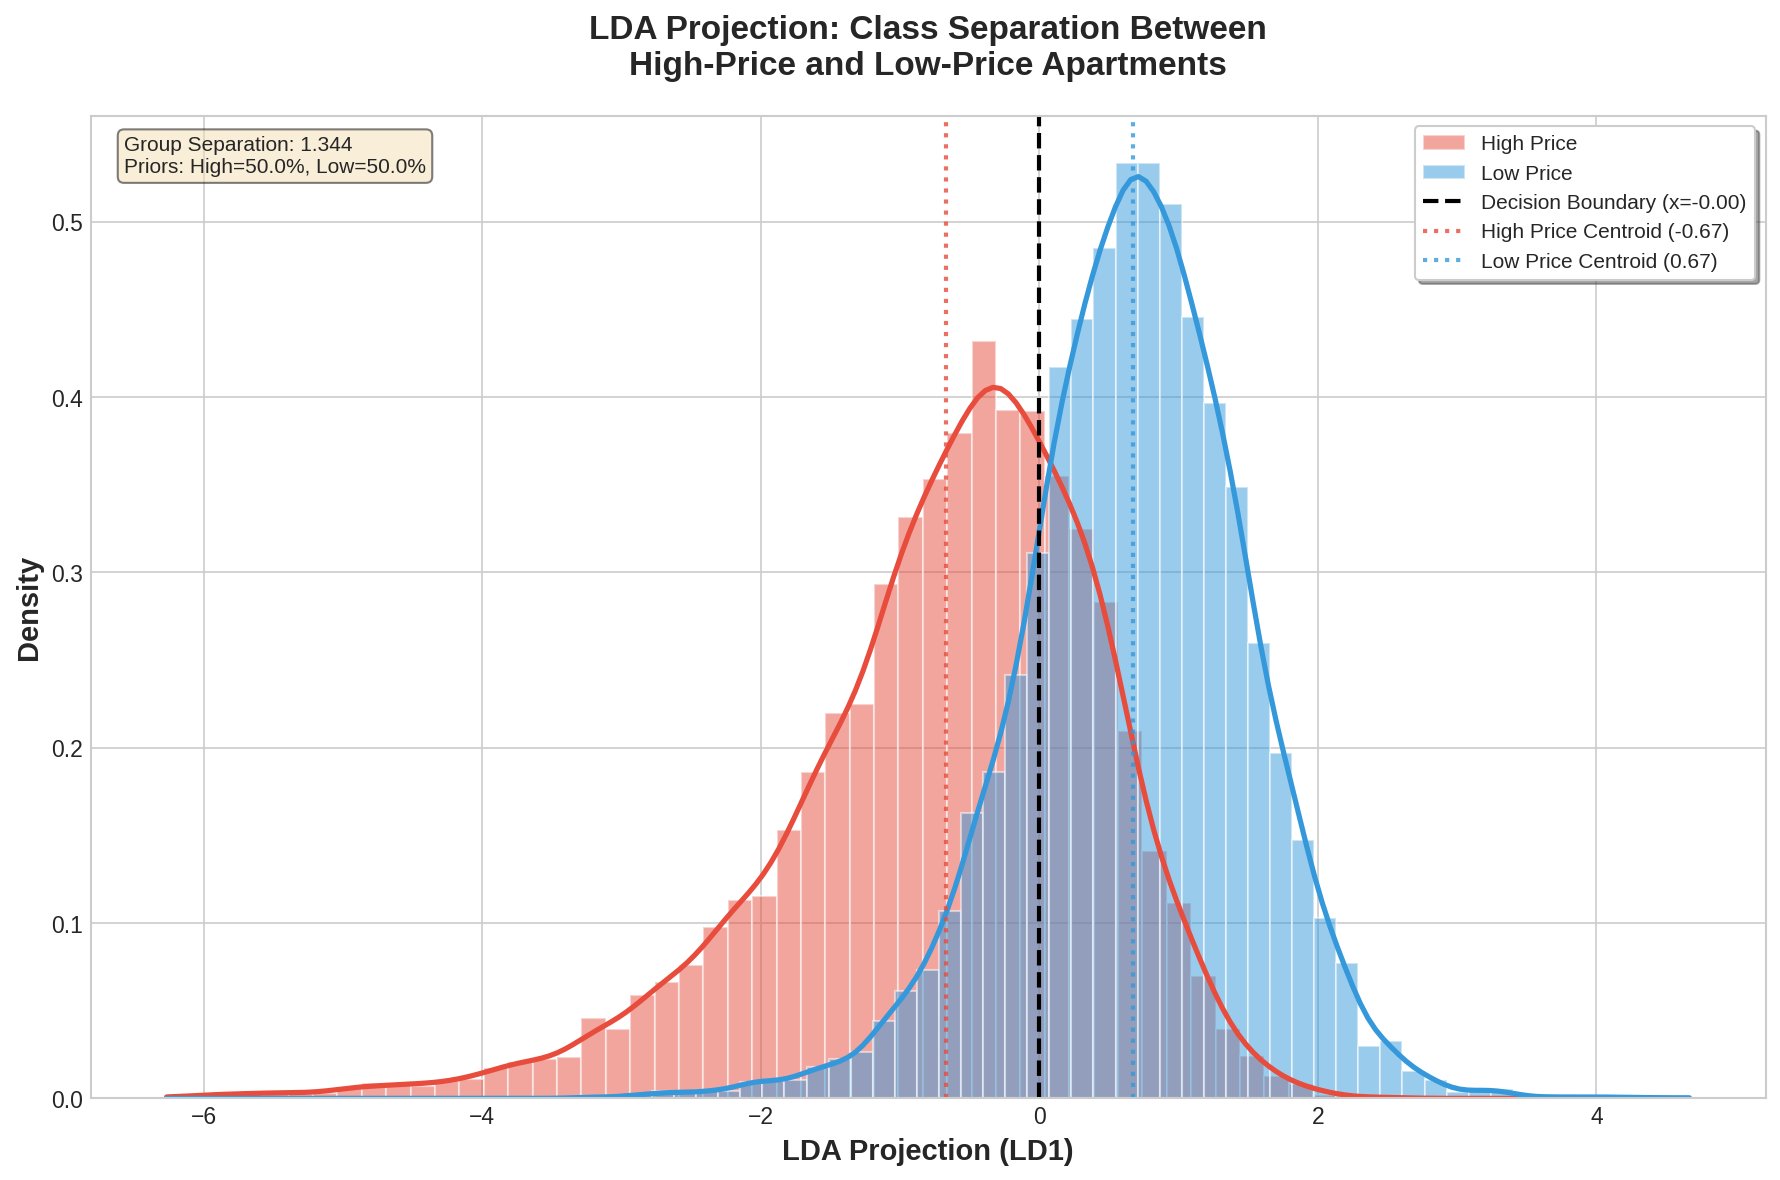

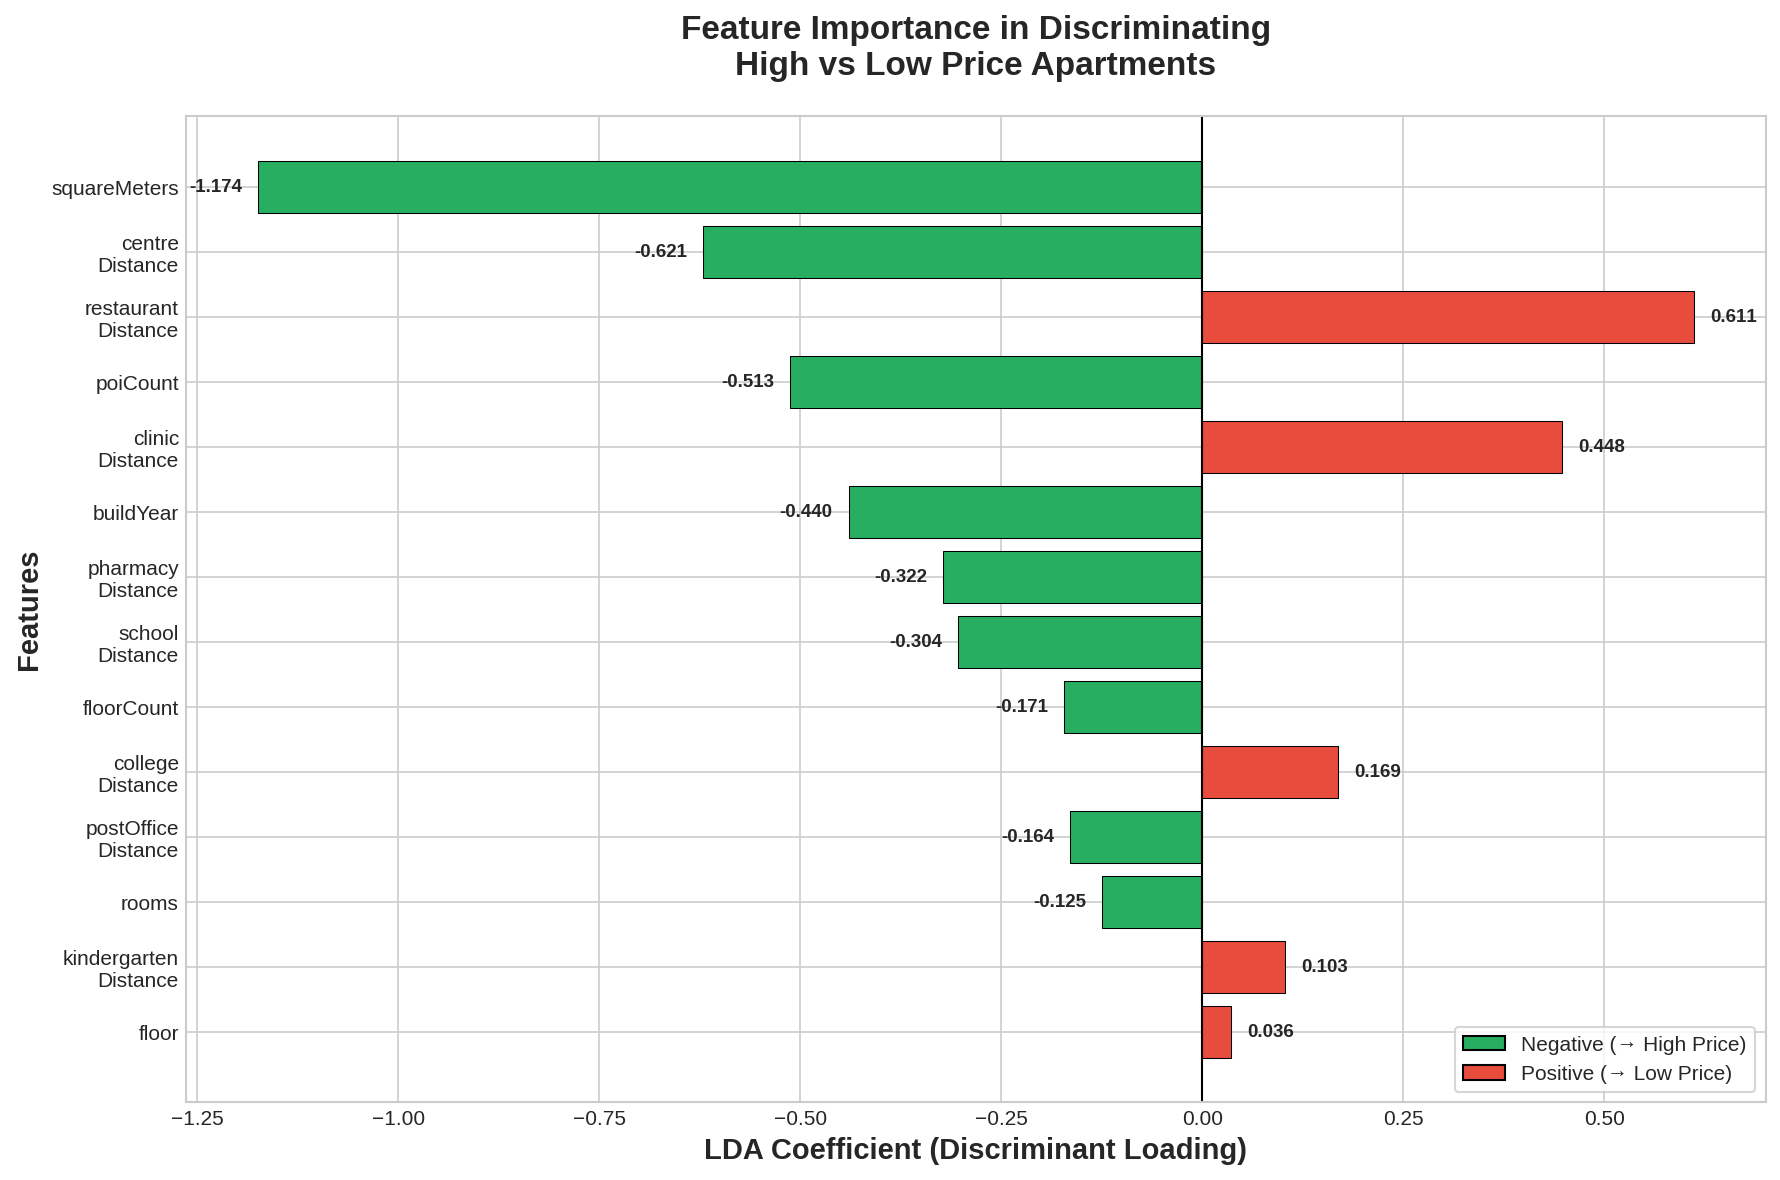

Saved: viz2_feature_importance.png


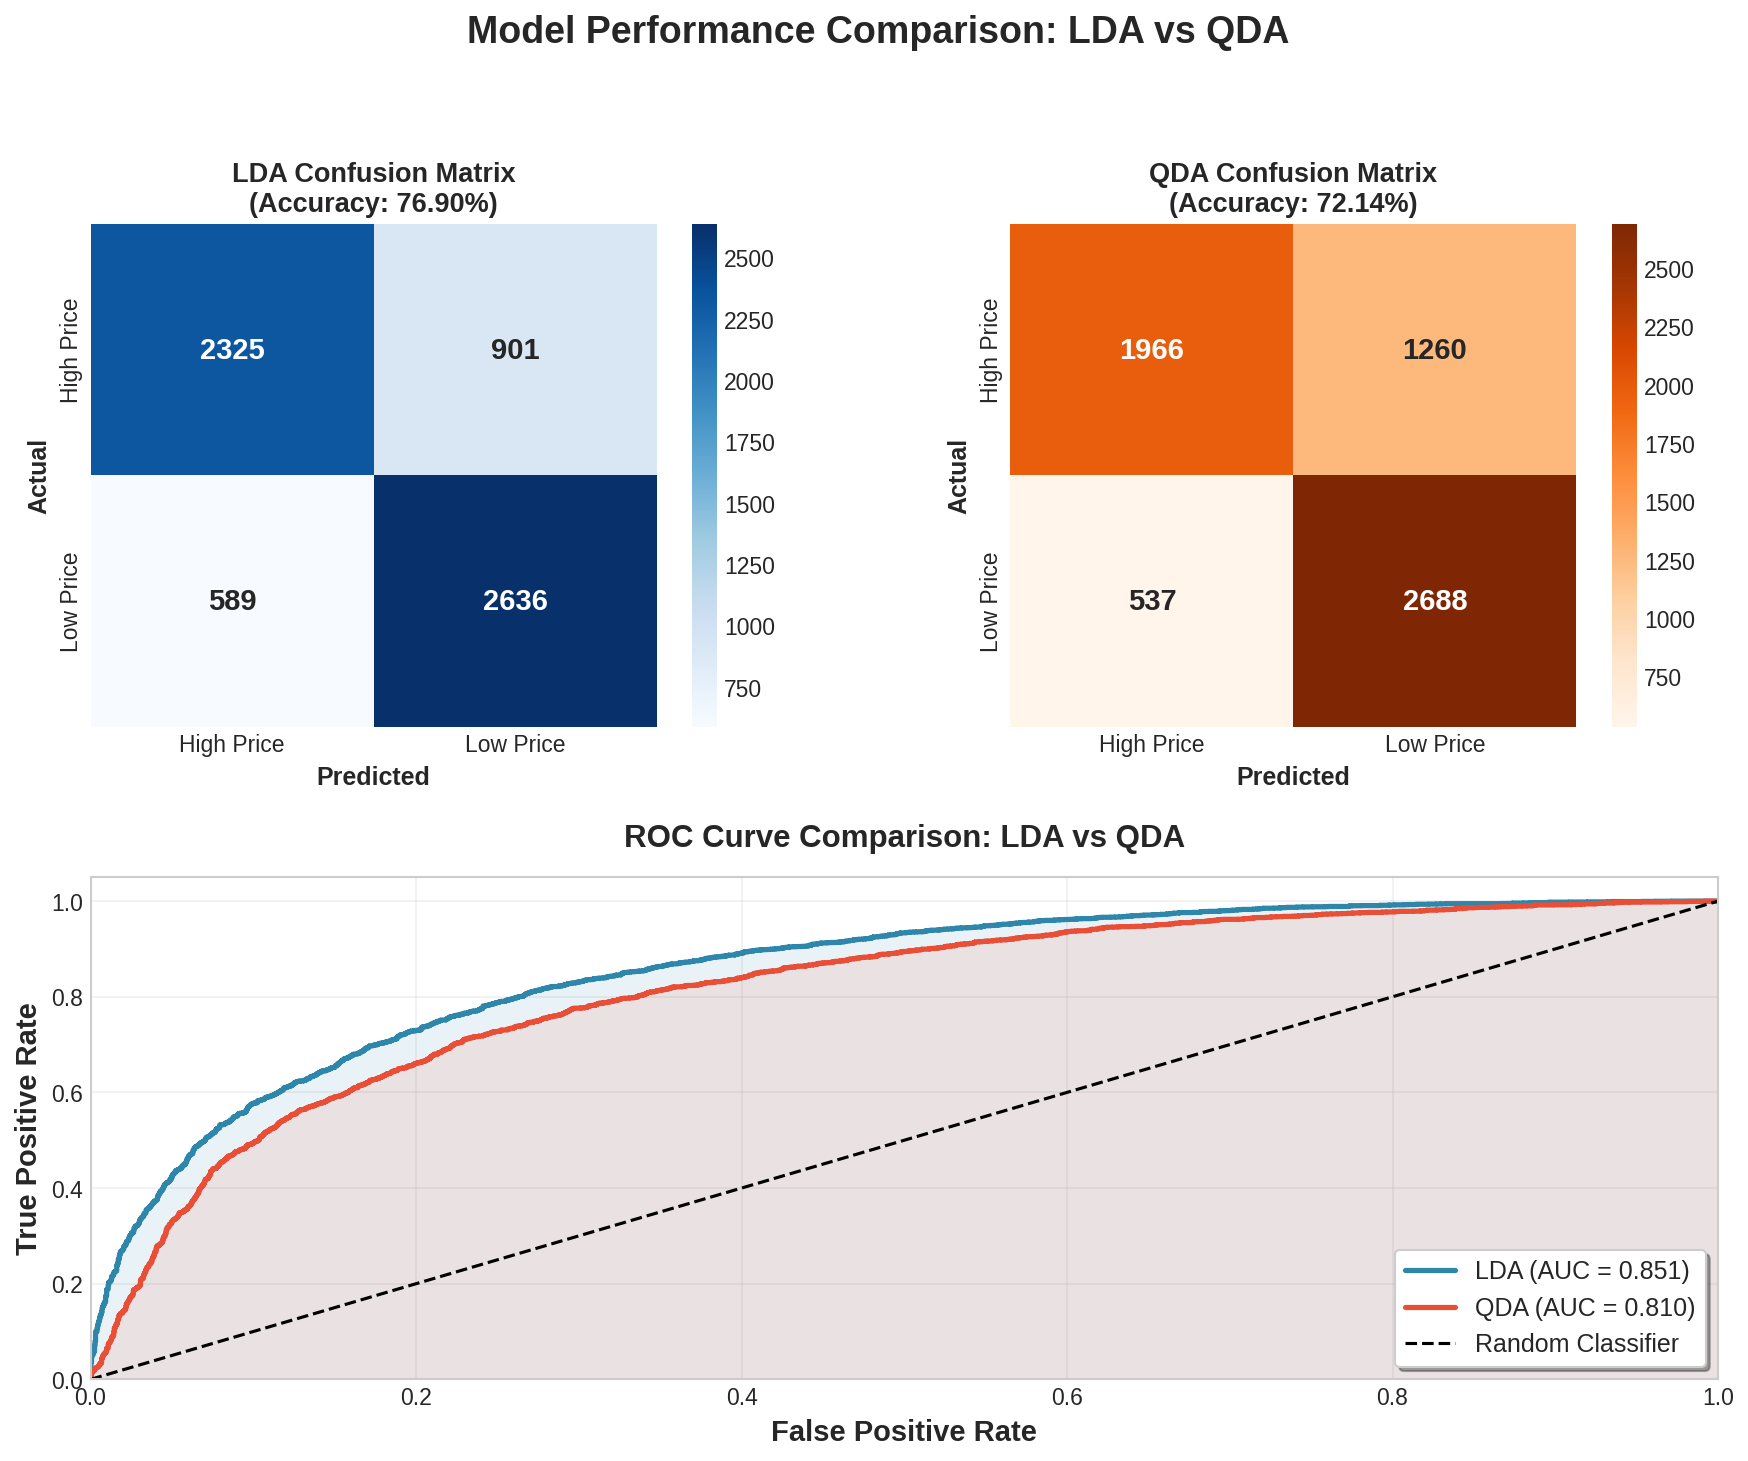

In [16]:
# Set style for visualizations
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# DATA PREPARATION

# Create target variable: Price Category (High/Low based on median)
median_price = df_clean['price'].median()
df_clean['price_category'] = np.where(df_clean['price'] >= median_price, 'High', 'Low')

print(f"\nMedian Price: {median_price:,.0f} PLN")
print(f"\nPrice Category Distribution:")
print(df_clean['price_category'].value_counts())

# Select continuous features for discrimination analysis
continuous_features = ['squareMeters', 'rooms', 'floor', 'floorCount', 'buildYear',
                       'centreDistance', 'poiCount', 'schoolDistance', 'clinicDistance',
                       'postOfficeDistance', 'kindergartenDistance', 'restaurantDistance',
                       'collegeDistance', 'pharmacyDistance']

# Create analysis dataset (drop rows with missing values in features)
analysis_df = df_clean[continuous_features + ['price_category']].copy()
analysis_df = analysis_df.dropna()

print(f"\nOriginal dataset size: {len(df)}")
print(f"Analysis dataset size (after removing missing values): {len(analysis_df)}")

# Separate features and target
X = analysis_df[continuous_features]
y = analysis_df['price_category']

# Encode target variable
le = LabelEncoder()
y_encoded = le.fit_transform(y)  # High=0, Low=1

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=continuous_features)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

print(f"\nTraining set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")


# ASSUMPTION CHECKING
print("ASSUMPTION CHECKING FOR LDA")


# Check multivariate normality using Mardia's test approximation
# We'll use univariate normality tests as a proxy
print("\nUnivariate Normality Tests (Shapiro-Wilk) for each feature:")
print("(Testing on random sample of 5000 due to Shapiro-Wilk limitations)")

normality_results = []
sample_size = min(5000, len(X_scaled))
sample_idx = np.random.choice(len(X_scaled), sample_size, replace=False)

for i, col in enumerate(continuous_features):
    stat, p = stats.shapiro(X_scaled[sample_idx, i])
    normality_results.append({'Variable': col, 'Statistic': stat, 'p-value': p})

norm_df = pd.DataFrame(normality_results)
print(norm_df.to_string(index=False))

# Check homogeneity of covariance matrices using Box's M test approximation
print("\n\nHomogeneity of Covariance Matrices:")
print("(Checking variance ratios between groups)")

high_price_idx = y_encoded == 0
low_price_idx = y_encoded == 1

variance_ratios = []
for i, col in enumerate(continuous_features):
    var_high = np.var(X_scaled[high_price_idx, i])
    var_low = np.var(X_scaled[low_price_idx, i])
    ratio = max(var_high, var_low) / min(var_high, var_low)
    variance_ratios.append({'Variable': col, 'Var_High': round(var_high, 4),
                           'Var_Low': round(var_low, 4), 'Ratio': round(ratio, 4)})

var_df = pd.DataFrame(variance_ratios)
print(var_df.to_string(index=False))

print("\nNote: Variance ratios > 2 suggest potential violation of equal covariance assumption.")
print("QDA may be more appropriate if violations are severe.")


# LINEAR DISCRIMINANT ANALYSIS (LDA)
print("LINEAR DISCRIMINANT ANALYSIS (LDA)")

# Fit LDA
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

# Predictions
y_pred_lda = lda.predict(X_test)
y_prob_lda = lda.predict_proba(X_test)[:, 1]

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_lda = cross_val_score(lda, X_scaled, y_encoded, cv=cv, scoring='accuracy')

print(f"\nLDA Results:")
print(f"Training Accuracy: {lda.score(X_train, y_train):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_lda):.4f}")
print(f"Cross-Validation Accuracy: {cv_scores_lda.mean():.4f} (+/- {cv_scores_lda.std()*2:.4f})")

print("\nClassification Report (LDA):")
print(classification_report(y_test, y_pred_lda, target_names=['High Price', 'Low Price']))

# LDA Coefficients (Discriminant Function)
print("\nLDA Discriminant Function Coefficients:")
lda_coef_df = pd.DataFrame({
    'Variable': continuous_features,
    'Coefficient': lda.coef_[0],
    'Abs_Coefficient': np.abs(lda.coef_[0])
}).sort_values('Abs_Coefficient', ascending=False)
print(lda_coef_df.to_string(index=False))

# Group means
print("\nGroup Means (Standardized):")
group_means_df = pd.DataFrame(lda.means_, columns=continuous_features,
                              index=['High Price', 'Low Price'])
print(group_means_df.T.round(3))

# QUADRATIC DISCRIMINANT ANALYSIS (QDA)

print("QUADRATIC DISCRIMINANT ANALYSIS (QDA)")
# Fit QDA
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train, y_train)

# Predictions
y_pred_qda = qda.predict(X_test)
y_prob_qda = qda.predict_proba(X_test)[:, 1]

# Cross-validation
cv_scores_qda = cross_val_score(qda, X_scaled, y_encoded, cv=cv, scoring='accuracy')

print(f"\nQDA Results:")
print(f"Training Accuracy: {qda.score(X_train, y_train):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_qda):.4f}")
print(f"Cross-Validation Accuracy: {cv_scores_qda.mean():.4f} (+/- {cv_scores_qda.std()*2:.4f})")

print("\nClassification Report (QDA):")
print(classification_report(y_test, y_pred_qda, target_names=['High Price', 'Low Price']))

# MODEL COMPARISON
print("MODEL COMPARISON")

comparison_df = pd.DataFrame({
    'Model': ['LDA', 'QDA'],
    'Train_Accuracy': [lda.score(X_train, y_train), qda.score(X_train, y_train)],
    'Test_Accuracy': [accuracy_score(y_test, y_pred_lda), accuracy_score(y_test, y_pred_qda)],
    'CV_Accuracy_Mean': [cv_scores_lda.mean(), cv_scores_qda.mean()],
    'CV_Accuracy_Std': [cv_scores_lda.std(), cv_scores_qda.std()]
})
print(comparison_df.to_string(index=False))

# VISUALIZATIONS
print("CREATING VISUALIZATIONS")

# VISUALIZATION 1: LDA Projection with Class Separation

fig1, ax1 = plt.subplots(figsize=(12, 8))

# Project all data onto LDA component
X_lda_all = lda.transform(X_scaled)

# Create histogram-style visualization with density curves
colors = {'High': '#E74C3C', 'Low': '#3498DB'}

for label, color, idx in zip(['High', 'Low'], [colors['High'], colors['Low']], [0, 1]):
    mask = y_encoded == idx
    ax1.hist(X_lda_all[mask, 0], bins=50, alpha=0.5, label=f'{label} Price',
             color=color, density=True, edgecolor='white')

    # Add density curve
    from scipy.stats import gaussian_kde
    kde = gaussian_kde(X_lda_all[mask, 0])
    x_range = np.linspace(X_lda_all[:, 0].min(), X_lda_all[:, 0].max(), 200)
    ax1.plot(x_range, kde(x_range), color=color, linewidth=2.5, linestyle='-')

mean_high = X_lda_all[y_encoded == 0, 0].mean()
mean_low = X_lda_all[y_encoded == 1, 0].mean()

# Pooled variance in the projected space
var_pooled = X_lda_all[:, 0].var()

# Prior probabilities
pi_high = lda.priors_[0]
pi_low = lda.priors_[1]

# Calculate correct decision boundary
# Midpoint adjusted for unequal priors
midpoint = (mean_high + mean_low) / 2
prior_adjustment = (var_pooled / (mean_low - mean_high)) * np.log(pi_low / pi_high)
decision_boundary = midpoint + prior_adjustment

# Add decision boundary
ax1.axvline(x=decision_boundary, color='black', linestyle='--', linewidth=2,
            label=f'Decision Boundary (x={decision_boundary:.2f})')

# Add group means (centroids)
ax1.axvline(x=mean_high, color=colors['High'], linestyle=':', linewidth=2, alpha=0.8,
            label=f'High Price Centroid ({mean_high:.2f})')
ax1.axvline(x=mean_low, color=colors['Low'], linestyle=':', linewidth=2, alpha=0.8,
            label=f'Low Price Centroid ({mean_low:.2f})')

ax1.set_xlabel('LDA Projection (LD1)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Density', fontsize=14, fontweight='bold')
ax1.set_title('LDA Projection: Class Separation Between\nHigh-Price and Low-Price Apartments',
              fontsize=16, fontweight='bold', pad=20)
ax1.legend(loc='upper right', fontsize=10, frameon=True, fancybox=True, shadow=True)
ax1.tick_params(axis='both', labelsize=11)

# Add text annotation for separation
separation = abs(mean_high - mean_low)
ax1.text(0.02, 0.98, f'Group Separation: {separation:.3f}\nPriors: High={pi_high:.1%}, Low={pi_low:.1%}',
         transform=ax1.transAxes, fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()
plt.close()

# VISUALIZATION 2: Feature Importance Bar Plot (LDA Coefficients)

fig2, ax2 = plt.subplots(figsize=(12, 8))

# Sort by absolute coefficient
sorted_coef = lda_coef_df.sort_values('Abs_Coefficient', ascending=True)

# Create color based on sign
# Note: With encoding High=0, Low=1:
# Negative coefficient → higher values push toward High Price (class 0)
# Positive coefficient → higher values push toward Low Price (class 1)
colors_bar = ['#E74C3C' if c > 0 else '#27AE60' for c in sorted_coef['Coefficient']]

bars = ax2.barh(range(len(sorted_coef)), sorted_coef['Coefficient'], color=colors_bar,
                edgecolor='black', linewidth=0.5)

ax2.set_yticks(range(len(sorted_coef)))
ax2.set_yticklabels([col.replace('Distance', '\nDistance') for col in sorted_coef['Variable']], fontsize=11)
ax2.set_xlabel('LDA Coefficient (Discriminant Loading)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Features', fontsize=14, fontweight='bold')
ax2.set_title('Feature Importance in Discriminating\nHigh vs Low Price Apartments',
              fontsize=16, fontweight='bold', pad=20)

# Add vertical line at 0
ax2.axvline(x=0, color='black', linestyle='-', linewidth=1)

# Add value labels
for bar, val in zip(bars, sorted_coef['Coefficient']):
    width = bar.get_width()
    label_x = width + 0.02 if width >= 0 else width - 0.02
    ha = 'left' if width >= 0 else 'right'
    ax2.text(label_x, bar.get_y() + bar.get_height()/2, f'{val:.3f}',
             va='center', ha=ha, fontsize=9, fontweight='bold')

# Add legend (corrected interpretation)
# Negative coefficient = higher values → High Price (class 0)
# Positive coefficient = higher values → Low Price (class 1)
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#27AE60', edgecolor='black', label='Negative (→ High Price)'),
                   Patch(facecolor='#E74C3C', edgecolor='black', label='Positive (→ Low Price)')]
ax2.legend(handles=legend_elements, loc='lower right', fontsize=10, frameon=True)

ax2.tick_params(axis='both', labelsize=10)
plt.tight_layout()
plt.show()
plt.close()
print("Saved: viz2_feature_importance.png")

# VISUALIZATION 3: Combined Model Performance (Confusion Matrices + ROC Curves)

fig3 = plt.figure(figsize=(14, 10))

# Create subplot layout
gs = fig3.add_gridspec(2, 2, height_ratios=[1, 1], hspace=0.3, wspace=0.3)

# Confusion Matrix - LDA (top left)
ax3a = fig3.add_subplot(gs[0, 0])
cm_lda = confusion_matrix(y_test, y_pred_lda)
sns.heatmap(cm_lda, annot=True, fmt='d', cmap='Blues', ax=ax3a,
            xticklabels=['High Price', 'Low Price'],
            yticklabels=['High Price', 'Low Price'],
            annot_kws={'size': 14, 'weight': 'bold'})
ax3a.set_xlabel('Predicted', fontsize=12, fontweight='bold')
ax3a.set_ylabel('Actual', fontsize=12, fontweight='bold')
ax3a.set_title(f'LDA Confusion Matrix\n(Accuracy: {accuracy_score(y_test, y_pred_lda):.2%})',
               fontsize=13, fontweight='bold')

# Confusion Matrix - QDA (top right)
ax3b = fig3.add_subplot(gs[0, 1])
cm_qda = confusion_matrix(y_test, y_pred_qda)
sns.heatmap(cm_qda, annot=True, fmt='d', cmap='Oranges', ax=ax3b,
            xticklabels=['High Price', 'Low Price'],
            yticklabels=['High Price', 'Low Price'],
            annot_kws={'size': 14, 'weight': 'bold'})
ax3b.set_xlabel('Predicted', fontsize=12, fontweight='bold')
ax3b.set_ylabel('Actual', fontsize=12, fontweight='bold')
ax3b.set_title(f'QDA Confusion Matrix\n(Accuracy: {accuracy_score(y_test, y_pred_qda):.2%})',
               fontsize=13, fontweight='bold')

# ROC Curves (bottom, spanning both columns)
ax3c = fig3.add_subplot(gs[1, :])

# LDA ROC
fpr_lda, tpr_lda, _ = roc_curve(y_test, y_prob_lda)
auc_lda = auc(fpr_lda, tpr_lda)

# QDA ROC
fpr_qda, tpr_qda, _ = roc_curve(y_test, y_prob_qda)
auc_qda = auc(fpr_qda, tpr_qda)

ax3c.plot(fpr_lda, tpr_lda, color='#2E86AB', linewidth=2.5,
          label=f'LDA (AUC = {auc_lda:.3f})')
ax3c.plot(fpr_qda, tpr_qda, color='#E94F37', linewidth=2.5,
          label=f'QDA (AUC = {auc_qda:.3f})')
ax3c.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Classifier')

ax3c.set_xlim([0.0, 1.0])
ax3c.set_ylim([0.0, 1.05])
ax3c.set_xlabel('False Positive Rate', fontsize=14, fontweight='bold')
ax3c.set_ylabel('True Positive Rate', fontsize=14, fontweight='bold')
ax3c.set_title('ROC Curve Comparison: LDA vs QDA', fontsize=15, fontweight='bold', pad=15)
ax3c.legend(loc='lower right', fontsize=12, frameon=True, fancybox=True, shadow=True)
ax3c.grid(True, alpha=0.3)

# Add AUC annotation
ax3c.fill_between(fpr_lda, tpr_lda, alpha=0.1, color='#2E86AB')
ax3c.fill_between(fpr_qda, tpr_qda, alpha=0.1, color='#E94F37')

plt.suptitle('Model Performance Comparison: LDA vs QDA', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
plt.close()

#Clustering

CLUSTERING ANALYSIS

Variables selected for clustering (15):
  1. squareMeters
  2. rooms
  3. floor
  4. floorCount
  5. buildYear
  6. centreDistance
  7. poiCount
  8. schoolDistance
  9. clinicDistance
  10. postOfficeDistance
  11. kindergartenDistance
  12. restaurantDistance
  13. collegeDistance
  14. pharmacyDistance
  15. price

Sample size after removing missing values: 21501
  schoolDistance: 99th percentile = 2.48
  kindergartenDistance: 99th percentile = 2.41
  pharmacyDistance: 99th percentile = 2.38

Removed 256 rural/remote outliers (1.2%)
Final sample size for clustering: 21245
Variables have been standardized (mean=0, std=1)

Standardized data shape: (21245, 15)
Determining Optimal Number of Clusters

Evaluating cluster numbers from 2 to 10...
  k=2: Inertia=261215.52, Silhouette=0.2494
  k=3: Inertia=233937.31, Silhouette=0.1773
  k=4: Inertia=212852.11, Silhouette=0.1366
  k=5: Inertia=193948.97, Silhouette=0.1455
  k=6: Inertia=182645.72, Silhouette=0.1405
  k=7: 

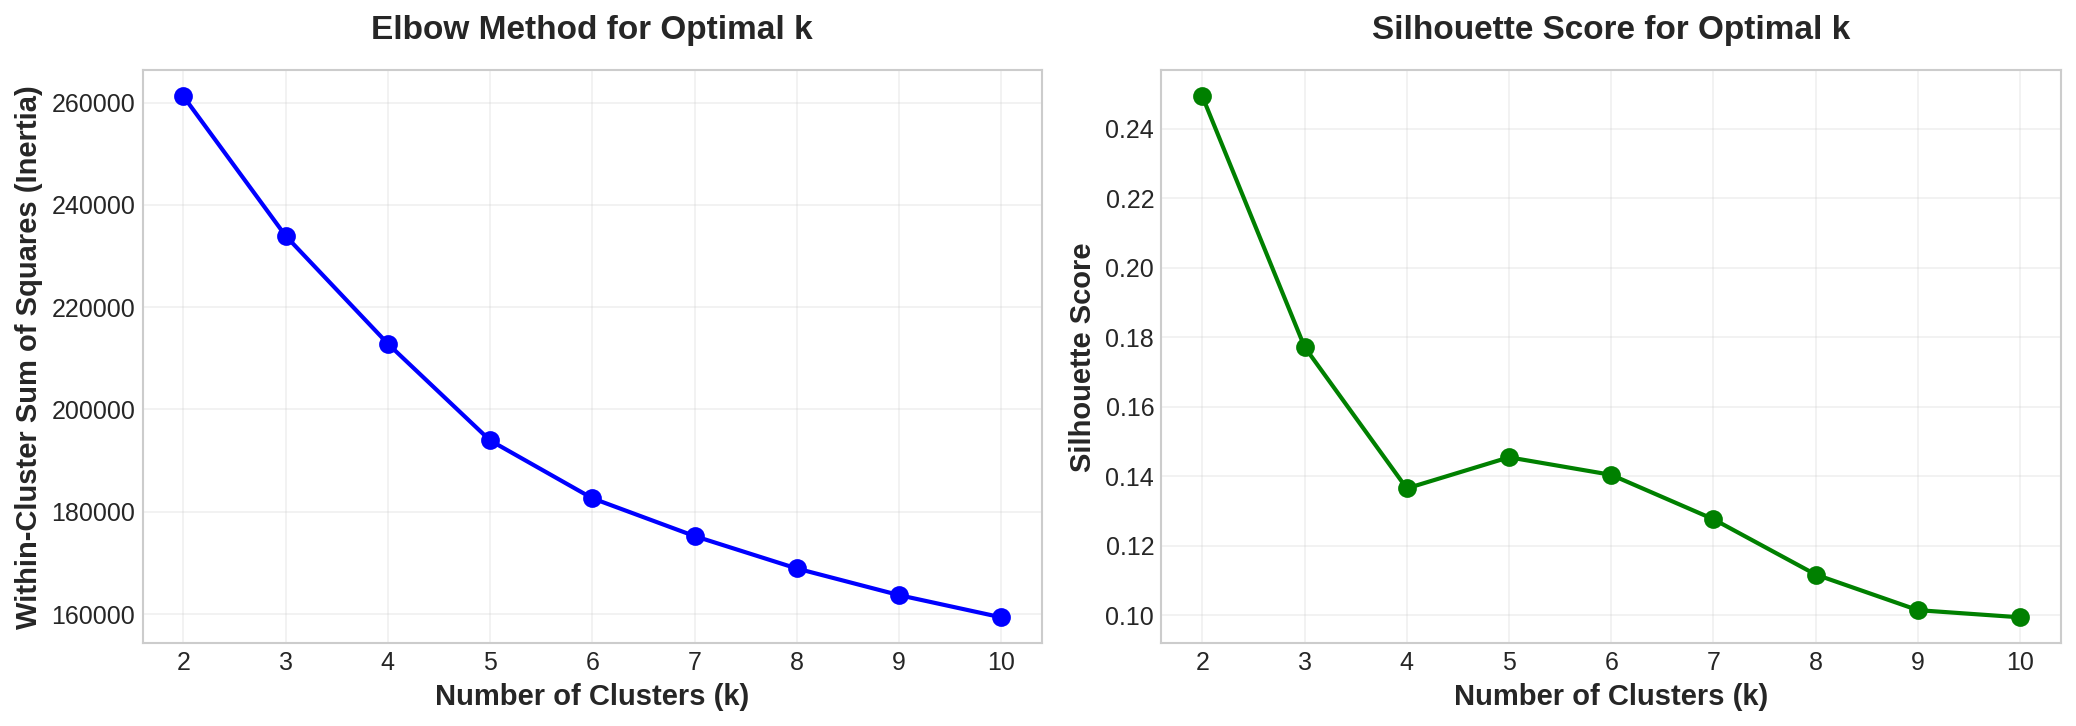

K-Means Clustering with k=3

Cluster Distribution:
  Cluster 0: 4243 apartments (20.0%)
  Cluster 1: 3560 apartments (16.8%)
  Cluster 2: 13442 apartments (63.3%)
Cluster Profiling - Characteristics of Each Segment

Cluster Means (Original Scale):
         squareMeters  rooms  floor  floorCount  buildYear  centreDistance  poiCount  schoolDistance  clinicDistance  postOfficeDistance  kindergartenDistance  restaurantDistance  collegeDistance  pharmacyDistance       price
Cluster                                                                                                                                                                                                                          
0               85.01   3.67   3.17        5.00    1980.65            3.72     32.42            0.29            0.60                0.38                  0.29                0.19             1.06              0.23  1363809.37
1               58.29   2.70   2.52        3.84    2007.92            6.86

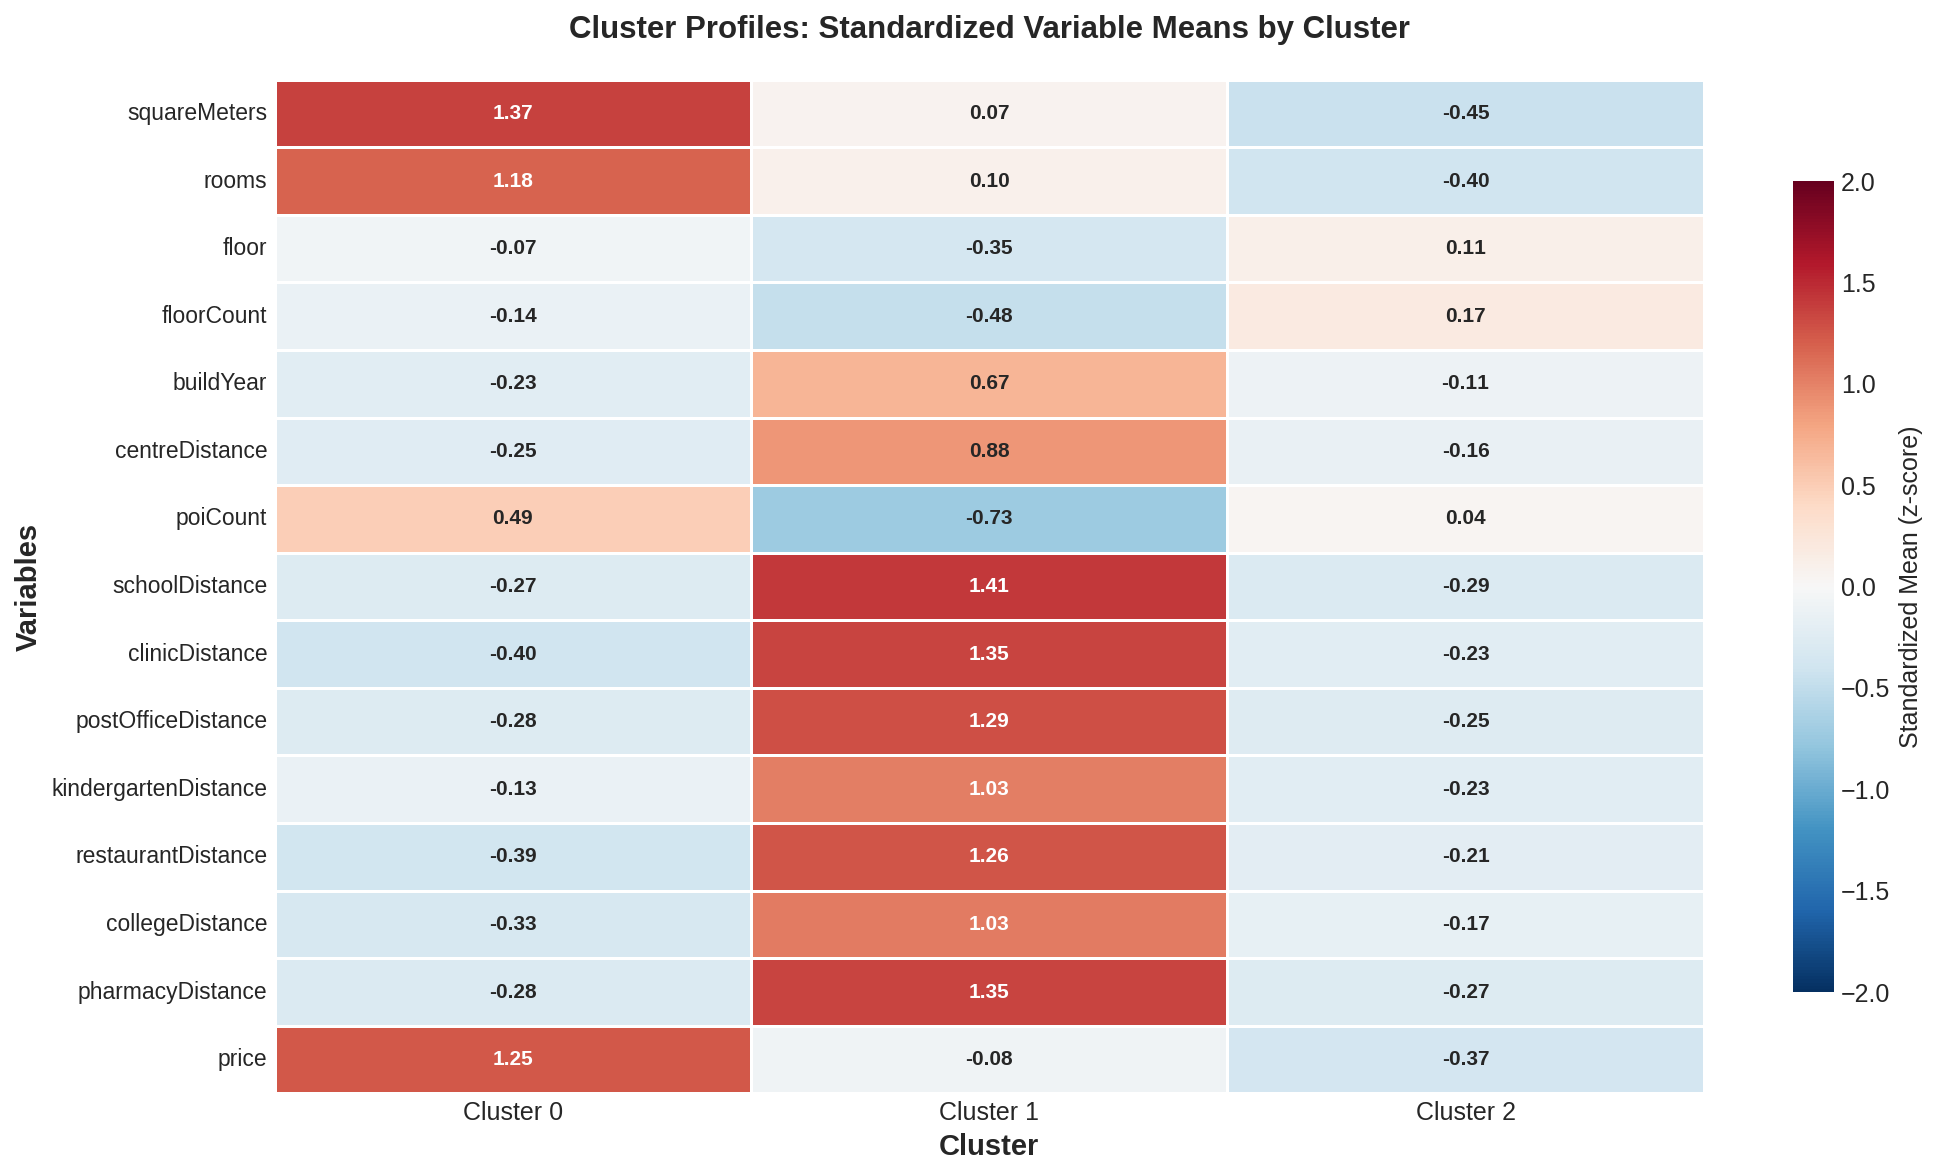

Hierarchical Clustering Analysis

Using 2000 samples for hierarchical clustering visualization
Computing linkage matrix (Ward's method)...


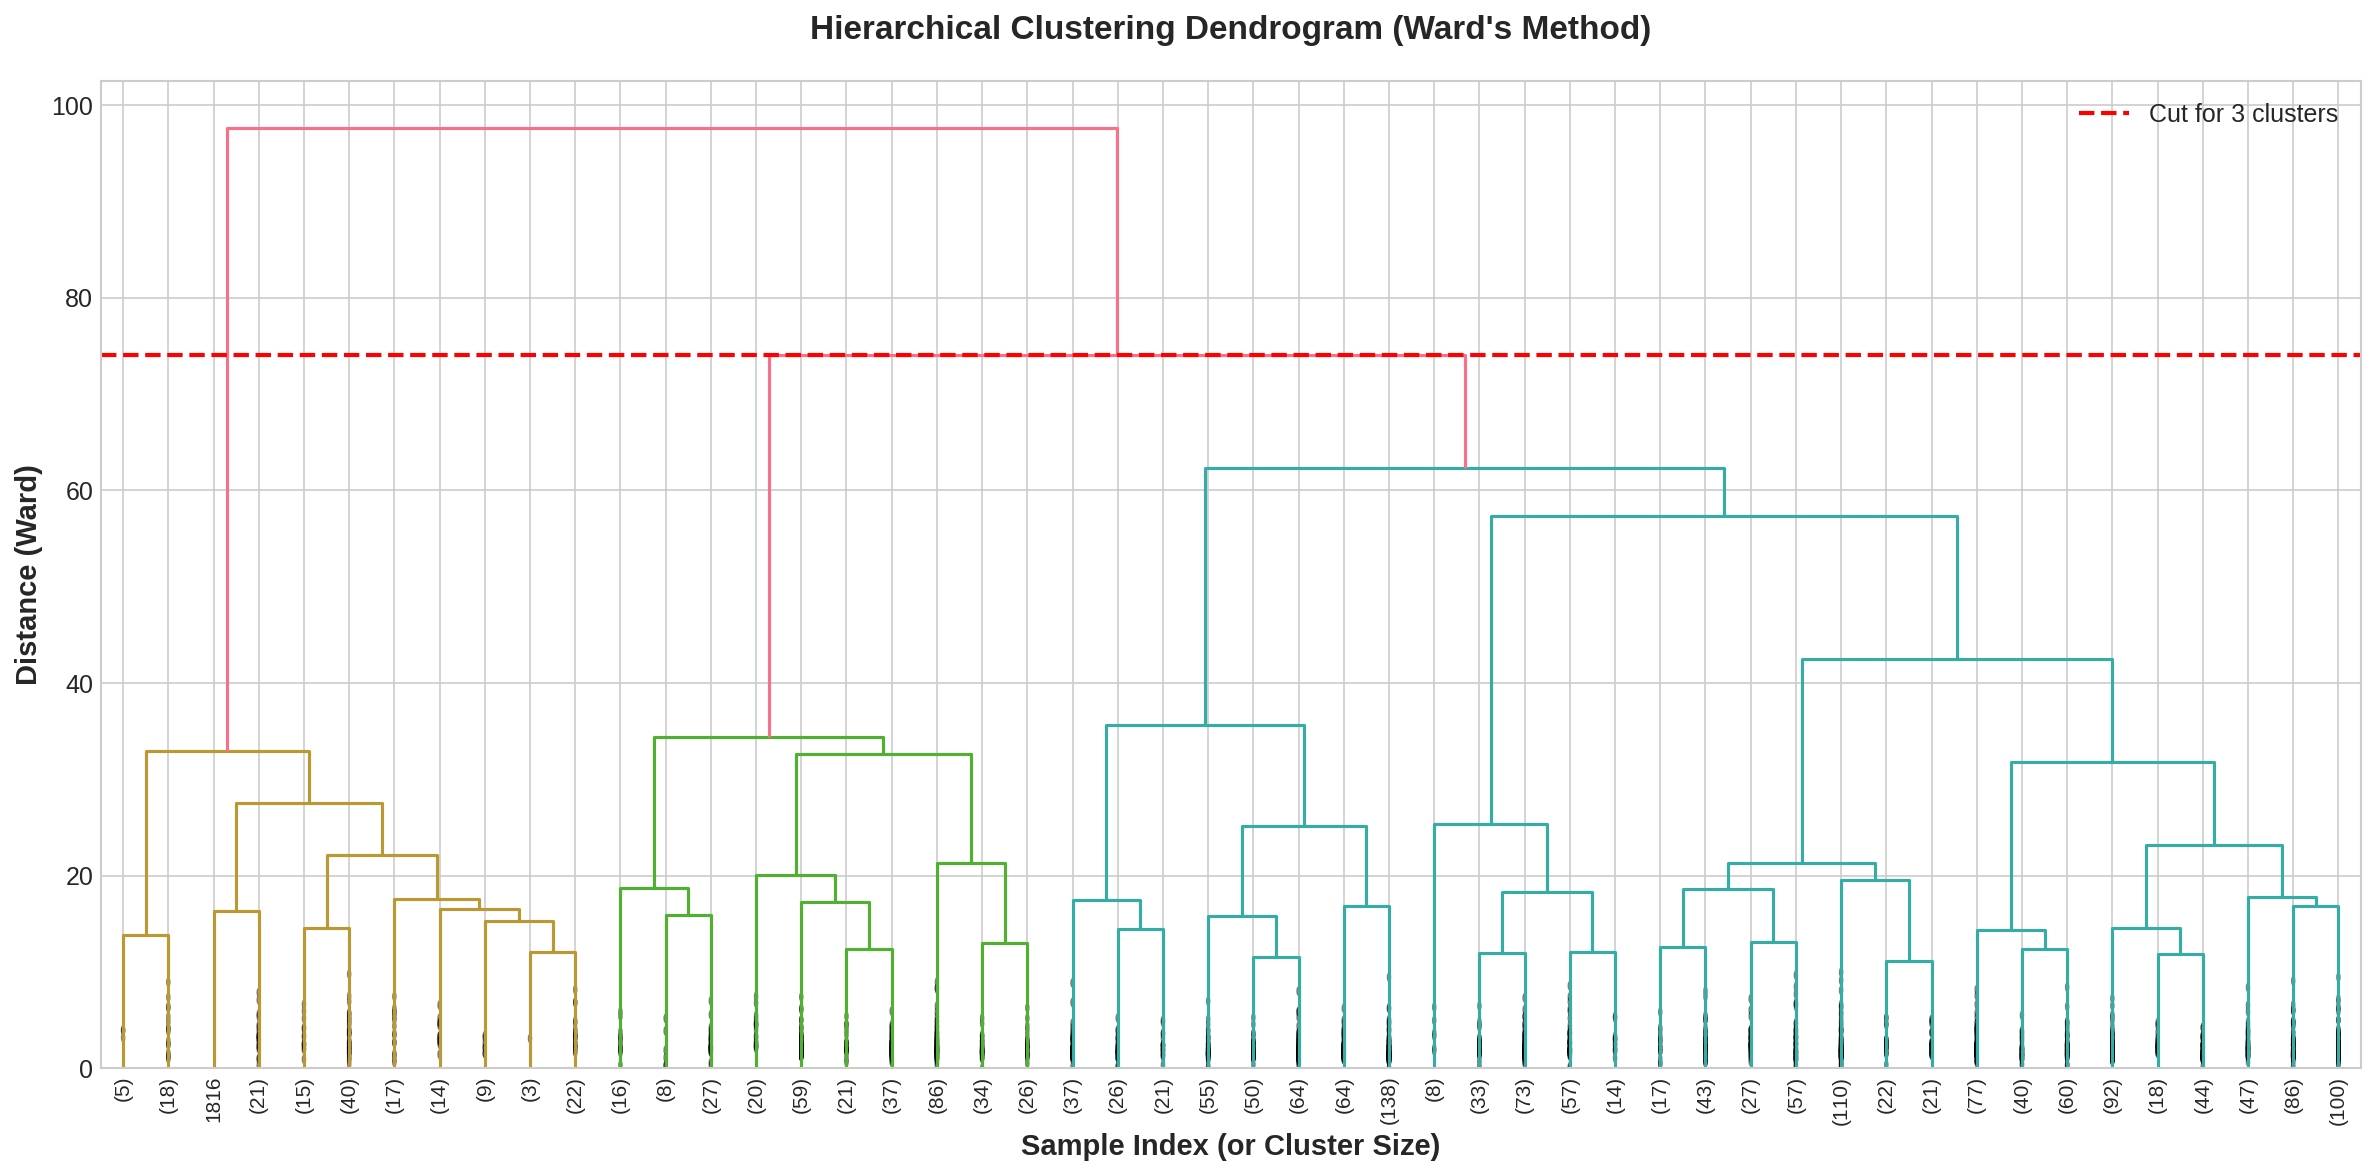


Applying Agglomerative Clustering with k=3...
Adjusted Rand Index (K-Means vs Hierarchical): 0.2632
Cluster Validation

Silhouette Analysis by Cluster:
  Cluster 0: Mean Silhouette = 0.0814, Std = 0.0989
  Cluster 1: Mean Silhouette = 0.0783, Std = 0.1303
  Cluster 2: Mean Silhouette = 0.2337, Std = 0.0779

Overall Silhouette Score: 0.1773
Summary Statistics by Cluster (Key Variables)

Key Variable Statistics by Cluster:
        squareMeters                      rooms                       price                             centreDistance                    buildYear                       
                mean    std    min    max  mean   std  min  max        mean        std     min      max           mean   std   min    max      mean    std     min     max
Cluster                                                                                                                                                                   
0              85.01  19.74  39.72  150.0  3.67  0.82  2.0  6

In [17]:
# Set style for figures
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# CLUSTERING ANALYSIS
print("CLUSTERING ANALYSIS")

# Variable Selection for Clustering

# Select continuous variables that are meaningful for market segmentation
# Include all relevant features: physical characteristics, location, and pricing
clustering_vars = ['squareMeters', 'rooms', 'floor', 'floorCount', 'buildYear',
                   'centreDistance', 'poiCount', 'schoolDistance', 'clinicDistance',
                   'postOfficeDistance', 'kindergartenDistance', 'restaurantDistance',
                   'collegeDistance', 'pharmacyDistance', 'price']

print(f"\nVariables selected for clustering ({len(clustering_vars)}):")
for i, var in enumerate(clustering_vars, 1):
    print(f"  {i}. {var}")

# Prepare data for clustering (remove rows with any missing values in selected vars)
df_cluster = df_clean[clustering_vars].dropna()
print(f"\nSample size after removing missing values: {len(df_cluster)}")

# Remove rural/remote outliers that dominate clustering structure
# These apartments have extreme distance values (>99th percentile on multiple distance vars)
distance_vars_filter = ['schoolDistance', 'kindergartenDistance', 'pharmacyDistance']

# Flag apartments that are outliers on ALL three key distance variables
outlier_mask = pd.Series([False] * len(df_cluster), index=df_cluster.index)
for var in distance_vars_filter:
    Q99 = df_cluster[var].quantile(0.99)
    outlier_mask = outlier_mask | (df_cluster[var] > Q99)
    print(f"  {var}: 99th percentile = {Q99:.2f}")

n_outliers = outlier_mask.sum()
df_cluster = df_cluster[~outlier_mask]
print(f"\nRemoved {n_outliers} rural/remote outliers ({n_outliers/21501*100:.1f}%)")
print(f"Final sample size for clustering: {len(df_cluster)}")

# Data Standardization

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

print("Variables have been standardized (mean=0, std=1)")
print(f"\nStandardized data shape: {X_scaled.shape}")

# DETERMINING OPTIMAL NUMBER OF CLUSTERS
print("Determining Optimal Number of Clusters")

# Range of clusters to evaluate
k_range = range(2, 11)

# Calculate metrics for different k values
inertias = []
silhouette_scores = []
distortions = []

print("\nEvaluating cluster numbers from 2 to 10...")
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    kmeans.fit(X_scaled)

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))
    distortions.append(sum(np.min(cdist(X_scaled, kmeans.cluster_centers_, 'euclidean'), axis=1)) / X_scaled.shape[0])

    print(f"  k={k}: Inertia={kmeans.inertia_:.2f}, Silhouette={silhouette_scores[-1]:.4f}")

# Find optimal k based on silhouette score
optimal_k_silhouette = k_range[np.argmax(silhouette_scores)]
print(f"\n*** Optimal k based on Silhouette Score: {optimal_k_silhouette} ***")

# After removing rural outliers, cluster the urban/suburban population
# into meaningful market segments
selected_k = 3  # Start with 3 clusters for urban/suburban segmentation
print(f"*** Selected k for analysis: {selected_k} (for interpretable market segmentation) ***")
optimal_k_silhouette = selected_k

# VISUALIZATION 1: Elbow Method and Silhouette Score Plot (Combined)
print("Visualization 1: Elbow Method & Silhouette Score")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Plot
ax1 = axes[0]
ax1.plot(list(k_range), inertias, 'b-o', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Clusters (k)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Within-Cluster Sum of Squares (Inertia)', fontsize=14, fontweight='bold')
ax1.set_title('Elbow Method for Optimal k', fontsize=16, fontweight='bold', pad=15)
ax1.set_xticks(list(k_range))
ax1.grid(True, alpha=0.3)

# Silhouette Score Plot
ax2 = axes[1]
ax2.plot(list(k_range), silhouette_scores, 'g-o', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Clusters (k)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Silhouette Score', fontsize=14, fontweight='bold')
ax2.set_title('Silhouette Score for Optimal k', fontsize=16, fontweight='bold', pad=15)
ax2.set_xticks(list(k_range))
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# K-MEANS CLUSTERING WITH OPTIMAL K
print(f"K-Means Clustering with k={optimal_k_silhouette}")

# Fit K-Means with optimal k
kmeans_final = KMeans(n_clusters=optimal_k_silhouette, random_state=42, n_init=10, max_iter=300)
cluster_labels = kmeans_final.fit_predict(X_scaled)

# Add cluster labels to the dataframe
df_cluster_result = df_cluster.copy()
df_cluster_result['Cluster'] = cluster_labels

# Cluster distribution
print("\nCluster Distribution:")
cluster_counts = df_cluster_result['Cluster'].value_counts().sort_index()
for cluster, count in cluster_counts.items():
    pct = count / len(df_cluster_result) * 100
    print(f"  Cluster {cluster}: {count} apartments ({pct:.1f}%)")

# CLUSTER PROFILING
print("Cluster Profiling - Characteristics of Each Segment")

# Calculate cluster means
cluster_profiles = df_cluster_result.groupby('Cluster')[clustering_vars].mean()

print("\nCluster Means (Original Scale):")
print(cluster_profiles.round(2).to_string())

# Calculate standardized cluster means for interpretation
cluster_profiles_scaled = pd.DataFrame(
    scaler.transform(cluster_profiles),
    columns=clustering_vars,
    index=cluster_profiles.index
)

print("\n\nCluster Means (Standardized - for interpretation):")
print(cluster_profiles_scaled.round(3).to_string())

# Interpretation of clusters
print("Cluster Interpretations:")

for cluster in range(optimal_k_silhouette):
    print(f"\n--- Cluster {cluster} ---")
    profile = cluster_profiles_scaled.loc[cluster]

    # Find distinguishing features (high or low values)
    high_features = profile[profile > 0.5].sort_values(ascending=False)
    low_features = profile[profile < -0.5].sort_values()

    print("  High characteristics (z > 0.5):")
    for feat, val in high_features.items():
        print(f"    • {feat}: {val:.2f}")

    print("  Low characteristics (z < -0.5):")
    for feat, val in low_features.items():
        print(f"    • {feat}: {val:.2f}")

# VISUALIZATION 2: Cluster Profile Heatmap
print("Visualization 2: Cluster Profile Heatmap")

fig, ax = plt.subplots(figsize=(14, 8))

# Create a clipped version for color scaling (clip to [-2, 2] for better visualization)
# but keep original values for annotations
cluster_profiles_clipped = cluster_profiles_scaled.clip(lower=-2, upper=2)

# Create heatmap with clipped colors but original annotations
sns.heatmap(cluster_profiles_clipped.T,
            annot=cluster_profiles_scaled.T.values,  # Show actual z-scores
            fmt='.2f',
            cmap='RdBu_r',  # Red-Blue diverging colormap (red=high, blue=low)
            center=0,
            vmin=-2,
            vmax=2,
            linewidths=0.5,
            cbar_kws={'label': 'Standardized Mean (z-score)', 'shrink': 0.8},
            ax=ax,
            annot_kws={'size': 10, 'fontweight': 'bold'})

ax.set_xlabel('Cluster', fontsize=14, fontweight='bold')
ax.set_ylabel('Variables', fontsize=14, fontweight='bold')
ax.set_title('Cluster Profiles: Standardized Variable Means by Cluster',
             fontsize=15, fontweight='bold', pad=20)
ax.set_xticklabels([f'Cluster {i}' for i in range(optimal_k_silhouette)], fontsize=12)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=11, rotation=0)

plt.tight_layout()
plt.show()

# HIERARCHICAL CLUSTERING
print("Hierarchical Clustering Analysis")

# Use a random sample for hierarchical clustering dendrogram (computational efficiency)
np.random.seed(42)
sample_size = min(2000, len(X_scaled))
sample_idx = np.random.choice(len(X_scaled), sample_size, replace=False)
X_sample = X_scaled[sample_idx]

print(f"\nUsing {sample_size} samples for hierarchical clustering visualization")

# Compute linkage matrix using Ward's method
print("Computing linkage matrix (Ward's method)...")
linkage_matrix = linkage(X_sample, method='ward')

# VISUALIZATION 3: Dendrogram with Cluster Cutoff
fig, ax = plt.subplots(figsize=(16, 8))

# Plot dendrogram
dendrogram(
    linkage_matrix,
    truncate_mode='lastp',
    p=50,  # Show last 50 merged clusters
    leaf_rotation=90,
    leaf_font_size=10,
    show_contracted=True,
    ax=ax
)

# Add horizontal line for optimal cut
# Calculate the height for optimal_k_silhouette clusters
max_d = linkage_matrix[-(optimal_k_silhouette-1), 2]
ax.axhline(y=max_d, color='red', linestyle='--', linewidth=2,
           label=f'Cut for {optimal_k_silhouette} clusters')

ax.set_xlabel('Sample Index (or Cluster Size)', fontsize=14, fontweight='bold')
ax.set_ylabel('Distance (Ward)', fontsize=14, fontweight='bold')
ax.set_title('Hierarchical Clustering Dendrogram (Ward\'s Method)',
             fontsize=16, fontweight='bold', pad=20)
ax.legend(fontsize=12, loc='upper right')

plt.tight_layout()
plt.show()

# Hierarchical clustering with same number of clusters
print(f"\nApplying Agglomerative Clustering with k={optimal_k_silhouette}...")
agg_clustering = AgglomerativeClustering(n_clusters=optimal_k_silhouette, linkage='ward')
hierarchical_labels = agg_clustering.fit_predict(X_scaled)

# Compare with K-Means
from sklearn.metrics import adjusted_rand_score
ari = adjusted_rand_score(cluster_labels, hierarchical_labels)
print(f"Adjusted Rand Index (K-Means vs Hierarchical): {ari:.4f}")

# CLUSTER VALIDATION
print("Cluster Validation")

# Silhouette analysis for each cluster
silhouette_vals = silhouette_samples(X_scaled, cluster_labels)
df_cluster_result['Silhouette'] = silhouette_vals

print("\nSilhouette Analysis by Cluster:")
for cluster in range(optimal_k_silhouette):
    cluster_silhouette = silhouette_vals[cluster_labels == cluster]
    print(f"  Cluster {cluster}: Mean Silhouette = {np.mean(cluster_silhouette):.4f}, "
          f"Std = {np.std(cluster_silhouette):.4f}")

print(f"\nOverall Silhouette Score: {silhouette_score(X_scaled, cluster_labels):.4f}")

# SUMMARY STATISTICS BY CLUSTER
print("Summary Statistics by Cluster (Key Variables)")

key_vars = ['squareMeters', 'rooms', 'price', 'centreDistance', 'buildYear']

summary_stats = df_cluster_result.groupby('Cluster')[key_vars].agg(['mean', 'std', 'min', 'max'])
print("\nKey Variable Statistics by Cluster:")
print(summary_stats.round(2).to_string())

# Price per square meter by cluster
df_cluster_result['price_per_sqm'] = df_cluster_result['price'] / df_cluster_result['squareMeters']
print("\n\nPrice per Square Meter by Cluster:")
price_sqm_stats = df_cluster_result.groupby('Cluster')['price_per_sqm'].agg(['mean', 'std', 'median'])
print(price_sqm_stats.round(2).to_string())

for cluster in range(optimal_k_silhouette):
    count = cluster_counts[cluster]
    pct = count / len(df_cluster_result) * 100
    avg_price = cluster_profiles.loc[cluster, 'price']
    avg_sqm = cluster_profiles.loc[cluster, 'squareMeters']
    avg_rooms = cluster_profiles.loc[cluster, 'rooms']
    avg_year = cluster_profiles.loc[cluster, 'buildYear']
    print(f"  Cluster {cluster} ({pct:.1f}% of data):")
    print(f"    - Avg Price: {avg_price:,.0f} PLN, Avg Size: {avg_sqm:.1f} m², Avg Rooms: {avg_rooms:.1f}, Avg Building Year: {avg_year:,.0f}")